# Guardrails cap020 paper artifacts v5: final paper narrative order

This notebook reorganizes the completed Guardrails cap020 artifacts into a systems-paper order. It reads only completed result files and existing v4 artifact tables, generates paper-order figures, captions, narrative notes, validation reports, and appendix ablations where source files are available. It does not rerun simulations or modify simulation code.

In [1]:
from pathlib import Path
import os

os.environ.setdefault("MPLCONFIGDIR", str((Path(".mplconfig")).resolve()))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import json
import hashlib
import shutil
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

METHOD_COLORS = {
    "IL-guard": "#0072B2",
    "IL-no-guard": "#111111",
    "Delayed-GBDT": "#56B4E9",
    "Windowed-2Hit-LRU": "#F0E442",
    "Delayed-TinyLFU": "#7F7F7F",
}

DATASET_COLORS = {
    "Wikipedia-2007 web": "#D55E00",
    "Wiki-CDN-2018": "#009E73",
}

REPLAY_COLORS = {
    "Exact schedule replay": "#CC79A7",
    "Permuted schedule replay": "#E69F00",
    "IL-guard": METHOD_COLORS["IL-guard"],
}

COMPONENT_COLORS = {
    "Feature": "#264653",
    "Scoring": "#F4A261",
    "Guard/control": "#E76F51",
    "Selection": "#8E44AD",
    "Update": "#6C757D",
}

ERRORBAR_COLOR = "#333333"
ZERO_LINE_COLOR = "#555555"
GRID_COLOR = "#DDDDDD"

FIGURE_COLOR_USAGE = {}


def validate_unique_color_registry():
    seen = {}
    for registry_name, registry in [
        ("METHOD_COLORS", METHOD_COLORS),
        ("DATASET_COLORS", DATASET_COLORS),
        ("REPLAY_COLORS", REPLAY_COLORS),
        ("COMPONENT_COLORS", COMPONENT_COLORS),
    ]:
        for label, color in registry.items():
            key = str(color).upper()
            if key in seen and seen[key][1] != label:
                previous_registry, previous_label = seen[key]
                if not ({previous_label, label} == {"IL-guard"}):
                    raise AssertionError(
                        f"Color {color} assigned to both {previous_registry}:{previous_label} and {registry_name}:{label}"
                    )
            seen[key] = (registry_name, label)
    return True


def registered_color_for_label(label):
    for registry in [METHOD_COLORS, DATASET_COLORS, REPLAY_COLORS, COMPONENT_COLORS]:
        if label in registry:
            return registry[label]
    raise KeyError(f"No registered color for semantic label: {label}")


def record_figure_color_usage(fig_name, semantic_type, labels):
    entries = []
    for label in labels:
        entries.append({"semantic_type": semantic_type, "label": label, "color": registered_color_for_label(label)})
    FIGURE_COLOR_USAGE[fig_name] = entries


def validate_figure_color_usage(fig_name, expected_labels):
    entries = FIGURE_COLOR_USAGE.get(fig_name, [])
    used_labels = {entry["label"] for entry in entries}
    expected_labels = set(expected_labels)
    unexpected = sorted(used_labels - expected_labels)
    missing = sorted(expected_labels - used_labels)
    bad_colors = []
    for entry in entries:
        expected_color = registered_color_for_label(entry["label"]).upper()
        if str(entry["color"]).upper() != expected_color:
            bad_colors.append(f"{entry['label']}={entry['color']} expected {expected_color}")
    if unexpected or missing or bad_colors:
        raise AssertionError(
            f"{fig_name} color usage invalid; unexpected={unexpected}; missing={missing}; bad_colors={bad_colors}"
        )
    return True


validate_unique_color_registry()

mpl.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.grid": True,
    "grid.color": GRID_COLOR,
    "grid.linewidth": 0.45,
    "grid.alpha": 0.65,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

SINGLE_COL_WIDTH = 3.5
DOUBLE_COL_WIDTH = 7.16

METHOD_STYLE = {
    "Cap-only": {"color": "#4D4D4D", "marker": "^", "linestyle": ":", "linewidth": 2.0, "markersize": 6.0, "zorder": 3},
    "Precision-only": {"color": "#A6761D", "marker": "s", "linestyle": "--", "linewidth": 2.0, "markersize": 6.0, "zorder": 4},
    "Quality-only": {"color": "#6A3D9A", "marker": "D", "linestyle": "-.", "linewidth": 2.0, "markersize": 5.8, "markerfacecolor": "none", "markeredgewidth": 1.2, "zorder": 3},
    "IL-guard": {"color": METHOD_COLORS["IL-guard"], "marker": "o", "linestyle": "-", "linewidth": 2.0, "markersize": 6.2, "zorder": 5},
    "Exact schedule replay": {"color": REPLAY_COLORS["Exact schedule replay"], "marker": "D", "linestyle": "-.", "linewidth": 2.0, "markersize": 5.8, "markerfacecolor": "none", "markeredgewidth": 1.4, "zorder": 6},
    "Permuted schedule replay": {"color": REPLAY_COLORS["Permuted schedule replay"], "marker": "X", "linestyle": "--", "linewidth": 2.0, "markersize": 6.2, "zorder": 2},
    "IL-no-guard": {"color": METHOD_COLORS["IL-no-guard"], "marker": "s", "linestyle": "--", "linewidth": 2.0, "markersize": 5.8, "zorder": 3},
    "Delayed-GBDT": {"color": METHOD_COLORS["Delayed-GBDT"], "marker": "v", "linestyle": "-.", "linewidth": 2.0, "markersize": 5.8, "zorder": 3},
    "Windowed-2Hit-LRU": {"color": METHOD_COLORS["Windowed-2Hit-LRU"], "marker": "p", "linestyle": ":", "linewidth": 2.0, "markersize": 6.2, "markeredgecolor": "#000000", "markeredgewidth": 0.6, "zorder": 3},
    "Delayed-TinyLFU": {"color": METHOD_COLORS["Delayed-TinyLFU"], "marker": "*", "linestyle": "-", "linewidth": 2.0, "markersize": 7.0, "zorder": 2},
}

DATASET_STYLE = {
    "wiki2018": {"color": DATASET_COLORS["Wiki-CDN-2018"], "marker": "o", "linestyle": "-", "linewidth": 2.0, "markersize": 6.0},
    "wikipedia_september_2007": {"color": DATASET_COLORS["Wikipedia-2007 web"], "marker": "s", "linestyle": "--", "linewidth": 2.0, "markersize": 6.0},
}

VARIANT_LABELS = {
    "cap_only_cap020": "Cap-only",
    "precision_only_cap020": "Precision-only",
    "full_cap020": "IL-guard",
    "quality_only_cap020": "Quality-only",
    "precision_only_budget_replay_cap020": "Exact schedule replay",
    "precision_only_budget_replay_permuted_cap020": "Permuted schedule replay",
    "precision_only_budget_matched_uniform_cap020": "Uniform matched",
    "precision_only_budget_matched_random_cap020": "Random matched",
    "no_guard_legacy": "IL-no-guard",
    "delayed_gdbt_A2": "Delayed-GBDT",
    "delayed_gdbt": "Delayed-GBDT",
    "baseline_tinylfu_delayed": "Delayed-TinyLFU",
    "windowed_2hit_lru_w1slot": "Windowed-2Hit-LRU",
}

DATASETS = ["wikipedia_september_2007", "wiki2018"]
DATASET_LABELS = {"wikipedia_september_2007": "Wikipedia-2007 web", "wiki2018": "Wiki-CDN-2018"}
CACHE_ORDER = [0.8, 1.0, 2.0, 3.0, 4.0, 5.0]
CACHE_PCTS = CACHE_ORDER
CACHE_X_POS = np.arange(len(CACHE_PCTS))
CACHE_X_LABELS = ["0.8", "1.0", "2.0", "3.0", "4.0", "5.0"]
CACHE_X_MAP = {float(v): i for i, v in enumerate(CACHE_PCTS)}
CAP_LABEL_ORDER = ["0.005", "0.010", "0.015", "0.020", "0.025", "0.050", "0.075", "no-cap"]
CAP_DISPLAY_LABELS = {"0.005": "0.005", "0.010": "0.010", "0.015": "0.015", "0.020": "0.020", "0.025": "0.025", "0.050": "0.050", "0.075": "0.075", "no-cap": "no cap"}


def append_latex_note(tex_path, note):
    tex_path = Path(tex_path)
    text = tex_path.read_text(encoding="utf-8").rstrip()
    safe_note = note.replace("%", r"\%")
    tex_path.write_text(text + "\n\\vspace{0.4ex}\n\\noindent\\scriptsize{" + safe_note + "}\n", encoding="utf-8")


def public_artifact_paths(stem, directory, exts):
    return [directory / f"{stem}.{ext}" for ext in exts]


In [2]:
PROJECT_ROOT = Path.cwd().resolve()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / "results/guardrails_signal_v2_cap020_budget_controls").exists():
        PROJECT_ROOT = candidate
        os.chdir(PROJECT_ROOT)
        break
else:
    raise FileNotFoundError("Could not locate project root containing results/guardrails_signal_v2_cap020_budget_controls")

INPUT_ROOT = Path("results/guardrails_signal_v2_cap020_budget_controls")
CAP_SEARCH_ROOTS = [
    Path("results/guardrails_signal_v2"),
    Path("results/guardrails_signal_v2_cap020"),
    Path("results/guardrails_signal_v2_cap020_validation"),
    Path("results/guardrails_signal_v2_cap020_budget_controls"),
    Path("results"),
]
V4_ROOT = Path("results/guardrails_signal_v2_cap020_paper_artifacts_v4")
V4_TABLE_DIR = V4_ROOT / "tables"
OUTPUT_ROOT = Path("results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order")
FIG_DIR = OUTPUT_ROOT / "figures"
TABLE_DIR = OUTPUT_ROOT / "tables"
CAPTION_DIR = OUTPUT_ROOT / "captions"
VALIDATION_DIR = OUTPUT_ROOT / "validation"
NARRATIVE_DIR = OUTPUT_ROOT / "narrative"
for directory in [FIG_DIR, TABLE_DIR, CAPTION_DIR, VALIDATION_DIR, NARRATIVE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

generated_figures = []
generated_tables = []
caption_records = []
manifest_entries = []
file_provenance_rows = []
validation_rows = []
validation_warnings = []
input_hashes = {}
cap_sensitivity_source_paths = []
baseline_source_paths = []
baseline_missing_messages = []
cap_sensitivity_available = False
cap_sensitivity_warning = None
quality_only_cap020_available = False
quality_only_cap020_source_paths = []
quality_only_missing_messages = []

# Remove stale paper-facing outputs whose names moved to the final claim-driven order.
STALE_FIGURE_STEMS = [
    "Fig6_paired_bootstrap_support_paper",
    "Fig7_cap_sensitivity_selection_paper",
    "FigS1_selective_suppression_diagnostics_paper",
    "FigS2_quality_only_cap020_ablation",
    "Fig4_admission_diagnostics_across_baselines_paper_singlecol",
]
STALE_TABLE_STEMS = [
    "Table_III_system_level_average_hr_paper",
    "Table_IV_admission_diagnostics_across_baselines_paper",
    "Table_V_score_quality_budget_control_paper",
    "Table_VI_cap_selection_summary_paper",
]
for stem in STALE_FIGURE_STEMS:
    for ext in ["png", "pdf", "svg"]:
        path = FIG_DIR / f"{stem}.{ext}"
        if path.exists():
            path.unlink()
for stem in STALE_TABLE_STEMS:
    for ext in ["csv", "tex"]:
        path = TABLE_DIR / f"{stem}.{ext}"
        if path.exists():
            path.unlink()


def sha256_file(path):
    path = Path(path)
    h = hashlib.sha256()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()


def require_file(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Required file not found: {path}")
    return path


def require_columns(df, columns, file_name):
    missing = [c for c in columns if c not in df.columns]
    if missing:
        raise ValueError(f"{file_name} missing required columns: {missing}")
    return True


def register_source_file(path, file_kind="input"):
    path = Path(path)
    if not path.exists():
        return None
    digest = sha256_file(path)
    input_hashes[str(path)] = digest
    if not any(row["Path"] == str(path) for row in file_provenance_rows):
        file_provenance_rows.append({
            "File": path.name,
            "Path": str(path),
            "Rows": file_kind,
            "Columns": file_kind,
            "SHA256": digest,
        })
    return digest


def add_validation(check, status, details):
    validation_rows.append({"Check": check, "Status": status, "Details": details})
    if status not in {"OK", "OK_WITH_EXPECTED_NA", "SKIPPED"}:
        validation_warnings.append(f"{check}: {status} - {details}")


def label_variant(variant):
    return VARIANT_LABELS.get(variant, variant)


def method_style(label):
    return METHOD_STYLE.get(label, {"color": "0.25", "marker": "o", "linestyle": "-", "linewidth": 1.8, "markersize": 5.0})


def sort_by_cache(df):
    return df.assign(_cache_order=pd.Categorical(df["capacity_percent"], categories=CACHE_ORDER, ordered=True)).sort_values("_cache_order").drop(columns="_cache_order")


def add_panel_label(ax, label):
    ax.text(
        0.5, 1.08, label,
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="normal",
    )


def add_figure_legend_below(fig, axes, ncol=3, y=0.0, bottom=0.18):
    flat_axes = np.ravel(axes)
    handles, labels = [], []
    for ax in flat_axes:
        h, l = ax.get_legend_handles_labels()
        for handle, label in zip(h, l):
            if label and label not in labels:
                handles.append(handle)
                labels.append(label)
    if handles:
        fig.legend(
            handles, labels,
            loc="lower center",
            bbox_to_anchor=(0.5, y),
            ncol=ncol,
            frameon=False,
            fontsize=8.0,
            handlelength=1.6,
            columnspacing=1.0,
            handletextpad=0.5,
        )
        fig.subplots_adjust(bottom=bottom)
    return handles, labels


def add_global_legend(fig, axes, ncol=3, y=0.0):
    bottom = 0.20 if ncol <= 2 else 0.18
    return add_figure_legend_below(fig, axes, ncol=ncol, y=y, bottom=bottom)

def cache_x_positions(cache_values):
    return np.array([CACHE_X_MAP[round(float(v), 1)] for v in cache_values], dtype=float)


def setup_categorical_cache_axis(ax):
    ax.set_xticks(CACHE_X_POS)
    ax.set_xticklabels(CACHE_X_LABELS)
    ax.set_xlim(-0.25, len(CACHE_PCTS) - 0.75)
    ax.set_xlabel("Cache size (% of distinct objects)")


def apply_cache_axis(ax):
    setup_categorical_cache_axis(ax)


def set_padded_ylim(ax, values, pad_frac=0.05):
    values = pd.Series(values).replace([np.inf, -np.inf], np.nan).dropna()
    if values.empty:
        return
    lo, hi = float(values.min()), float(values.max())
    if np.isclose(lo, hi):
        pad = max(abs(lo) * pad_frac, 1e-4)
    else:
        pad = (hi - lo) * pad_frac
    ax.set_ylim(lo - pad, hi + pad)



def validate_text_layout_before_save(fig, name):
    try:
        fig.canvas.draw()
        renderer = fig.canvas.get_renderer()
        canvas = fig.bbox
        outside = []
        for artist in fig.findobj(mpl.text.Text):
            if not artist.get_visible() or not artist.get_text():
                continue
            bbox = artist.get_window_extent(renderer=renderer)
            if bbox.width == 0 or bbox.height == 0:
                continue
            tol = 40
            if bbox.x1 < -tol or bbox.y1 < -tol or bbox.x0 > canvas.x1 + tol or bbox.y0 > canvas.y1 + tol:
                outside.append(artist.get_text()[:40])
        outside = [text for text in outside if not text.startswith("$\\mathdefault{")]
        if outside:
            add_validation(f"Text layout before save: {name}", "WARN", "; ".join(outside[:5]))
    except Exception as exc:
        add_validation(f"Text layout before save: {name}", "WARN", str(exc))


def save_figure(fig, name):
    validate_text_layout_before_save(fig, name)
    paths = {}
    for ext in ["png", "pdf", "svg"]:
        path = FIG_DIR / f"{name}.{ext}"
        if ext == "png":
            fig.savefig(path, dpi=600, bbox_inches="tight", pad_inches=0.04)
        else:
            fig.savefig(path, bbox_inches="tight", pad_inches=0.04)
        paths[ext] = path
    generated_figures.append({"name": name, "paths": {k: str(v) for k, v in paths.items()}})
    return paths


def save_figure_alias(paths, alias_name):
    alias_paths = {}
    for ext, src in paths.items():
        dst = FIG_DIR / f"{alias_name}.{ext}"
        shutil.copy2(src, dst)
        alias_paths[ext] = dst
    return alias_paths


def display_figure(path_or_fig):
    if isinstance(path_or_fig, (str, Path)):
        display(Image(filename=str(path_or_fig)))
    else:
        display(path_or_fig)


def format_table_for_display(df, numeric_format_map=None):
    numeric_format_map = numeric_format_map or {}
    styler = df.style.format(numeric_format_map, na_rep="n/a")
    try:
        styler = styler.hide(axis="index")
    except AttributeError:
        styler = styler.hide_index()
    return styler


TABLE_EXPORT_FORMATS = {
    "Avg HR": "{:.6f}",
    "ΔHR vs Cap-only": "{:.6f}",
    "ΔHR vs IL-guard": "{:.6f}",
    "Best HR": "{:.6f}",
    "Worst HR": "{:.6f}",
    "Cap020 HR": "{:.6f}",
    "ΔHR vs best": "{:.6f}",
    "Admissions/1000": "{:.3f}",
    "Pollution proxy": "{:.3f}",
    "ΔAdmissions/1000 vs Cap-only": "{:.3f}",
    "ΔHit-yield/admission vs Cap-only": "{:.3f}",
    "ΔPollution vs Cap-only": "{:.3f}",
    "ΔHR vs IL-guard": "{:.6f}",
    "Admissions/1000 at best cap": "{:.3f}",
    "Admissions/1000 at cap020": "{:.3f}",
    "Admission change at cap020": "{:.3f}",
    "Avg selected admissions": "{:.1f}",
    "Match ratio vs IL-guard": "{:.3f}",
    "Hit-yield/admission": "{:.3f}",
    "Hit-yield at cap020": "{:.3f}",
    "Pollution": "{:.3f}",
    "Pollution at cap020": "{:.3f}",
    "Admission precision": "{:.3f}",
    "Quality action rate": "{:.3f}",
    "Suppression rate": "{:.3f}",
    "Admitted/suppressed next-slot request ratio": "{:.3f}",
    "Quality masked by cap": "{:.3f}",
    "Cap binding": "{:.3f}",
    "Mean quality multiplier": "{:.3f}",
    "Mean corr(precision_eff, next-slot hit-yield)": "{:.3f}",
    "Mean corr(precision_eff, next-slot admission precision)": "{:.3f}",
    "Mean corr(precision_eff, pollution proxy)": "{:.3f}",
}


def format_table_for_export(df):
    out = df.copy()
    for col, fmt in TABLE_EXPORT_FORMATS.items():
        if col not in out.columns:
            continue
        out[col] = out[col].map(lambda x, fmt=fmt: "n/a" if pd.isna(x) else fmt.format(float(x)))
    return out


def save_table(df, name):
    csv_path = TABLE_DIR / f"{name}.csv"
    tex_path = TABLE_DIR / f"{name}.tex"
    export_df = format_table_for_export(df)
    export_df.to_csv(csv_path, index=False)
    latex = export_df.to_latex(index=False, escape=True, na_rep="n/a")
    tex_path.write_text(latex, encoding="utf-8")
    generated_tables.append({"name": name, "paths": {"csv": str(csv_path), "tex": str(tex_path)}})
    return {"csv": csv_path, "tex": tex_path}




PAPER_LABEL_REPLACEMENTS = {
    "wiki2018": "Wiki-CDN-2018",
    "wikipedia_september_2007": "Wikipedia-2007 web",
    "Wiki2018": "Wiki-CDN-2018",
    "Wikipedia 2007": "Wikipedia-2007 web",
    "Wikipedia-2007 Web": "Wikipedia-2007 web",
    "IL-Guard": "IL-guard",
    "IL-Guard-full": "IL-guard",
    "Unguarded IL": "IL-no-guard",
    "IL-no-guard": "IL-no-guard",
    "Exact replay": "Exact schedule replay",
    "Permuted replay": "Permuted schedule replay",
}


def normalize_paper_labels_in_df(df):
    out = df.copy()
    for col in out.columns:
        if out[col].dtype == object:
            out[col] = out[col].map(lambda v: PAPER_LABEL_REPLACEMENTS.get(v, v) if isinstance(v, str) else v)
    return out

def save_existing_table(old_name, new_name):
    csv_src = V4_TABLE_DIR / f"{old_name}.csv"
    tex_src = V4_TABLE_DIR / f"{old_name}.tex"
    csv_dst = TABLE_DIR / f"{new_name}.csv"
    tex_dst = TABLE_DIR / f"{new_name}.tex"
    if csv_src.exists() and tex_src.exists():
        register_source_file(csv_src, file_kind="v4_table_csv")
        register_source_file(tex_src, file_kind="v4_table_tex")
        shutil.copy2(csv_src, csv_dst)
        shutil.copy2(tex_src, tex_dst)
        source_csv, source_tex = csv_src, tex_src
    elif csv_dst.exists() and tex_dst.exists():
        source_csv, source_tex = csv_dst, tex_dst
        register_source_file(source_csv, file_kind="existing_v5_table_csv")
        register_source_file(source_tex, file_kind="existing_v5_table_tex")
        add_validation(f"Fallback table source: {new_name}", "WARN", f"Missing v4 sources for {old_name}; reused existing v5 table files.")
    else:
        raise FileNotFoundError(f"Required table source not found: {csv_src} / {tex_src}")
    try:
        normalized_df = normalize_paper_labels_in_df(pd.read_csv(csv_dst))
        normalized_df.to_csv(csv_dst, index=False)
        format_table_for_export(normalized_df).to_latex(tex_dst, index=False, escape=True, na_rep="n/a")
    except Exception as exc:
        add_validation(f"Paper-label normalization: {new_name}", "WARN", str(exc))
    generated_tables.append({"name": new_name, "paths": {"csv": str(csv_dst), "tex": str(tex_dst)}})
    return {"csv": csv_dst, "tex": tex_dst, "source_csv": source_csv, "source_tex": source_tex}


def display_existing_table(path):
    df = pd.read_csv(path)
    display(format_table_for_display(df))
    return df


def markdown_table(rows, columns):
    def esc(value):
        text = str(value).replace("|", "\|")
        return text
    lines = ["| " + " | ".join(columns) + " |", "| " + " | ".join(["---"] * len(columns)) + " |"]
    for row in rows:
        lines.append("| " + " | ".join(esc(row.get(col, "")) for col in columns) + " |")
    return "\n".join(lines)

def display_caption(text):
    display(Markdown(f"*{text}*"))


def add_caption(kind, name, text):
    caption_records.append({"kind": kind, "name": name, "caption": text})


def record_manifest(name, artifact_type, output_paths, source_files, claim_supported, placement, notes):
    manifest_entries.append({
        "name": name,
        "type": artifact_type,
        "output_paths": [str(p) for p in output_paths],
        "source_data_files": [str(p) for p in source_files],
        "claim_supported": claim_supported,
        "recommended_placement": placement,
        "notes_on_interpretation": notes,
    })


def safe_mean(values):
    s = pd.Series(values).dropna()
    return np.nan if s.empty else float(s.mean())


## Table I. Experimental Setup for Trace-Driven Replay


In [3]:
table_i_name = "Table_I_experimental_setup_paper"
table_i_caption = (
    "Experimental setup for trace-driven replay. All experiments use object-level trace replay with fixed LRU eviction "
    "and one-slot delayed admission. Guardrails controls admission only and does not modify the eviction policy."
)
common_cache_sweep = "{0.8, 1, 2, 3, 4, 5}% of prefix catalog"
common_scoring = "Score candidates with f_{t-1}; save A_t; update scorer after selection"
common_features = "A2: six recency gaps + four slot-history frequency counters"
common_labels = "Top 20% most frequent slot objects; floor rounding; no tie expansion"
common_learner = "Learn++.NSE + Gaussian Naive Bayes; a=0.5, b=10; max 20 learners"
common_policies = "IL-guard, IL-no-guard, Delayed-GBDT, Windowed-2Hit-LRU, Delayed-TinyLFU"
common_overhead = "Post-warm-up slot-boundary control-path timing; 3 repeated runs/configuration"

TABLE_I_ROWS = [
    ("Trace source", "Urdaneta et al.", "Song et al."),
    ("Replay prefix", "9,000,000 requests", "10,000,000 requests"),
    ("Warm-up prefix", "1,000,000 requests", "1,000,000 requests"),
    ("Evaluated requests", "8,000,000 requests", "9,000,000 requests"),
    ("Slot size", "100,000 requests/slot", "100,000 requests/slot"),
    ("Evaluated slots", "80", "90"),
    ("Distinct objects in prefix", "1,527,731", "2,015,444"),
    ("Cache-size sweep", common_cache_sweep, common_cache_sweep),
    ("Cache objects", "12,221--76,386", "16,123--100,772"),
    ("Eviction policy", "Fixed LRU", "Fixed LRU"),
    ("Admission timing", "One-slot delayed apply", "One-slot delayed apply"),
    ("Scoring discipline", common_scoring, common_scoring),
    ("Feature set", common_features, common_features),
    ("Slot labels", common_labels, common_labels),
    ("Incremental learner", common_learner, common_learner),
    ("Final Guardrails cap", "η_top = 0.020", "η_top = 0.020"),
    ("Compared policies", common_policies, common_policies),
    ("Overhead protocol", common_overhead, common_overhead),
]

table_i = pd.DataFrame(TABLE_I_ROWS, columns=["Item", DATASET_LABELS["wikipedia_september_2007"], DATASET_LABELS["wiki2018"]])
table_i_csv = TABLE_DIR / f"{table_i_name}.csv"
table_i_tex = TABLE_DIR / f"{table_i_name}.tex"
table_i.to_csv(table_i_csv, index=False)

table_i_latex = r'''
\begin{table*}[t]
\caption{Experimental setup for trace-driven replay. All experiments use object-level trace replay with fixed LRU eviction and one-slot delayed admission. Guardrails controls admission only and does not modify the eviction policy.}
\label{tab:experimental_setup}
\centering
\footnotesize
\begin{tabular}{lll}
\toprule
\textbf{Item} & \textbf{Wikipedia-2007 web} & \textbf{Wiki-CDN-2018} \\
\midrule
Trace source & Urdaneta et al. & Song et al. \\
Replay prefix & 9,000,000 requests & 10,000,000 requests \\
Warm-up prefix & 1,000,000 requests & 1,000,000 requests \\
Evaluated requests & 8,000,000 requests & 9,000,000 requests \\
Slot size & 100,000 requests/slot & 100,000 requests/slot \\
Evaluated slots & 80 & 90 \\
Distinct objects in prefix & 1,527,731 & 2,015,444 \\
Cache-size sweep & $\{0.8,1,2,3,4,5\}\%$ of prefix catalog & $\{0.8,1,2,3,4,5\}\%$ of prefix catalog \\
Cache objects & 12,221--76,386 & 16,123--100,772 \\
Eviction policy & Fixed LRU & Fixed LRU \\
Admission timing & One-slot delayed apply & One-slot delayed apply \\
Scoring discipline & Score candidates with $f_{t-1}$; save $A_t$; update scorer after selection & Score candidates with $f_{t-1}$; save $A_t$; update scorer after selection \\
Feature set & A2: six recency gaps + four slot-history frequency counters & A2: six recency gaps + four slot-history frequency counters \\
Slot labels & Top 20\% most frequent slot objects; floor rounding; no tie expansion & Top 20\% most frequent slot objects; floor rounding; no tie expansion \\
Incremental learner & Learn++.NSE + Gaussian Naive Bayes; $a=0.5$, $b=10$; max 20 learners & Learn++.NSE + Gaussian Naive Bayes; $a=0.5$, $b=10$; max 20 learners \\
Final Guardrails cap & $\eta_{\mathrm{top}}=0.020$ & $\eta_{\mathrm{top}}=0.020$ \\
Compared policies & IL-guard, IL-no-guard, Delayed-GBDT, Windowed-2Hit-LRU, Delayed-TinyLFU & IL-guard, IL-no-guard, Delayed-GBDT, Windowed-2Hit-LRU, Delayed-TinyLFU \\
Overhead protocol & Post-warm-up slot-boundary control-path timing; 3 repeated runs/configuration & Post-warm-up slot-boundary control-path timing; 3 repeated runs/configuration \\
\bottomrule
\end{tabular}
\end{table*}
'''.strip() + "\n"
table_i_tex.write_text(table_i_latex, encoding="utf-8")

generated_tables.append({"name": table_i_name, "paths": {"csv": str(table_i_csv), "tex": str(table_i_tex)}})
display_caption(table_i_caption)
add_caption("table", table_i_name, table_i_caption)
record_manifest(
    table_i_name,
    "table",
    [table_i_csv, table_i_tex],
    [],
    "Documents the fixed trace-driven replay setup, final dataset labels, cache-size sweep, delayed-admission discipline, and final Guardrails cap η_top = 0.020.",
    "main_paper",
    "Paper Table I; generated in the v5 paper-order notebook rather than the overhead-only notebook.",
)
add_validation("Table I experimental setup generated", "OK", f"{table_i_csv}; {table_i_tex}")
display(format_table_for_display(table_i))


*Experimental setup for trace-driven replay. All experiments use object-level trace replay with fixed LRU eviction and one-slot delayed admission. Guardrails controls admission only and does not modify the eviction policy.*

Item,Wikipedia-2007 web,Wiki-CDN-2018
Trace source,Urdaneta et al.,Song et al.
Replay prefix,"9,000,000 requests","10,000,000 requests"
Warm-up prefix,"1,000,000 requests","1,000,000 requests"
Evaluated requests,"8,000,000 requests","9,000,000 requests"
Slot size,"100,000 requests/slot","100,000 requests/slot"
Evaluated slots,80,90
Distinct objects in prefix,"1,527,731","2,015,444"
Cache-size sweep,"{0.8, 1, 2, 3, 4, 5}% of prefix catalog","{0.8, 1, 2, 3, 4, 5}% of prefix catalog"
Cache objects,"12,221--76,386","16,123--100,772"
Eviction policy,Fixed LRU,Fixed LRU


In [4]:
REQUIRED_FILES = {
    "cap020_budget_control_summary.csv": INPUT_ROOT / "cap020_budget_control_summary.csv",
    "cap020_budget_control_avg_by_dataset.csv": INPUT_ROOT / "cap020_budget_control_avg_by_dataset.csv",
    "effective_precision_summary.csv": INPUT_ROOT / "effective_precision_summary.csv",
    "score_quality_suppression_summary.csv": INPUT_ROOT / "score_quality_suppression_summary.csv",
    "paired_slot_bootstrap_ci.csv": INPUT_ROOT / "paired_slot_bootstrap_ci.csv",
    "budget_match_ratios_cap020.csv": INPUT_ROOT / "budget_match_ratios_cap020.csv",
}

required_columns = {
    "cap020_budget_control_summary.csv": [
        "dataset", "capacity_percent", "cache_size_objects", "variant", "hit_ratio",
        "delta_hr_vs_full_cap020", "total_selected_admissions", "selected_match_ratio_vs_full_cap020",
        "admissions_per_1000_requests", "hit_yield_per_admission", "pollution_ratio",
        "admission_precision", "budget_match_mode", "budget_match_multiplier",
        "budget_replay_enabled", "budget_replay_permuted", "budget_replay_exact_slot_match_rate",
        "budget_replay_clamp_rate", "offline_diagnostic_control",
    ],
    "cap020_budget_control_avg_by_dataset.csv": [
        "dataset", "variant", "avg_hit_ratio", "avg_delta_hr_vs_full_cap020",
        "avg_total_selected_admissions", "avg_selected_match_ratio_vs_full_cap020",
        "avg_hit_yield_per_admission", "avg_pollution_ratio", "avg_admission_precision",
        "avg_budget_replay_exact_slot_match_rate", "avg_budget_replay_clamp_rate",
    ],
    "effective_precision_summary.csv": [
        "dataset", "capacity_percent", "cache_size_objects", "variant", "hit_ratio",
        "total_selected_admissions", "admissions_per_1000_requests", "hit_yield_per_admission",
        "pollution_ratio", "admission_precision", "corr_precision_eff_to_next_slot_hit_yield",
        "corr_precision_eff_to_next_slot_admission_precision",
        "corr_precision_eff_to_admission_window_pollution_proxy",
    ],
    "score_quality_suppression_summary.csv": [
        "dataset", "capacity_percent", "cache_size_objects", "variant", "quality_suppressed_total",
        "quality_admitted_total", "quality_suppressed_next_slot_request_rate",
        "quality_admitted_next_slot_request_rate", "quality_admitted_to_suppressed_request_ratio",
        "quality_action_rate", "quality_suppression_rate", "quality_masked_by_cap_rate",
        "quality_masked_by_rounding_rate", "top_percent_cap_binding_rate",
        "mean_score_quality_mult", "median_score_quality_mult",
    ],
    "paired_slot_bootstrap_ci.csv": [
        "dataset", "capacity_percent", "metric", "variant_a", "variant_b", "mean_delta",
        "median_delta", "bootstrap_ci95_low", "bootstrap_ci95_high", "n_paired_slots", "seed",
    ],
    "budget_match_ratios_cap020.csv": [
        "dataset", "capacity_percent", "cache_size_objects", "full_total_selected_admissions",
        "precision_only_total_selected_admissions", "ratio_full_over_precision",
    ],
}

dataframes = {}
for file_name, path in REQUIRED_FILES.items():
    path = require_file(path)
    df = pd.read_csv(path)
    require_columns(df, required_columns[file_name], file_name)
    dataframes[file_name] = df
    register_source_file(path, file_kind="csv")
    row = next(row for row in file_provenance_rows if row["Path"] == str(path))
    row["Rows"] = len(df)
    row["Columns"] = len(df.columns)
    add_validation(f"Schema: {file_name}", "OK", f"All {len(required_columns[file_name])} required columns present")

df_budget = dataframes["cap020_budget_control_summary.csv"]
df_budget_avg = dataframes["cap020_budget_control_avg_by_dataset.csv"]
df_precision = dataframes["effective_precision_summary.csv"]
df_suppression = dataframes["score_quality_suppression_summary.csv"]
df_ci = dataframes["paired_slot_bootstrap_ci.csv"]
df_ratios = dataframes["budget_match_ratios_cap020.csv"]

for label, df in [
    ("df_budget", df_budget), ("df_budget_avg", df_budget_avg), ("df_precision", df_precision),
    ("df_suppression", df_suppression), ("df_ci", df_ci), ("df_ratios", df_ratios),
]:
    present_datasets = sorted(df["dataset"].dropna().unique().tolist())
    missing_datasets = [d for d in DATASETS if d not in present_datasets]
    add_validation(f"Dataset completeness: {label}", "OK" if not missing_datasets else "FAIL", f"present={present_datasets}; missing={missing_datasets}")
    if "capacity_percent" in df.columns:
        detail = []
        ok = True
        for dataset in DATASETS:
            got = sorted(float(x) for x in df.loc[df["dataset"] == dataset, "capacity_percent"].dropna().unique())
            missing_cache = [x for x in CACHE_ORDER if x not in got]
            ok = ok and not missing_cache
            detail.append(f"{dataset}: present={got}, missing={missing_cache}")
        add_validation(f"Cache-size completeness: {label}", "OK" if ok else "FAIL", "; ".join(detail))

variant_requirements = {
    "df_precision": (df_precision, ["cap_only_cap020", "precision_only_cap020", "full_cap020"]),
    "df_budget": (df_budget, ["full_cap020", "precision_only_cap020", "precision_only_budget_replay_cap020", "precision_only_budget_replay_permuted_cap020", "precision_only_budget_matched_uniform_cap020", "precision_only_budget_matched_random_cap020"]),
    "df_budget_avg": (df_budget_avg, ["full_cap020", "precision_only_cap020", "precision_only_budget_replay_cap020", "precision_only_budget_replay_permuted_cap020", "precision_only_budget_matched_uniform_cap020", "precision_only_budget_matched_random_cap020"]),
    "df_suppression": (df_suppression, ["full_cap020"]),
}
for label, (df, variants) in variant_requirements.items():
    present = sorted(df["variant"].dropna().unique().tolist())
    missing = [v for v in variants if v not in present]
    add_validation(f"Variant completeness: {label}", "OK" if not missing else "FAIL", f"missing={missing}")

exact = df_budget[df_budget["variant"] == "precision_only_budget_replay_cap020"]
permuted = df_budget[df_budget["variant"] == "precision_only_budget_replay_permuted_cap020"]
add_validation("Exact schedule replay selected-match ratio", "OK" if np.isclose((exact["selected_match_ratio_vs_full_cap020"] - 1).abs().max(), 0, atol=1e-9) else "WARN", f"max |match_ratio - 1| = {(exact['selected_match_ratio_vs_full_cap020'] - 1).abs().max():.12f}")
replay_clamp = df_budget[df_budget["variant"].isin(["precision_only_budget_replay_cap020", "precision_only_budget_replay_permuted_cap020"])]["budget_replay_clamp_rate"]
replay_clamp_zero = bool(replay_clamp.notna().all() and np.isclose(replay_clamp.max(), 0.0, atol=1e-12))
add_validation("Replay clamp rate", "OK" if replay_clamp_zero else "WARN", f"all exact/permuted replay clamp rates zero={replay_clamp_zero}")
add_validation("Permuted schedule replay volume", "OK" if np.isclose(permuted["selected_match_ratio_vs_full_cap020"], 1.0, atol=1e-9).all() else "WARN", "Permuted schedule replay selected-match ratio is close to 1.0 for all cache sizes")

display(Markdown("### Core file provenance"))
display(format_table_for_display(pd.DataFrame(file_provenance_rows), {"Rows": "{}", "Columns": "{}"}))
display(Markdown("### Core validation status"))
display(format_table_for_display(pd.DataFrame(validation_rows)))


### Core file provenance

File,Path,Rows,Columns,SHA256
cap020_budget_control_summary.csv,results/guardrails_signal_v2_cap020_budget_controls/cap020_budget_control_summary.csv,84,20,e62ef26bb04f06a48f81bed56cfa1e12a48da69119bd3c80aac18b21eb4a4d00
cap020_budget_control_avg_by_dataset.csv,results/guardrails_signal_v2_cap020_budget_controls/cap020_budget_control_avg_by_dataset.csv,14,11,b0774274e58626ae297e6a616993130e3e3c60707c27947402a0a34d4b7f0db8
effective_precision_summary.csv,results/guardrails_signal_v2_cap020_budget_controls/effective_precision_summary.csv,36,21,4e93b73ff773305e7dd114ad26f6ef9924cf4a10aa7139fb2e7677094f8ab741
score_quality_suppression_summary.csv,results/guardrails_signal_v2_cap020_budget_controls/score_quality_suppression_summary.csv,84,18,195bd4566b6a12fa821f184fc0b603b4eec4a58cc1ee73d1f4529477a4705763
paired_slot_bootstrap_ci.csv,results/guardrails_signal_v2_cap020_budget_controls/paired_slot_bootstrap_ci.csv,360,11,02be54ee722bc31b331d5b017b2acb21c8766766d99b96f4c368adbd23eee505
budget_match_ratios_cap020.csv,results/guardrails_signal_v2_cap020_budget_controls/budget_match_ratios_cap020.csv,12,8,5f809af2ef28109c126c77de23a2e9b702fbbd5d222f7e7acacabe1de0918d1a


### Core validation status

Check,Status,Details
Table I experimental setup generated,OK,results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order/tables/Table_I_experimental_setup_paper.csv; results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order/tables/Table_I_experimental_setup_paper.tex
Schema: cap020_budget_control_summary.csv,OK,All 19 required columns present
Schema: cap020_budget_control_avg_by_dataset.csv,OK,All 11 required columns present
Schema: effective_precision_summary.csv,OK,All 13 required columns present
Schema: score_quality_suppression_summary.csv,OK,All 16 required columns present
Schema: paired_slot_bootstrap_ci.csv,OK,All 11 required columns present
Schema: budget_match_ratios_cap020.csv,OK,All 6 required columns present
Dataset completeness: df_budget,OK,"present=['wiki2018', 'wikipedia_september_2007']; missing=[]"
Cache-size completeness: df_budget,OK,"wikipedia_september_2007: present=[0.8, 1.0, 2.0, 3.0, 4.0, 5.0], missing=[]; wiki2018: present=[0.8, 1.0, 2.0, 3.0, 4.0, 5.0], missing=[]"
Dataset completeness: df_budget_avg,OK,"present=['wiki2018', 'wikipedia_september_2007']; missing=[]"


In [5]:
FULL_CAP_VARIANTS = ["full_cap005", "full_cap010", "full_cap015", "full_cap020", "full_cap025", "full_cap050", "full_cap075", "full_no_cap"]
QUALITY_CAP_VARIANTS = ["quality_only_cap005", "quality_only_cap010", "quality_only_cap015", "quality_only_cap020", "quality_only_cap025", "quality_only_cap050", "quality_only_cap075", "quality_only_no_cap"]
CAP_VARIANTS = FULL_CAP_VARIANTS + QUALITY_CAP_VARIANTS


def cap_label_from_variant(variant):
    if variant.endswith("_no_cap"):
        return "no-cap"
    token = variant.rsplit("_cap", 1)[-1]
    return f"0.{token}" if token.isdigit() else token


def cap_value_from_label(label):
    return np.nan if label == "no-cap" else float(label)


def find_variant_all_size_json(dataset, variant):
    expected_suffix = f"summary_ilnse_A2_guardv2_{variant}_NB_all_sizes.json"
    candidates = []
    seen = set()
    for root in CAP_SEARCH_ROOTS:
        if not root.exists():
            continue
        for path in root.rglob(f"*{variant}*all_sizes.json"):
            if path.resolve() in seen:
                continue
            seen.add(path.resolve())
            if dataset not in str(path):
                continue
            if path.name.endswith(expected_suffix) or variant in path.name:
                candidates.append(path)
    if not candidates:
        return None
    def score(path):
        text = str(path)
        return (0 if f"results/guardrails_signal_v2/{dataset}/" in text else 1, 0 if path.name.endswith(expected_suffix) else 1, len(text), text)
    return sorted(candidates, key=score)[0]


def extract_cap_summary_json(path):
    data = json.loads(Path(path).read_text(encoding="utf-8"))
    dataset = data.get("dataset")
    variant = data.get("variant")
    results = data.get("results", [])
    cap_label = cap_label_from_variant(variant)
    return {
        "dataset": dataset,
        "cap_label": cap_label,
        "cap_value": cap_value_from_label(cap_label),
        "variant": variant,
        "avg_hit_ratio": data.get("avg_hr", safe_mean([r.get("hit_ratio") for r in results])),
        "avg_admissions_per_1000_requests": data.get("admissions_per_1000_requests", safe_mean([r.get("admissions_per_1000_requests") for r in results])),
        "avg_hit_yield_per_admission": data.get("aggregate_hit_yield_per_applied_admission", safe_mean([r.get("aggregate_hit_yield_per_applied_admission") for r in results])),
        "avg_pollution_ratio": data.get("aggregate_pollution_ratio", safe_mean([r.get("aggregate_pollution_ratio") for r in results])),
        "avg_admission_precision": data.get("aggregate_admission_precision", safe_mean([r.get("aggregate_admission_precision") for r in results])),
        "avg_total_selected_admissions": safe_mean([r.get("total_selected_admissions") for r in results]),
        "source_path": str(path),
    }

cap_rows = []
missing_cap_variants = []
for dataset in DATASETS:
    for variant in CAP_VARIANTS:
        path = find_variant_all_size_json(dataset, variant)
        if path is None:
            missing_cap_variants.append((dataset, variant))
            continue
        register_source_file(path, file_kind="json")
        cap_sensitivity_source_paths.append(path)
        cap_rows.append(extract_cap_summary_json(path))

df_cap_sensitivity = pd.DataFrame(cap_rows)
if not df_cap_sensitivity.empty:
    df_cap_sensitivity["cap_label"] = pd.Categorical(df_cap_sensitivity["cap_label"], categories=CAP_LABEL_ORDER, ordered=True)
    df_cap_sensitivity = df_cap_sensitivity.sort_values(["dataset", "variant", "cap_label"]).reset_index(drop=True)
    df_cap_full = df_cap_sensitivity[df_cap_sensitivity["variant"].isin(FULL_CAP_VARIANTS)].copy()
else:
    df_cap_full = pd.DataFrame(columns=["dataset", "cap_label", "cap_value", "variant", "avg_hit_ratio", "avg_admissions_per_1000_requests", "avg_hit_yield_per_admission", "avg_pollution_ratio", "avg_admission_precision", "avg_total_selected_admissions", "source_path"])

if df_cap_full.empty or not all(((df_cap_full["dataset"] == d) & (df_cap_full["variant"] == "full_cap020")).any() for d in DATASETS):
    cap_sensitivity_available = False
    cap_sensitivity_warning = "Cap-sensitivity data were not found; Fig. 7 and Table VI were not generated."
    add_validation("Cap-sensitivity availability", "WARN", cap_sensitivity_warning)
else:
    cap_sensitivity_available = True
    for dataset in DATASETS:
        dset = df_cap_full[df_cap_full["dataset"] == dataset]
        best_hr = dset["avg_hit_ratio"].max()
        cap020 = dset[dset["variant"] == "full_cap020"].iloc[0]
        df_cap_full.loc[df_cap_full["dataset"] == dataset, "best_hr_per_dataset"] = best_hr
        df_cap_full.loc[df_cap_full["dataset"] == dataset, "delta_hr_vs_best"] = dset["avg_hit_ratio"] - best_hr
        df_cap_full.loc[df_cap_full["dataset"] == dataset, "relative_admission_pressure_vs_cap020"] = dset["avg_admissions_per_1000_requests"] / cap020["avg_admissions_per_1000_requests"]
        df_cap_full.loc[df_cap_full["dataset"] == dataset, "relative_hit_yield_vs_cap020"] = dset["avg_hit_yield_per_admission"] / cap020["avg_hit_yield_per_admission"]
        df_cap_full.loc[df_cap_full["dataset"] == dataset, "relative_pollution_vs_cap020"] = dset["avg_pollution_ratio"] / cap020["avg_pollution_ratio"]
    found_full = sorted(df_cap_full["variant"].unique().tolist())
    add_validation("Cap-sensitivity availability", "OK", f"Found full-controller cap-sensitivity rows for variants={found_full}")

missing_full = [f"{d}:{v}" for d, v in missing_cap_variants if v in FULL_CAP_VARIANTS]
missing_quality = [f"{d}:{v}" for d, v in missing_cap_variants if v in QUALITY_CAP_VARIANTS]
if missing_full or missing_quality:
    add_validation("Cap-sensitivity missing variants", "WARN", "; ".join(missing_full + missing_quality))
else:
    add_validation("Cap-sensitivity missing variants", "OK", "All requested full and quality-only cap-sensitivity variants found")

display(Markdown("### Cap-sensitivity source status"))
if cap_sensitivity_available:
    cap_display = df_cap_full.copy()
    cap_display["cap_label"] = cap_display["cap_label"].astype(str).map(CAP_DISPLAY_LABELS)
    cap_display = cap_display[["dataset", "cap_label", "variant", "avg_hit_ratio", "avg_admissions_per_1000_requests", "avg_hit_yield_per_admission", "avg_pollution_ratio", "source_path"]]
    display(format_table_for_display(cap_display, {
        "avg_hit_ratio": "{:.6f}",
        "avg_admissions_per_1000_requests": "{:.3f}",
        "avg_hit_yield_per_admission": "{:.3f}",
        "avg_pollution_ratio": "{:.3f}",
    }))
else:
    display(Markdown(f"**Warning:** {cap_sensitivity_warning}"))


### Cap-sensitivity source status

dataset,cap_label,variant,avg_hit_ratio,avg_admissions_per_1000_requests,avg_hit_yield_per_admission,avg_pollution_ratio,source_path
wiki2018,0.005,full_cap005,0.535338,7.387,1.061,0.515,results/guardrails_signal_v2/wiki2018/001_summary_ilnse_A2_guardv2_full_cap005_NB_all_sizes.json
wiki2018,0.010,full_cap010,0.536469,9.036,0.874,0.548,results/guardrails_signal_v2/wiki2018/001_summary_ilnse_A2_guardv2_full_cap010_NB_all_sizes.json
wiki2018,0.015,full_cap015,0.536750,10.310,0.807,0.563,results/guardrails_signal_v2/wiki2018/001_summary_ilnse_A2_guardv2_full_cap015_NB_all_sizes.json
wiki2018,0.020,full_cap020,0.536710,11.507,0.766,0.572,results/guardrails_signal_v2/wiki2018/001_summary_ilnse_A2_guardv2_full_cap020_NB_all_sizes.json
wiki2018,0.025,full_cap025,0.536492,12.698,0.735,0.580,results/guardrails_signal_v2/wiki2018/001_summary_ilnse_A2_guardv2_full_cap025_NB_all_sizes.json
wiki2018,0.050,full_cap050,0.534832,17.893,0.661,0.601,results/guardrails_signal_v2/wiki2018/001_summary_ilnse_A2_guardv2_full_cap050_NB_all_sizes.json
wiki2018,0.075,full_cap075,0.533615,22.123,0.635,0.608,results/guardrails_signal_v2/wiki2018/001_summary_ilnse_A2_guardv2_full_cap075_NB_all_sizes.json
wiki2018,no cap,full_no_cap,0.532383,29.922,0.614,0.613,results/guardrails_signal_v2/wiki2018/001_summary_ilnse_A2_guardv2_full_no_cap_NB_all_sizes.json
wikipedia_september_2007,0.005,full_cap005,0.673266,5.893,1.866,0.576,results/guardrails_signal_v2/wikipedia_september_2007/001_summary_ilnse_A2_guardv2_full_cap005_NB_all_sizes.json
wikipedia_september_2007,0.010,full_cap010,0.674543,6.958,1.560,0.599,results/guardrails_signal_v2/wikipedia_september_2007/001_summary_ilnse_A2_guardv2_full_cap010_NB_all_sizes.json


In [6]:
# Locate quality-only cap020 source files for appendix-only ablation.
quality_only_cap020_source_paths = []
quality_only_missing_messages = []
quality_curve_rows = []
quality_summary_rows = []

for dataset in DATASETS:
    path = find_variant_all_size_json(dataset, "quality_only_cap020")
    if path is None:
        quality_only_missing_messages.append(f"Missing quality_only_cap020 all-sizes summary for {dataset}")
        continue
    quality_only_cap020_source_paths.append(path)
    register_source_file(path, file_kind="json")
    data = json.loads(Path(path).read_text(encoding="utf-8"))
    results = data.get("results", [])
    quality_summary_rows.append({
        "dataset": dataset,
        "Dataset": DATASET_LABELS[dataset],
        "Variant": "Quality-only",
        "Avg HR": data.get("avg_hr", safe_mean([r.get("hit_ratio") for r in results])),
        "Admissions / 1000 requests": data.get("admissions_per_1000_requests", safe_mean([r.get("admissions_per_1000_requests") for r in results])),
        "Hit-yield / admission": data.get("aggregate_hit_yield_per_applied_admission", safe_mean([r.get("aggregate_hit_yield_per_applied_admission") for r in results])),
        "Pollution proxy": data.get("aggregate_pollution_ratio", safe_mean([r.get("aggregate_pollution_ratio") for r in results])),
        "Admission precision": data.get("aggregate_admission_precision", safe_mean([r.get("aggregate_admission_precision") for r in results])),
        "source_path": str(path),
    })
    for r in results:
        if float(r.get("capacity_percent", np.nan)) in CACHE_ORDER:
            quality_curve_rows.append({
                "dataset": dataset,
                "Dataset": DATASET_LABELS[dataset],
                "Variant": "Quality-only",
                "capacity_percent": float(r["capacity_percent"]),
                "hit_ratio": float(r["hit_ratio"]),
                "admissions_per_1000_requests": float(r["admissions_per_1000_requests"]),
                "source_path": str(path),
            })

quality_only_cap020_available = len(quality_only_cap020_source_paths) == len(DATASETS)
add_validation(
    "Quality-only cap020 source availability",
    "OK" if quality_only_cap020_available else "WARN",
    "found=" + str([str(p) for p in quality_only_cap020_source_paths]) + "; missing=" + str(quality_only_missing_messages),
)
quality_curve_df = pd.DataFrame(quality_curve_rows)
quality_summary_df = pd.DataFrame(quality_summary_rows)

display(Markdown("### Quality-only cap020 source status"))
if quality_only_cap020_available:
    display(Markdown("- Found quality-only cap020 all-sizes summaries for both traces."))
else:
    display(Markdown("- " + "; ".join(quality_only_missing_messages)))


### Quality-only cap020 source status

- Found quality-only cap020 all-sizes summaries for both traces.

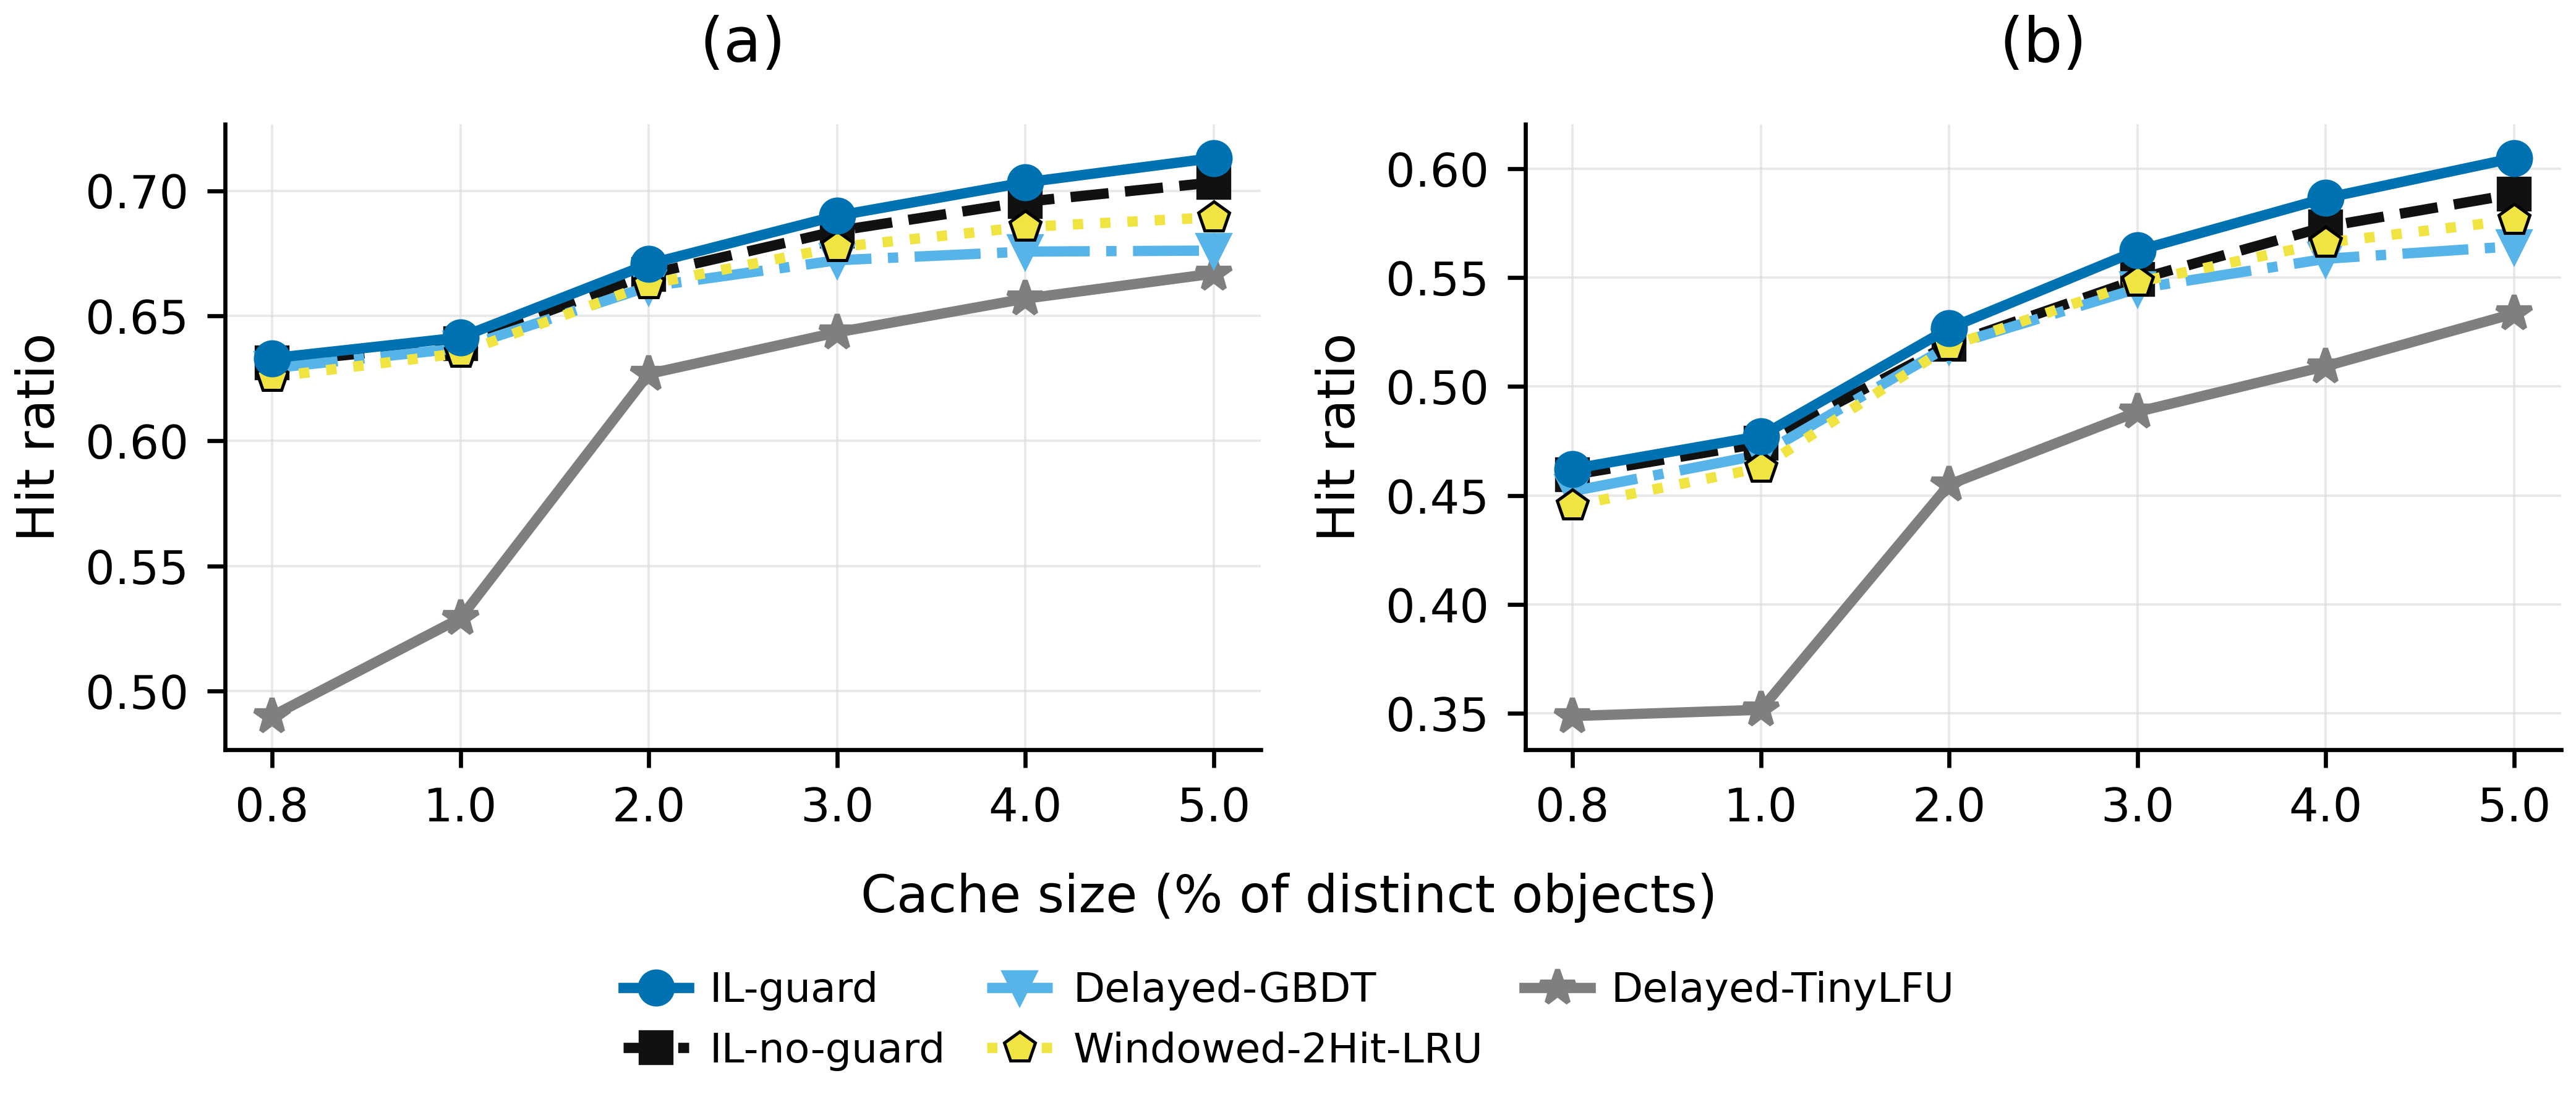

*System-level hit-ratio comparison under post-warm-up trace-driven replay. IL-guard is compared with IL-no-guard, Delayed-GBDT, Windowed-2Hit-LRU, and Delayed-TinyLFU on Wikipedia-2007 web and Wiki-CDN-2018 using the same cache-size sweep and one-slot delayed-apply protocol.*

In [7]:
fig_name = "Fig3_system_hit_ratio_comparison_paper"
legacy_fig3_name = "Fig3_system_baseline_hr_paper"
SYSTEM_POLICY_ORDER = ["IL-guard", "IL-no-guard", "Delayed-GBDT", "Windowed-2Hit-LRU", "Delayed-TinyLFU"]
SEARCH_ROOTS = [Path("."), Path("results"), Path("results/baselines"), Path("results/windowed_2hit_lru"), Path("results/guardrails_signal_v2_cap020"), Path("results/guardrails_signal_v2_cap020_budget_controls")]
SYSTEM_SUMMARY_FILES = {
    ("wiki2018", "Delayed-TinyLFU"): "wiki2018-001_summary_baseline_tinylfu_delayed_all_sizes.json",
    ("wiki2018", "Delayed-GBDT"): "wiki2018-001_summary_delayed_gdbt_A2_all_sizes.json",
    ("wiki2018", "Windowed-2Hit-LRU"): "wiki2018-001_summary_windowed_2hit_lru_w1slot_all_sizes.json",
    ("wikipedia_september_2007", "Delayed-TinyLFU"): "wikipedia2007-001_summary_baseline_tinylfu_delayed_all_sizes.json",
    ("wikipedia_september_2007", "Delayed-GBDT"): "wikipedia2007-001_summary_delayed_gdbt_A2_all_sizes.json",
    ("wikipedia_september_2007", "Windowed-2Hit-LRU"): "wikipedia2007-001_summary_windowed_2hit_lru_w1slot_all_sizes.json",
}
FULL_GUARD_CANDIDATES = {
    "wiki2018": [
        Path("results/guardrails_signal_v2_cap020/wiki2018/001_summary_ilnse_A2_guardv2_full_cap020_NB_all_sizes.json"),
        Path("results/guardrails_signal_v2/wiki2018/001_summary_ilnse_A2_guardv2_full_cap020_NB_all_sizes.json"),
    ],
    "wikipedia_september_2007": [
        Path("results/guardrails_signal_v2_cap020/wikipedia_september_2007/001_summary_ilnse_A2_guardv2_full_cap020_NB_all_sizes.json"),
        Path("results/guardrails_signal_v2/wikipedia_september_2007/001_summary_ilnse_A2_guardv2_full_cap020_NB_all_sizes.json"),
    ],
}
NO_GUARD_CANDIDATES = {
    "wiki2018": [
        Path("results/guardrails_signal_v2_cap020/wiki2018/001_summary_ilnse_A2_guardv2_no_guard_legacy_NB_all_sizes.json"),
        Path("results/guardrails_signal_v2/wiki2018/001_summary_ilnse_A2_guardv2_no_guard_legacy_NB_all_sizes.json"),
        Path("results/wiki2018/wiki2018-001_001_summary_ilnse_A2_guard_no_guard_NB_all_sizes.json"),
    ],
    "wikipedia_september_2007": [
        Path("results/guardrails_signal_v2_cap020/wikipedia_september_2007/001_summary_ilnse_A2_guardv2_no_guard_legacy_NB_all_sizes.json"),
        Path("results/guardrails_signal_v2/wikipedia_september_2007/001_summary_ilnse_A2_guardv2_no_guard_legacy_NB_all_sizes.json"),
        Path("results/wikipedia_september_2007/wikipedia2007-001_001_summary_ilnse_A2_guard_no_guard_NB_all_sizes.json"),
    ],
}
cache_object_to_percent = df_budget[["dataset", "cache_size_objects", "capacity_percent"]].drop_duplicates().set_index(["dataset", "cache_size_objects"])["capacity_percent"].to_dict()


def find_first_exact(file_name):
    seen = set()
    for root in SEARCH_ROOTS:
        if not root.exists():
            continue
        for path in sorted(root.rglob(file_name)):
            if path.resolve() in seen:
                continue
            seen.add(path.resolve())
            return path
    return None


def curve_rows_from_summary(path, dataset, policy):
    register_source_file(path, file_kind="json")
    data = json.loads(Path(path).read_text(encoding="utf-8"))
    curve = data.get("hr_curve") or data.get("results") or data.get("runs")
    rows = []
    if isinstance(curve, list):
        for idx, item in enumerate(curve):
            cache_objects = None
            if isinstance(item, dict):
                cache_objects = item.get("cache_size_objects", item.get("capacity_objects", item.get("cache_size")))
                cap_percent = item.get("capacity_percent")
                if cap_percent is None and cache_objects is not None:
                    cap_percent = cache_object_to_percent.get((dataset, int(cache_objects)))
                hit_ratio = item.get("hit_ratio")
            else:
                hit_ratio = item
                if "cache_size_percentages" in data:
                    cap_percent = data["cache_size_percentages"][idx]
                else:
                    cache_objects = data.get("cache_sizes", [None] * len(curve))[idx]
                    cap_percent = cache_object_to_percent.get((dataset, int(cache_objects))) if cache_objects is not None else None
            if cap_percent is not None and hit_ratio is not None and float(cap_percent) in CACHE_ORDER:
                rows.append({
                    "dataset": dataset,
                    "Dataset": DATASET_LABELS[dataset],
                    "Method": policy,
                    "capacity_percent": float(cap_percent),
                    "cache_size_objects": int(cache_objects) if cache_objects is not None else np.nan,
                    "hit_ratio": float(hit_ratio),
                    "source_path": str(path),
                })
    return rows


system_summary_paths = {}
for dataset in DATASETS:
    full_path = next((p for p in FULL_GUARD_CANDIDATES[dataset] if p.exists()), None)
    if full_path is None:
        raise FileNotFoundError(f"Missing IL-guard all-size summary for {dataset}.")
    system_summary_paths[(dataset, "IL-guard")] = full_path

    no_guard_path = next((p for p in NO_GUARD_CANDIDATES[dataset] if p.exists()), None)
    if no_guard_path is None:
        raise FileNotFoundError(f"Missing IL-no-guard all-size summary for {dataset}.")
    system_summary_paths[(dataset, "IL-no-guard")] = no_guard_path

for (dataset, policy), file_name in SYSTEM_SUMMARY_FILES.items():
    path = find_first_exact(file_name)
    if path is None:
        raise FileNotFoundError(f"Missing required baseline file {file_name} for {dataset} / {policy}.")
    system_summary_paths[(dataset, policy)] = path

system_rows = []
for dataset in DATASETS:
    for policy in SYSTEM_POLICY_ORDER:
        system_rows.extend(curve_rows_from_summary(system_summary_paths[(dataset, policy)], dataset, policy))

system_curve_df = pd.DataFrame(system_rows)
missing_system = []
for dataset in DATASETS:
    for policy in SYSTEM_POLICY_ORDER:
        got = sorted(float(x) for x in system_curve_df.loc[(system_curve_df["dataset"] == dataset) & (system_curve_df["Method"] == policy), "capacity_percent"].dropna().unique())
        missing_caps = [cap for cap in CACHE_ORDER if cap not in got]
        if missing_caps:
            missing_system.append(f"{DATASET_LABELS[dataset]} / {policy}: missing capacities {missing_caps}")
if missing_system:
    raise ValueError("Incomplete system-level baseline data: " + "; ".join(missing_system))

fig, axes = plt.subplots(1, 2, figsize=(DOUBLE_COL_WIDTH, 3.45), sharey=False)
for ax, dataset, panel in zip(axes, DATASETS, ["(a)", "(b)"]):
    sub_dataset = system_curve_df[system_curve_df["dataset"] == dataset]
    y_values = []
    for policy in SYSTEM_POLICY_ORDER:
        sub = sub_dataset[sub_dataset["Method"] == policy].copy()
        sub = sort_by_cache(sub.rename(columns={"Method": "variant"})).rename(columns={"variant": "Method"})
        style = method_style(policy)
        ax.plot(cache_x_positions(sub["capacity_percent"]), sub["hit_ratio"], label=policy, **style)
        y_values.extend(sub["hit_ratio"].tolist())
    set_padded_ylim(ax, y_values, pad_frac=0.06)
    ax.set_ylabel("Hit ratio")
    apply_cache_axis(ax)
    add_panel_label(ax, panel)
for ax in axes:
    ax.set_xlabel("")
fig.supxlabel("Cache size (% of distinct objects)", y=0.165, fontsize=10)
fig.tight_layout(rect=[0, 0.28, 1, 0.94])
add_figure_legend_below(fig, axes, ncol=3, y=0.020, bottom=0.30)
record_figure_color_usage(fig_name, "method", SYSTEM_POLICY_ORDER)
paths = save_figure(fig, fig_name)
save_figure_alias(paths, legacy_fig3_name)
display_figure(paths["png"])
plt.close(fig)

baseline_source_paths = sorted({Path(p) for p in system_summary_paths.values()}, key=lambda p: str(p))
caption = "System-level hit-ratio comparison under post-warm-up trace-driven replay. IL-guard is compared with IL-no-guard, Delayed-GBDT, Windowed-2Hit-LRU, and Delayed-TinyLFU on Wikipedia-2007 web and Wiki-CDN-2018 using the same cache-size sweep and one-slot delayed-apply protocol."
display_caption(caption)
add_caption("figure", fig_name, caption)
record_manifest(fig_name, "figure", paths.values(), baseline_source_paths, "System-level hit-ratio comparison across all main methods and workloads.", "main_paper", "Paper Fig. 3 starts the results narrative with the overall system comparison.")
add_validation("System-level baseline legend completeness", "OK", f"Methods: {SYSTEM_POLICY_ORDER}")


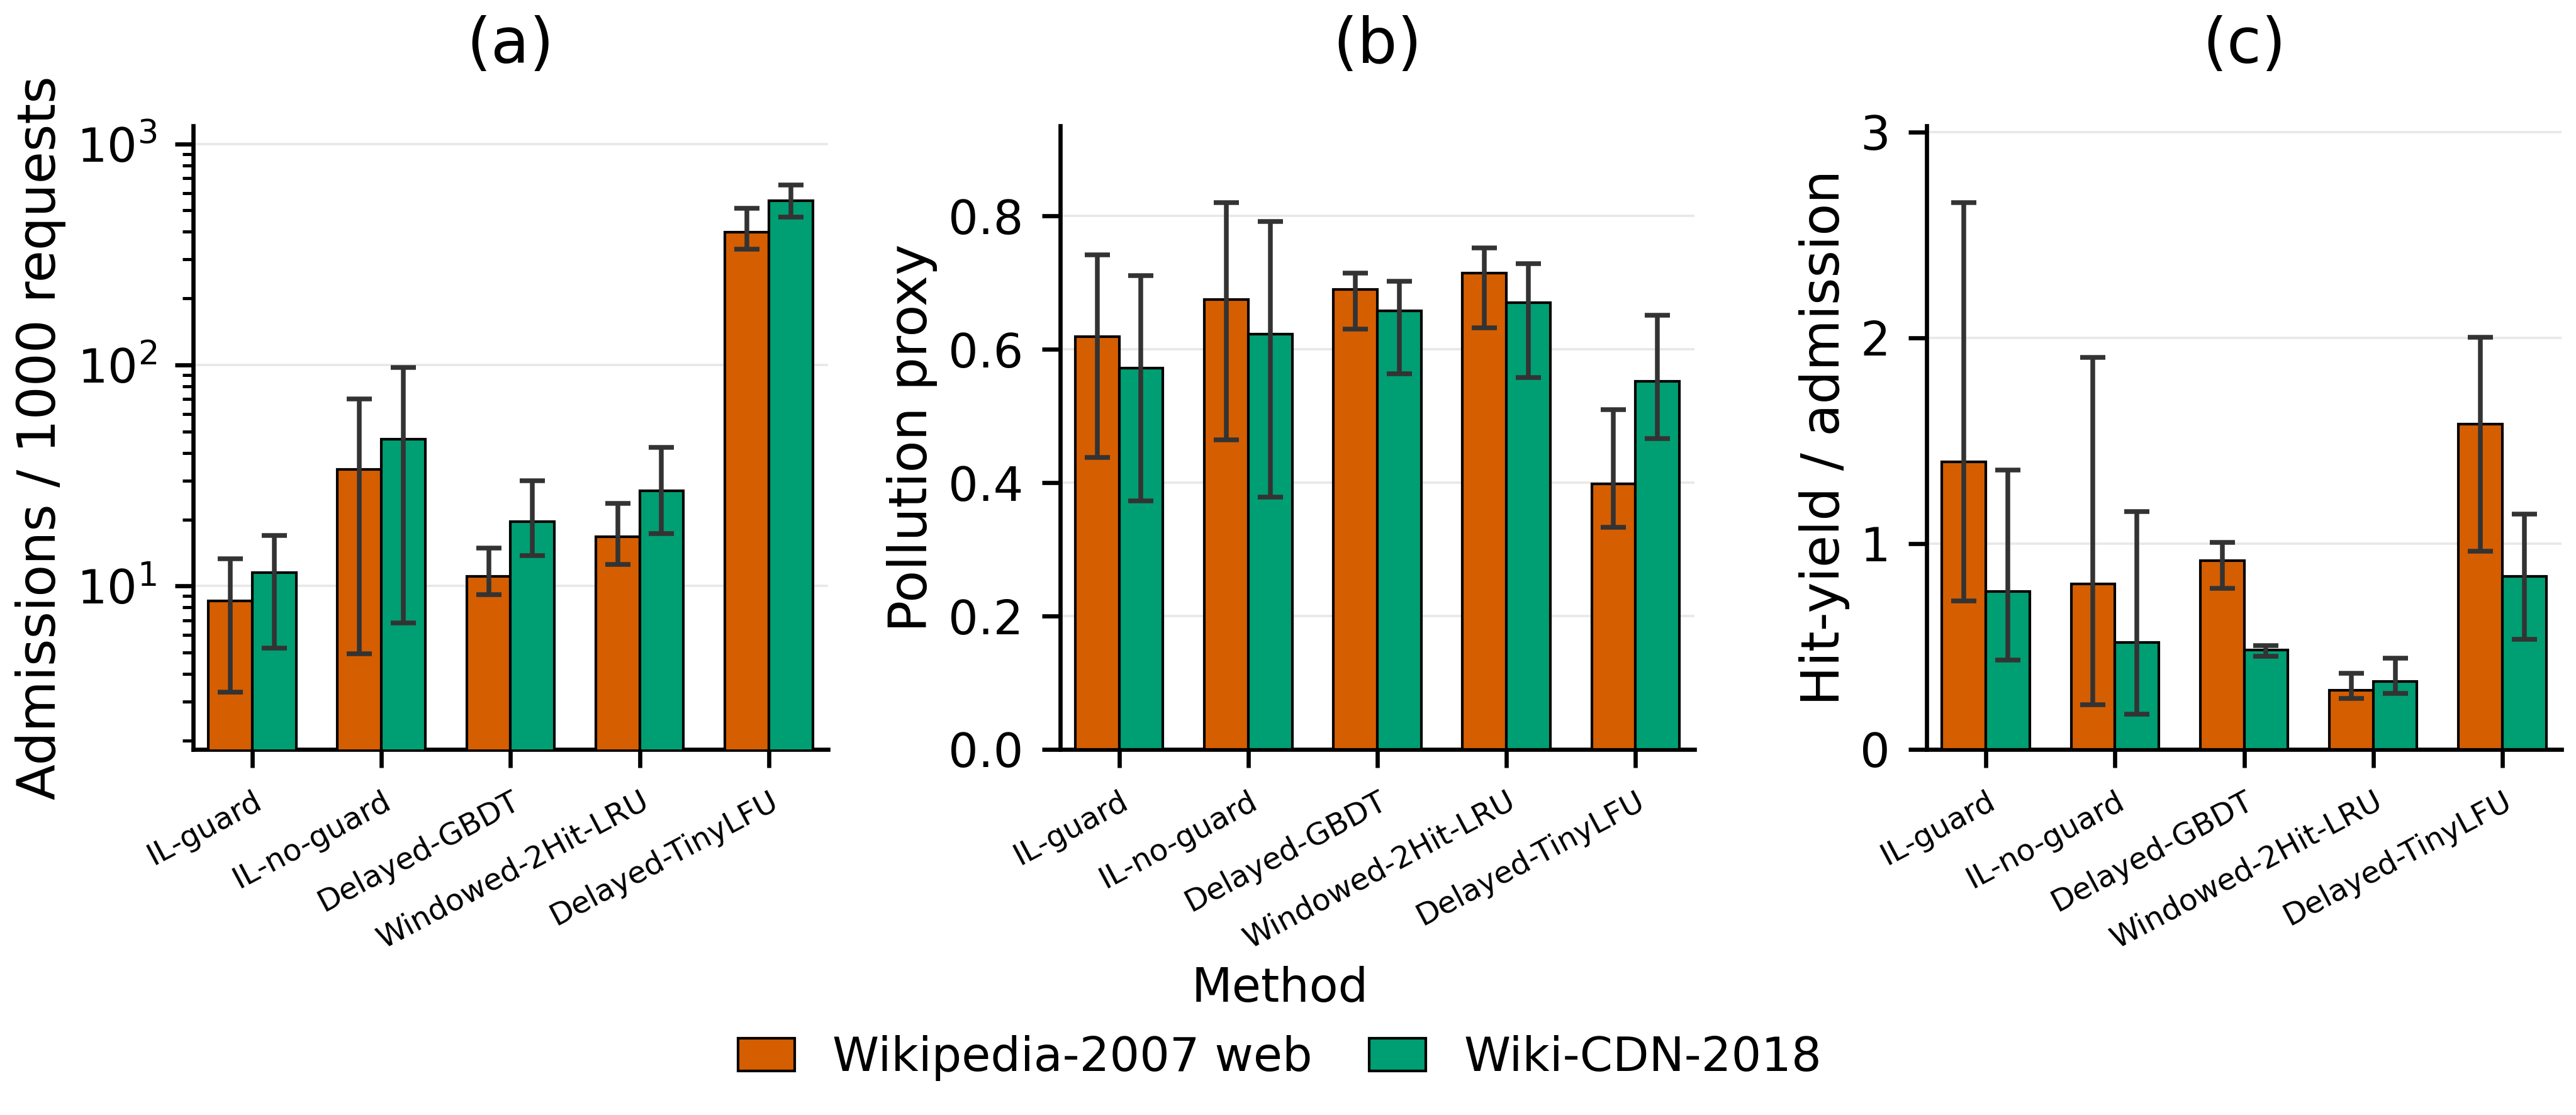

*Admission-side diagnostics across baselines. Panels summarize insertion pressure, pollution proxy, and hit-yield per admission over the same post-warm-up replay interval as Fig. 3. For learner-based admission variants, diagnostics are computed from recorded admission events. For baselines without explicit admission-event outcomes, proxy quantities are derived consistently from replay summaries and are used as contextual indicators. The intended conclusion is the best hit-ratio/admission-efficiency trade-off, not universal dominance on every diagnostic.*

Dataset,Method,Avg HR,Admissions / 1000 requests,Pollution proxy,Hit-yield / admission,Admission precision,Metric source
Wikipedia-2007 web,IL-guard,0.675241,8.574,0.619,1.395,0.099,event-log
Wikipedia-2007 web,IL-no-guard,0.669959,33.629,0.674,0.802,0.068,event-log
Wikipedia-2007 web,Delayed-GBDT,0.658630,11.045,0.690,0.917,0.072,event-log
Wikipedia-2007 web,Windowed-2Hit-LRU,0.662582,16.682,0.714,0.286,n/a,event-log
Wikipedia-2007 web,Delayed-TinyLFU,0.602206,397.794,0.398,1.581,n/a,replay-summary-proxy
Wiki-CDN-2018,IL-guard,0.536710,11.507,0.572,0.766,0.107,event-log
Wiki-CDN-2018,IL-no-guard,0.527306,46.156,0.623,0.520,0.079,event-log
Wiki-CDN-2018,Delayed-GBDT,0.517902,19.569,0.658,0.484,0.073,event-log
Wiki-CDN-2018,Windowed-2Hit-LRU,0.519497,27.007,0.670,0.330,n/a,event-log
Wiki-CDN-2018,Delayed-TinyLFU,0.447740,552.260,0.552,0.841,n/a,replay-summary-proxy


*Admission diagnostics summary. Lower insertion pressure and pollution proxy are better; higher hit-yield per admission and HR are better. Proxy-derived diagnostics are used only for contextual comparison.*

In [8]:
fig_name = "Fig4_admission_diagnostics_across_baselines_paper"
ADMISSION_METHOD_ORDER = SYSTEM_POLICY_ORDER
ADMISSION_METRIC_ALIASES = {
    "admissions_per_1000_requests": ["admissions_per_1000_requests", "avg_admissions_per_1000_requests", "insertions_per_1000_requests"],
    "pollution_ratio": ["pollution_ratio", "avg_pollution_ratio", "pollution_proxy"],
    "hit_yield_per_admission": ["hit_yield_per_admission", "avg_hit_yield_per_admission", "hits_per_admission"],
}
OPTIONAL_ADMISSION_PRECISION_KEYS = ["admission_precision", "avg_admission_precision", "aggregate_admission_precision", "admission_precision_total"]


def finite_number(value):
    if value is None:
        return False
    try:
        return bool(np.isfinite(float(value)))
    except (TypeError, ValueError):
        return False


def resolve_summary_path(candidate, dataset, method, cache_size_objects):
    if candidate:
        path = Path(candidate)
        if path.exists():
            return path
        file_name = path.name
        for root in SEARCH_ROOTS:
            if not root.exists():
                continue
            hits = sorted(root.rglob(file_name))
            if hits:
                return hits[0]
    if method == "Delayed-GBDT":
        file_name = f"001_summary_delayed_gdbt_A2_{int(cache_size_objects)}.json"
    elif method == "Delayed-TinyLFU":
        file_name = f"001_summary_baseline_tinylfu_delayed_{int(cache_size_objects)}.json"
    else:
        return None
    dataset_dir = Path("results") / dataset
    direct = dataset_dir / file_name
    if direct.exists():
        return direct
    hits = sorted(dataset_dir.glob(f"*summary*{int(cache_size_objects)}.json"))
    for hit in hits:
        text = hit.name
        if method == "Delayed-GBDT" and "delayed_gdbt" in text:
            return hit
        if method == "Delayed-TinyLFU" and "tinylfu" in text:
            return hit
    return None


def records_from_summary(path, dataset, method):
    data = json.loads(Path(path).read_text(encoding="utf-8"))
    curve = data.get("results") or data.get("runs") or data.get("hr_curve") or []
    if not isinstance(curve, list):
        return []
    rows = []
    for idx, item in enumerate(curve):
        row = item.copy() if isinstance(item, dict) else {"hit_ratio": item}
        cache_size = row.get("cache_size_objects", row.get("capacity_objects", row.get("cache_size")))
        if cache_size is None and "cache_sizes" in data and idx < len(data["cache_sizes"]):
            cache_size = data["cache_sizes"][idx]
            row["cache_size_objects"] = cache_size
        cap_percent = row.get("capacity_percent")
        if cap_percent is None and "cache_size_percentages" in data and idx < len(data["cache_size_percentages"]):
            cap_percent = data["cache_size_percentages"][idx]
        if cap_percent is None and cache_size is not None:
            cap_percent = cache_object_to_percent.get((dataset, int(cache_size)))
        if cap_percent is None or float(cap_percent) not in CACHE_ORDER:
            continue

        detail = {}
        detail_path = resolve_summary_path(row.get("summary_path"), dataset, method, cache_size)
        if detail_path is not None:
            register_source_file(detail_path, file_kind="json")
            detail = json.loads(detail_path.read_text(encoding="utf-8"))
        merged = {**data, **row, **detail}
        if isinstance(row.get("diagnostic_summary"), dict):
            merged.update(row["diagnostic_summary"])
        if isinstance(detail.get("diagnostic_summary"), dict):
            merged.update(detail["diagnostic_summary"])
        merged["dataset"] = dataset
        merged["Dataset"] = DATASET_LABELS[dataset]
        merged["Method"] = method
        merged["capacity_percent"] = float(cap_percent)
        merged["cache_size_objects"] = int(cache_size) if cache_size is not None else np.nan
        merged["source_path"] = str(detail_path or path)
        rows.append(merged)
    return rows


def resolve_metric(record, metric):
    for key in ADMISSION_METRIC_ALIASES[metric]:
        if finite_number(record.get(key)):
            return float(record[key]), key
    if metric == "admissions_per_1000_requests":
        for total_key in ["total_selected_admissions", "admit_selected_total", "scheduled_admissions_total", "admit_applied_total", "total_applied_admissions"]:
            if finite_number(record.get(total_key)) and finite_number(record.get("cache_requests")) and float(record["cache_requests"]) > 0:
                return float(record[total_key]) / float(record["cache_requests"]) * 1000.0, f"{total_key}/cache_requests"
        if record.get("baseline_type") == "standard_cache_baseline" and finite_number(record.get("cache_hits")) and finite_number(record.get("cache_requests")):
            return (float(record["cache_requests"]) - float(record["cache_hits"])) / float(record["cache_requests"]) * 1000.0, "replay-summary-proxy:misses_per_1000_requests"
    elif metric == "pollution_ratio":
        for key in ["aggregate_pollution_ratio", "pollution_rate_total"]:
            if finite_number(record.get(key)):
                return float(record[key]), key
        if finite_number(record.get("pollution_count")) and finite_number(record.get("pollution_total")) and float(record["pollution_total"]) > 0:
            return float(record["pollution_count"]) / float(record["pollution_total"]), "pollution_count/pollution_total"
        if record.get("baseline_type") == "standard_cache_baseline" and finite_number(record.get("hit_ratio")):
            return 1.0 - float(record["hit_ratio"]), "replay-summary-proxy:miss_ratio"
    elif metric == "hit_yield_per_admission":
        for key in ["aggregate_hit_yield_per_applied_admission", "hit_yield_total", "admission_hit_yield"]:
            if finite_number(record.get(key)):
                return float(record[key]), key
        for denom_key in ["admit_applied_total", "total_applied_admissions", "admit_selected_total", "total_selected_admissions"]:
            if finite_number(record.get("hits_from_admitted_total")) and finite_number(record.get(denom_key)) and float(record[denom_key]) > 0:
                return float(record["hits_from_admitted_total"]) / float(record[denom_key]), f"hits_from_admitted_total/{denom_key}"
        if record.get("baseline_type") == "standard_cache_baseline" and finite_number(record.get("cache_hits")) and finite_number(record.get("cache_requests")):
            admissions = float(record["cache_requests"]) - float(record["cache_hits"])
            if admissions > 0:
                return float(record["cache_hits"]) / admissions, "replay-summary-proxy:cache_hits/misses"
    return np.nan, None


def resolve_optional_precision(record):
    for key in OPTIONAL_ADMISSION_PRECISION_KEYS:
        if finite_number(record.get(key)):
            return float(record[key])
    return np.nan


def metric_source_from_keys(keys):
    keys = [str(k) for k in keys if isinstance(k, str) and k]
    if not keys:
        return "N/A"
    if any(k.startswith("replay-summary-proxy") or "proxy" in k for k in keys):
        return "replay-summary-proxy"
    return "event-log"


admission_rows = []
metric_resolution_rows = []
for dataset in DATASETS:
    for method in ADMISSION_METHOD_ORDER:
        summary_path = system_summary_paths[(dataset, method)]
        register_source_file(summary_path, file_kind="json")
        for record in records_from_summary(summary_path, dataset, method):
            out = {
                "dataset": dataset,
                "Dataset": DATASET_LABELS[dataset],
                "Method": method,
                "capacity_percent": float(record["capacity_percent"]),
                "cache_size_objects": record.get("cache_size_objects"),
                "hit_ratio": float(record["hit_ratio"]) if finite_number(record.get("hit_ratio")) else np.nan,
                "Admission precision": resolve_optional_precision(record),
                "source_path": record.get("source_path", str(summary_path)),
            }
            source_keys = []
            for metric in ADMISSION_METRIC_ALIASES:
                value, source_key = resolve_metric(record, metric)
                out[metric] = value
                out[f"{metric}_source_key"] = source_key
                source_keys.append(source_key)
                metric_resolution_rows.append({
                    "Dataset": out["Dataset"],
                    "Method": method,
                    "Capacity": out["capacity_percent"],
                    "Metric": metric,
                    "Source key": source_key,
                })
            out["Metric source"] = metric_source_from_keys(source_keys)
            admission_rows.append(out)

admission_diagnostics_df = pd.DataFrame(admission_rows)
missing = []
for dataset in DATASETS:
    for method in ADMISSION_METHOD_ORDER:
        for capacity in CACHE_ORDER:
            sub = admission_diagnostics_df[(admission_diagnostics_df["dataset"] == dataset) & (admission_diagnostics_df["Method"] == method) & np.isclose(admission_diagnostics_df["capacity_percent"], capacity)]
            if sub.empty:
                missing.append(f"{DATASET_LABELS[dataset]} / {method} / {capacity}: missing row")
                continue
            for metric in ADMISSION_METRIC_ALIASES:
                if not finite_number(sub.iloc[0][metric]):
                    missing.append(f"{DATASET_LABELS[dataset]} / {method} / {capacity}: missing {metric}")
if missing:
    raise ValueError("Admission diagnostics are incomplete: " + "; ".join(missing))

resolution_df = pd.DataFrame(metric_resolution_rows)
proxy_sources = resolution_df[resolution_df["Source key"].fillna("").str.contains("proxy", regex=False)]
if not proxy_sources.empty:
    add_validation("Admission diagnostic proxy derivations", "WARN", "; ".join(sorted(proxy_sources["Source key"].dropna().unique())))
add_validation("Admission diagnostics completeness", "OK", "All dataset-method-capacity rows contain the required admission diagnostics.")

fig4_admission_methods = ADMISSION_METHOD_ORDER.copy()
ADMISSION_METHOD_DISPLAY = {
    "IL-guard": "IL-guard",
    "IL-no-guard": "IL-no-guard",
    "Delayed-GBDT": "Delayed-GBDT",
    "Windowed-2Hit-LRU": "Windowed-2Hit-LRU",
    "Delayed-TinyLFU": "Delayed-TinyLFU",
}
fig4_admission_metrics = ["admissions_per_1000_requests", "pollution_ratio", "hit_yield_per_admission"]
panel_specs = [
    ("admissions_per_1000_requests", "Admissions / 1000 requests", "(a)"),
    ("pollution_ratio", "Pollution proxy", "(b)"),
    ("hit_yield_per_admission", "Hit-yield / admission", "(c)"),
]
bar_summary = admission_diagnostics_df.groupby(["Dataset", "Method"], as_index=False).agg(
    **{
        "Avg HR": ("hit_ratio", "mean"),
        "Admissions / 1000 requests": ("admissions_per_1000_requests", "mean"),
        "Pollution proxy": ("pollution_ratio", "mean"),
        "Hit-yield / admission": ("hit_yield_per_admission", "mean"),
        "Admission precision": ("Admission precision", "mean"),
        "Metric source": ("Metric source", lambda x: "replay-summary-proxy" if "replay-summary-proxy" in set(x) else ("event-log" if "event-log" in set(x) else "N/A")),
    }
)

x = np.arange(len(ADMISSION_METHOD_ORDER), dtype=float)
width = 0.34

fig, axes = plt.subplots(1, 3, figsize=(DOUBLE_COL_WIDTH, 3.25), sharex=False)
for ax, (metric, ylabel, panel_label) in zip(axes, panel_specs):
    y_values = []
    for offset, dataset in zip([-width / 2, width / 2], DATASETS):
        label = DATASET_LABELS[dataset]
        means, yerr_low, yerr_high = [], [], []
        for method in ADMISSION_METHOD_ORDER:
            vals = admission_diagnostics_df.loc[
                (admission_diagnostics_df["dataset"] == dataset) & (admission_diagnostics_df["Method"] == method),
                metric,
            ].astype(float)
            mean = float(vals.mean())
            lo = float(vals.min())
            hi = float(vals.max())
            means.append(mean)
            yerr_low.append(mean - lo)
            yerr_high.append(hi - mean)
            y_values.extend(vals.tolist())
        ax.bar(
            x + offset,
            means,
            width,
            label=label,
            color=DATASET_COLORS[label],
            edgecolor="black",
            linewidth=0.5,
            yerr=np.vstack([yerr_low, yerr_high]),
            error_kw={"elinewidth": 0.9, "capsize": 2.4, "capthick": 0.9, "ecolor": ERRORBAR_COLOR},
            zorder=3,
        )
    add_panel_label(ax, panel_label)
    ax.set_ylabel(ylabel, fontsize=10, labelpad=2.0)
    ax.set_xticks(x)
    ax.set_xticklabels([ADMISSION_METHOD_DISPLAY[m] for m in ADMISSION_METHOD_ORDER], rotation=28, ha="right", rotation_mode="anchor", fontsize=5.8)
    ax.tick_params(axis="y", labelsize=9)
    ax.margins(x=0.025)
    ax.yaxis.grid(True, color=GRID_COLOR)
    ax.xaxis.grid(False)
    if metric == "admissions_per_1000_requests":
        ax.set_yscale("log")
        positive = [v for v in y_values if v > 0]
        ax.set_ylim(max(min(positive) * 0.55, 0.1), max(positive) * 1.85)
    else:
        ax.set_ylim(0, max(y_values) * 1.14)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.015),
    ncol=2,
    title="Method",
    title_fontsize=9,
    frameon=False,
    fontsize=9,
    handlelength=1.2,
    columnspacing=1.2,
)
fig.tight_layout(rect=[0.010, 0.22, 0.995, 0.985], w_pad=1.15)
fig.subplots_adjust(bottom=0.32)
fig4_panel_a_log_scale = True
record_figure_color_usage(fig_name, "dataset", [DATASET_LABELS[d] for d in DATASETS])
paths = save_figure(fig, fig_name)
display_figure(paths["png"])
plt.close(fig)

caption = "Admission-side diagnostics across baselines. Panels summarize insertion pressure, pollution proxy, and hit-yield per admission over the same post-warm-up replay interval as Fig. 3. For learner-based admission variants, diagnostics are computed from recorded admission events. For baselines without explicit admission-event outcomes, proxy quantities are derived consistently from replay summaries and are used as contextual indicators. The intended conclusion is the best hit-ratio/admission-efficiency trade-off, not universal dominance on every diagnostic."
display_caption(caption)
add_caption("figure", fig_name, caption)
record_manifest(fig_name, "figure", paths.values(), baseline_source_paths, "Admission-side diagnostics across baselines; supports hit-ratio/admission-efficiency trade-off rather than universal diagnostic dominance.", "main_paper", "Panel (a) uses a log y-axis because Delayed-TinyLFU has much larger insertion pressure.")
table_name = "Table_III_admission_diagnostics_across_baselines_paper"
bar_summary["_dataset_order"] = bar_summary["Dataset"].map({DATASET_LABELS[d]: i for i, d in enumerate(DATASETS)})
bar_summary["_method_order"] = bar_summary["Method"].map({m: i for i, m in enumerate(ADMISSION_METHOD_ORDER)})
bar_summary = bar_summary.sort_values(["_dataset_order", "_method_order"]).drop(columns=["_dataset_order", "_method_order"])
table_iii_admission = bar_summary[["Dataset", "Method", "Avg HR", "Admissions / 1000 requests", "Pollution proxy", "Hit-yield / admission", "Admission precision", "Metric source"]]
table_paths = save_table(table_iii_admission, table_name)
append_latex_note(table_paths["tex"], "Lower insertion pressure and pollution proxy are better; higher hit-yield per admission and HR are better. Proxy-derived diagnostics are used only for contextual comparison.")
display(format_table_for_display(table_iii_admission, {"Avg HR": "{:.6f}", "Admissions / 1000 requests": "{:.3f}", "Pollution proxy": "{:.3f}", "Hit-yield / admission": "{:.3f}", "Admission precision": "{:.3f}"}))
table_caption = "Admission diagnostics summary. Lower insertion pressure and pollution proxy are better; higher hit-yield per admission and HR are better. Proxy-derived diagnostics are used only for contextual comparison."
display_caption(table_caption)
add_caption("table", table_name, table_caption)
record_manifest(table_name, "table", table_paths.values(), baseline_source_paths, "Admission diagnostics summary with metric-source disclosure.", "main_paper", "Companion table for Fig. 4 admission diagnostics.")


In [9]:
table_name = "Table_II_system_level_average_hr_paper"
system_table_rows = []
for dataset in DATASETS:
    full_avg = float(system_curve_df[(system_curve_df["dataset"] == dataset) & (system_curve_df["Method"] == "IL-guard")]["hit_ratio"].mean())
    dataset_rows = []
    for policy in SYSTEM_POLICY_ORDER:
        vals = system_curve_df[(system_curve_df["dataset"] == dataset) & (system_curve_df["Method"] == policy)]["hit_ratio"].astype(float)
        dataset_rows.append({
            "Dataset": DATASET_LABELS[dataset],
            "Method": policy,
            "Avg HR": float(vals.mean()),
            "Best HR": float(vals.max()),
            "Worst HR": float(vals.min()),
            "Δ Avg HR vs IL-guard": float(vals.mean() - full_avg),
        })
    ranked = pd.DataFrame(dataset_rows).sort_values("Avg HR", ascending=False).reset_index(drop=True)
    ranked["Rank by Avg HR"] = np.arange(1, len(ranked) + 1)
    system_table_rows.extend(ranked.to_dict("records"))
table_ii = pd.DataFrame(system_table_rows)[["Dataset", "Method", "Avg HR", "Best HR", "Worst HR", "Δ Avg HR vs IL-guard", "Rank by Avg HR"]]
paths = save_table(table_ii, table_name)
display(format_table_for_display(table_ii, {"Avg HR": "{:.6f}", "Best HR": "{:.6f}", "Worst HR": "{:.6f}", "Δ Avg HR vs IL-guard": "{:.6f}"}))
caption = "System-level average hit-ratio summary. The table complements Fig. 3 by reporting averages, best and worst values, IL-guard-relative deltas, and rank across cache sizes."
display_caption(caption)
add_caption("table", table_name, caption)
record_manifest(table_name, "table", [paths["csv"], paths["tex"]], baseline_source_paths, "Average HR summary for the system-level baseline comparison.", "main_paper", "Regenerated from the system-level baseline curves using final public labels.")


Dataset,Method,Avg HR,Best HR,Worst HR,Δ Avg HR vs IL-guard,Rank by Avg HR
Wikipedia-2007 web,IL-guard,0.675241,0.713059,0.633067,0.000000,1
Wikipedia-2007 web,IL-no-guard,0.669959,0.703309,0.631316,-0.005281,2
Wikipedia-2007 web,Windowed-2Hit-LRU,0.662582,0.689329,0.625542,-0.012659,3
Wikipedia-2007 web,Delayed-GBDT,0.658630,0.676069,0.629096,-0.016610,4
Wikipedia-2007 web,Delayed-TinyLFU,0.602206,0.666884,0.490100,-0.073034,5
Wiki-CDN-2018,IL-guard,0.536710,0.605007,0.462163,0.000000,1
Wiki-CDN-2018,IL-no-guard,0.527306,0.588422,0.459430,-0.009403,2
Wiki-CDN-2018,Windowed-2Hit-LRU,0.519497,0.576509,0.445253,-0.017212,3
Wiki-CDN-2018,Delayed-GBDT,0.517902,0.564434,0.451931,-0.018808,4
Wiki-CDN-2018,Delayed-TinyLFU,0.447740,0.533556,0.348638,-0.088969,5


*System-level average hit-ratio summary. The table complements Fig. 3 by reporting averages, best and worst values, IL-guard-relative deltas, and rank across cache sizes.*

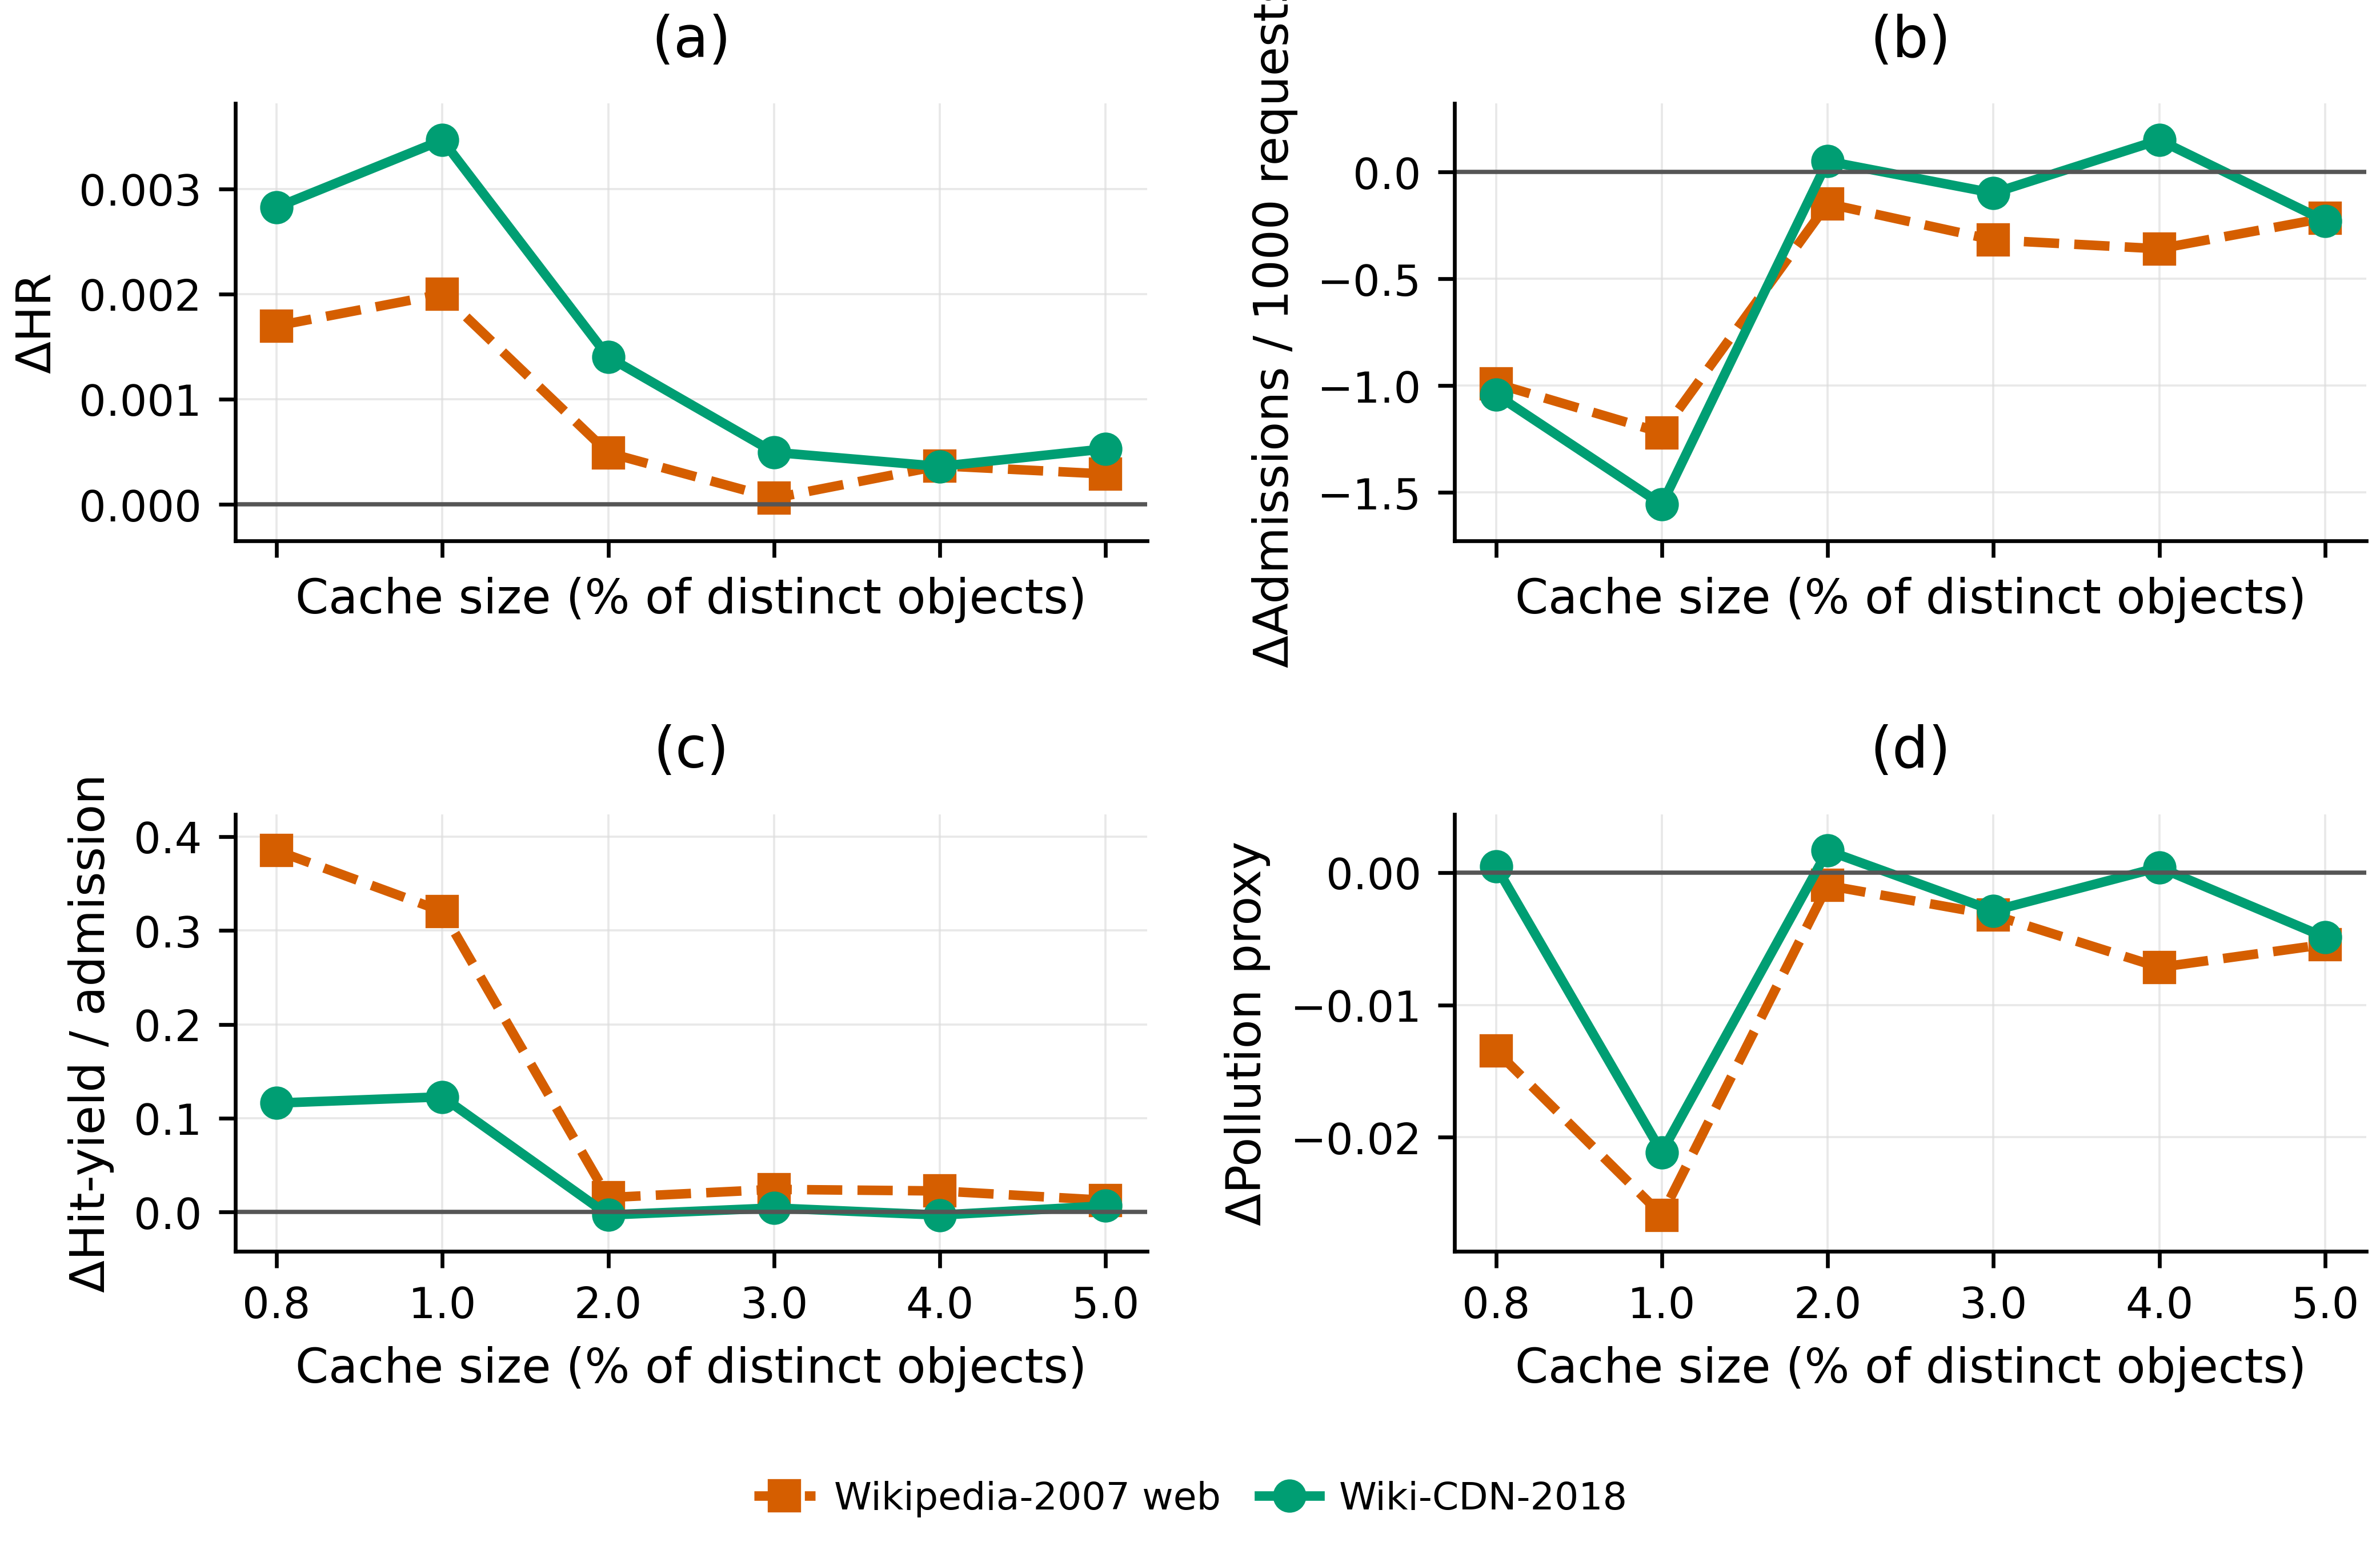

*Effective-precision feedback attribution relative to a cap-only controller. Positive ΔHR and Δhit-yield together with reduced admission pressure or pollution indicate that lag-robust precision feedback improves admission efficiency rather than merely increasing insertions.*

In [10]:
fig_name = "Fig5_effective_precision_feedback_delta_paper"
precision_metrics = [
    ("hit_ratio", "ΔHR", "(a)"),
    ("admissions_per_1000_requests", "ΔAdmissions / 1000 requests", "(b)"),
    ("hit_yield_per_admission", "ΔHit-yield / admission", "(c)"),
    ("pollution_ratio", "ΔPollution proxy", "(d)"),
]
fig, axes = plt.subplots(2, 2, figsize=(DOUBLE_COL_WIDTH, 5.0), sharex=True)
delta_rows = []
for dataset in DATASETS:
    cap_only = df_precision[(df_precision["dataset"] == dataset) & (df_precision["variant"] == "cap_only_cap020")].set_index("capacity_percent")
    precision_only = df_precision[(df_precision["dataset"] == dataset) & (df_precision["variant"] == "precision_only_cap020")].set_index("capacity_percent")
    for capacity in CACHE_ORDER:
        if capacity not in cap_only.index or capacity not in precision_only.index:
            raise ValueError(f"Missing cap-only or precision-only row for {DATASET_LABELS[dataset]} at capacity {capacity}.")
        row = {"dataset": dataset, "Dataset": DATASET_LABELS[dataset], "capacity_percent": capacity}
        for metric, _, _ in precision_metrics:
            row[f"delta_{metric}"] = float(precision_only.loc[capacity, metric] - cap_only.loc[capacity, metric])
        delta_rows.append(row)
precision_delta_df = pd.DataFrame(delta_rows)
for ax, (metric, ylabel, panel) in zip(axes.ravel(), precision_metrics):
    values = []
    for dataset in DATASETS:
        sub = sort_by_cache(precision_delta_df[precision_delta_df["dataset"] == dataset])
        style = DATASET_STYLE[dataset].copy()
        ax.plot(cache_x_positions(sub["capacity_percent"]), sub[f"delta_{metric}"], label=DATASET_LABELS[dataset], **style)
        values.extend(sub[f"delta_{metric}"].tolist())
    ax.axhline(0, color=ZERO_LINE_COLOR, linewidth=0.9)
    ax.set_ylabel(ylabel)
    apply_cache_axis(ax)
    add_panel_label(ax, panel)
    set_padded_ylim(ax, values + [0], pad_frac=0.10)
fig.tight_layout(rect=[0, 0.18, 1, 0.96])
add_figure_legend_below(fig, axes, ncol=2, y=0.025, bottom=0.20)
record_figure_color_usage(fig_name, "dataset", [DATASET_LABELS[d] for d in DATASETS])
paths = save_figure(fig, fig_name)
display_figure(paths["png"])
plt.close(fig)

caption = "Effective-precision feedback attribution relative to a cap-only controller. Positive ΔHR and Δhit-yield together with reduced admission pressure or pollution indicate that lag-robust precision feedback improves admission efficiency rather than merely increasing insertions."
display_caption(caption)
add_caption("figure", fig_name, caption)
record_manifest(fig_name, "figure", paths.values(), [REQUIRED_FILES["effective_precision_summary.csv"]], "Precision-only versus cap-only deltas isolate effective-precision feedback.", "main_paper", "Delta-based replacement for the previous raw-overlap effective-precision figure.")
fig5_delta_comparison = "Precision-only minus Cap-only"


In [11]:
table_name = "Table_IV_effective_precision_attribution_paper"
variant_order = ["cap_only_cap020", "precision_only_cap020", "full_cap020"]
table_rows = []
for dataset in DATASETS:
    cap_means = df_precision[(df_precision["dataset"] == dataset) & (df_precision["variant"] == "cap_only_cap020")][["hit_ratio", "admissions_per_1000_requests", "hit_yield_per_admission", "pollution_ratio"]].mean()
    for variant in variant_order:
        sub = df_precision[(df_precision["dataset"] == dataset) & (df_precision["variant"] == variant)]
        if sub.empty:
            raise ValueError(f"Missing effective-precision rows for {DATASET_LABELS[dataset]} / {variant}.")
        means = sub[["hit_ratio", "admissions_per_1000_requests", "hit_yield_per_admission", "pollution_ratio"]].mean()
        table_rows.append({
            "Dataset": DATASET_LABELS[dataset],
            "Variant": label_variant(variant),
            "Avg HR": float(means["hit_ratio"]),
            "ΔHR vs Cap-only": float(means["hit_ratio"] - cap_means["hit_ratio"]),
            "Admissions / 1000 requests": float(means["admissions_per_1000_requests"]),
            "ΔAdmissions / 1000 vs Cap-only": float(means["admissions_per_1000_requests"] - cap_means["admissions_per_1000_requests"]),
            "Hit-yield / admission": float(means["hit_yield_per_admission"]),
            "ΔHit-yield vs Cap-only": float(means["hit_yield_per_admission"] - cap_means["hit_yield_per_admission"]),
            "Pollution proxy": float(means["pollution_ratio"]),
            "ΔPollution vs Cap-only": float(means["pollution_ratio"] - cap_means["pollution_ratio"]),
        })
table_iv = pd.DataFrame(table_rows)[["Dataset", "Variant", "Avg HR", "ΔHR vs Cap-only", "Admissions / 1000 requests", "ΔAdmissions / 1000 vs Cap-only", "Hit-yield / admission", "ΔHit-yield vs Cap-only", "Pollution proxy", "ΔPollution vs Cap-only"]]
paths = save_table(table_iv, table_name)
append_latex_note(paths["tex"], "The causal contrast for Fig. 5 is Precision-only versus Cap-only; the IL-guard row is retained as full-controller context.")
display(format_table_for_display(table_iv, {"Avg HR": "{:.6f}", "ΔHR vs Cap-only": "{:.6f}", "Admissions / 1000 requests": "{:.3f}", "ΔAdmissions / 1000 vs Cap-only": "{:.3f}", "Hit-yield / admission": "{:.3f}", "ΔHit-yield vs Cap-only": "{:.3f}", "Pollution proxy": "{:.3f}", "ΔPollution vs Cap-only": "{:.3f}"}))
caption = "Effective-precision attribution summary. The causal contrast for Fig. 5 is Precision-only versus Cap-only; the IL-guard row is retained as full-controller context."
display_caption(caption)
add_caption("table", table_name, caption)
record_manifest(table_name, "table", [paths["csv"], paths["tex"]], [REQUIRED_FILES["effective_precision_summary.csv"]], "Concise effective-precision attribution summary with cap-only deltas.", "main_paper", "Regenerated with the final delta columns requested for the paper table.")


Dataset,Variant,Avg HR,ΔHR vs Cap-only,Admissions / 1000 requests,ΔAdmissions / 1000 vs Cap-only,Hit-yield / admission,ΔHit-yield vs Cap-only,Pollution proxy,ΔPollution vs Cap-only
Wikipedia-2007 web,Cap-only,0.674387,0.000000,9.415,0.000,1.154,0.000,0.634,0.000
Wikipedia-2007 web,Precision-only,0.675204,0.000817,8.873,-0.542,1.284,0.130,0.625,-0.009
Wikipedia-2007 web,IL-guard,0.675241,0.000854,8.574,-0.841,1.395,0.241,0.619,-0.015
Wiki-CDN-2018,Cap-only,0.535250,0.000000,12.115,0.000,0.700,0.000,0.578,0.000
Wiki-CDN-2018,Precision-only,0.536762,0.001513,11.661,-0.454,0.741,0.041,0.573,-0.004
Wiki-CDN-2018,IL-guard,0.536710,0.001460,11.507,-0.609,0.766,0.066,0.572,-0.005


*Effective-precision attribution summary. The causal contrast for Fig. 5 is Precision-only versus Cap-only; the IL-guard row is retained as full-controller context.*

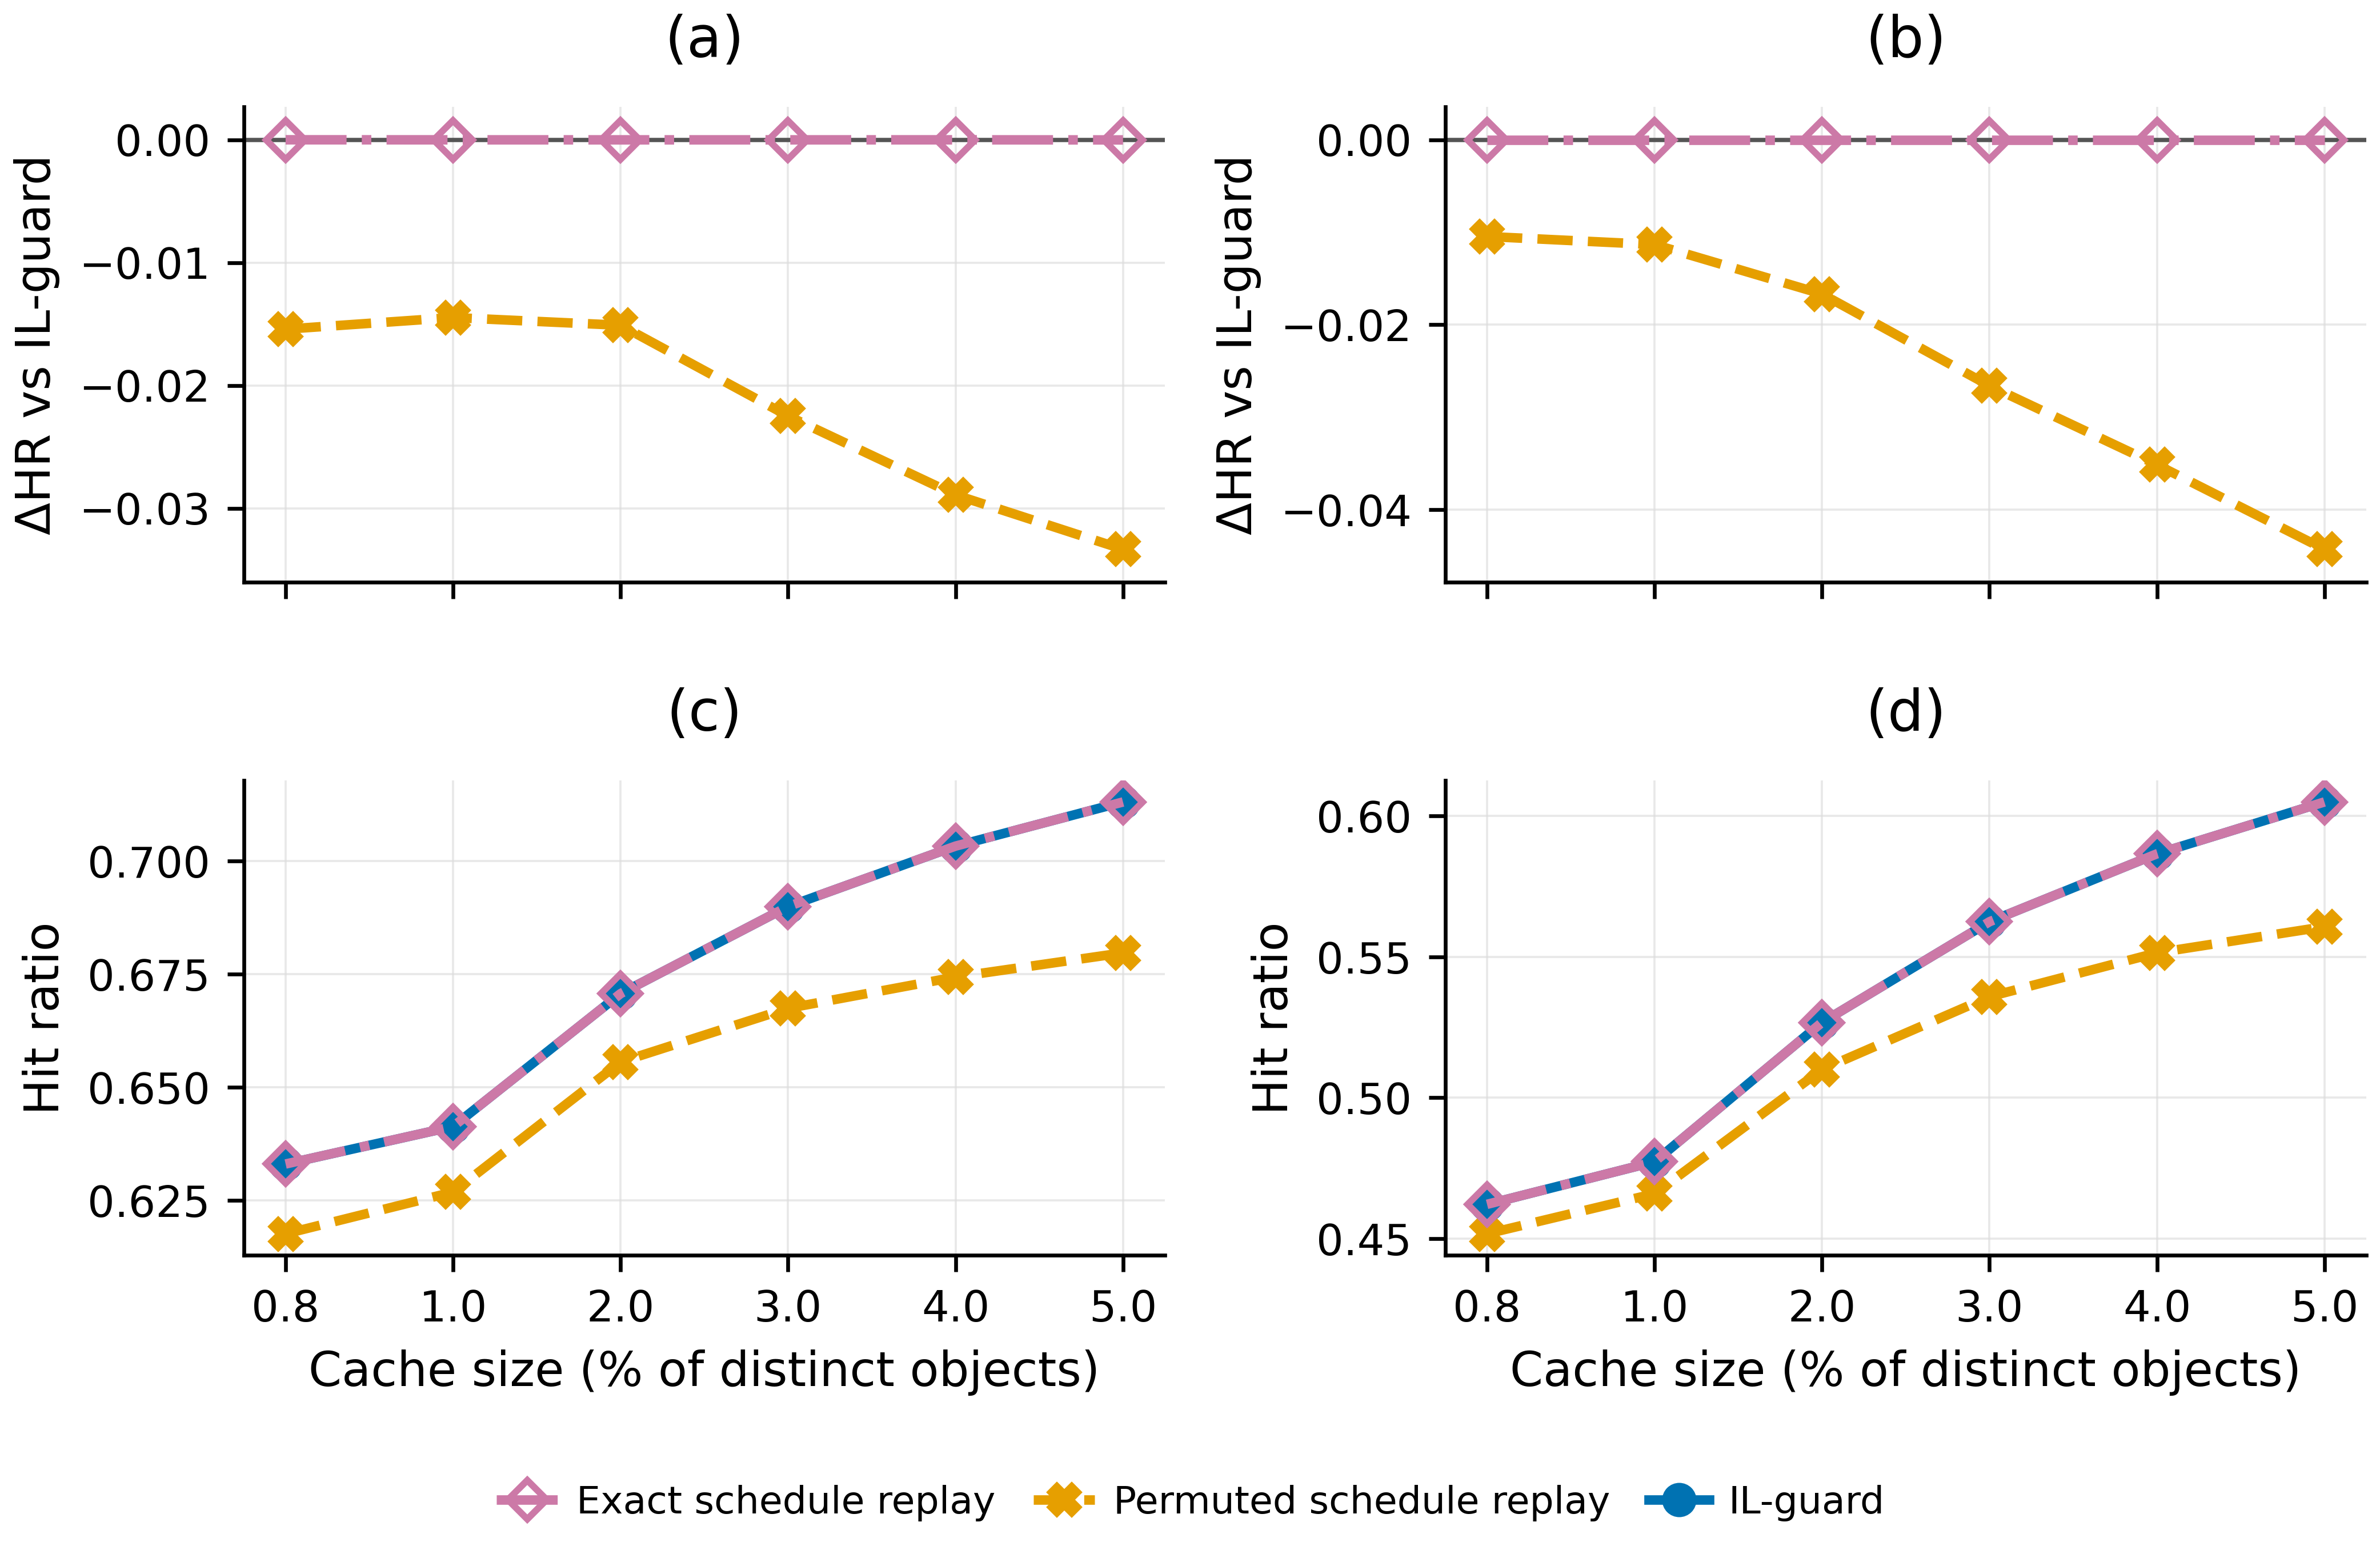

*Score-quality timing attribution under volume-preserving replay. Exact schedule replay reuses the realized slot-level admission budget of IL-guard, whereas permuted schedule replay preserves selected-admission volume but removes slot alignment. The supported claim is timing refinement, not direct HR improvement over the precision-only controller.*

In [12]:
fig_name = "Fig6_score_quality_timing_attribution_paper"
fig, axes = plt.subplots(2, 2, figsize=(DOUBLE_COL_WIDTH, 5.0), sharex=True)
replay_variants = ["precision_only_budget_replay_cap020", "precision_only_budget_replay_permuted_cap020"]
raw_variants = ["full_cap020", "precision_only_budget_replay_cap020", "precision_only_budget_replay_permuted_cap020"]
for col, dataset in enumerate(DATASETS):
    ax_delta = axes[0, col]
    ax_raw = axes[1, col]
    delta_values = []
    hr_values = []
    for variant in replay_variants:
        sub = sort_by_cache(df_budget[(df_budget["dataset"] == dataset) & (df_budget["variant"] == variant)])
        label = label_variant(variant)
        style = method_style(label)
        ax_delta.plot(cache_x_positions(sub["capacity_percent"]), sub["delta_hr_vs_full_cap020"], label=label, **style)
        delta_values.extend(sub["delta_hr_vs_full_cap020"].tolist())
    for variant in raw_variants:
        sub = sort_by_cache(df_budget[(df_budget["dataset"] == dataset) & (df_budget["variant"] == variant)])
        label = label_variant(variant)
        style = method_style(label)
        ax_raw.plot(cache_x_positions(sub["capacity_percent"]), sub["hit_ratio"], label=label, **style)
        hr_values.extend(sub["hit_ratio"].tolist())
    ax_delta.axhline(0, color=ZERO_LINE_COLOR, linewidth=0.9)
    set_padded_ylim(ax_delta, delta_values + [0], pad_frac=0.08)
    set_padded_ylim(ax_raw, hr_values, pad_frac=0.05)
    ax_delta.set_ylabel("ΔHR vs IL-guard")
    ax_raw.set_ylabel("Hit ratio")
    apply_cache_axis(ax_raw)
for ax, lab in zip(axes.ravel(), ["(a)", "(b)", "(c)", "(d)"]):
    add_panel_label(ax, lab)
fig.tight_layout(rect=[0, 0.18, 1, 0.96])
add_figure_legend_below(fig, axes, ncol=3, y=0.025, bottom=0.20)
record_figure_color_usage(fig_name, "replay", ["IL-guard", "Exact schedule replay", "Permuted schedule replay"])
paths = save_figure(fig, fig_name)
display_figure(paths["png"])
plt.close(fig)

caption = "Score-quality timing attribution under volume-preserving replay. Exact schedule replay reuses the realized slot-level admission budget of IL-guard, whereas permuted schedule replay preserves selected-admission volume but removes slot alignment. The supported claim is timing refinement, not direct HR improvement over the precision-only controller."
display_caption(caption)
add_caption("figure", fig_name, caption)
record_manifest(fig_name, "figure", paths.values(), [REQUIRED_FILES["cap020_budget_control_summary.csv"]], "Score-quality is supported through full, exact schedule replay, and permuted schedule replay budget-timing controls.", "main_paper", "Renamed paper Fig. 6 places replay timing evidence after effective-precision attribution.")


In [13]:
table_name = "Table_V_score_quality_timing_summary_paper"
budget_variant_order = [
    "full_cap020",
    "precision_only_cap020",
    "precision_only_budget_replay_cap020",
    "precision_only_budget_replay_permuted_cap020",
    "precision_only_budget_matched_uniform_cap020",
    "precision_only_budget_matched_random_cap020",
]
table_rows = []
for dataset in DATASETS:
    for variant in budget_variant_order:
        sub = df_budget[df_budget["dataset"].eq(dataset) & df_budget["variant"].eq(variant)]
        if sub.empty:
            raise ValueError(f"Missing budget-control rows for {DATASET_LABELS[dataset]} / {variant}.")
        table_rows.append({
            "Dataset": DATASET_LABELS[dataset],
            "Variant": label_variant(variant),
            "Avg selected admissions": float(sub["total_selected_admissions"].mean()),
            "Match ratio vs IL-guard": float(sub["selected_match_ratio_vs_full_cap020"].mean()),
            "Avg HR": float(sub["hit_ratio"].mean()),
            "ΔHR vs IL-guard": float(sub["delta_hr_vs_full_cap020"].mean()),
            "Hit-yield / admission": float(sub["hit_yield_per_admission"].mean()),
            "Pollution proxy": float(sub["pollution_ratio"].mean()),
        })
table_v = pd.DataFrame(table_rows)[[
    "Dataset", "Variant", "Avg selected admissions", "Match ratio vs IL-guard", "Avg HR", "ΔHR vs IL-guard", "Hit-yield / admission", "Pollution proxy"
]]
paths = save_table(table_v, table_name)
display(format_table_for_display(table_v, {
    "Avg selected admissions": "{:.1f}",
    "Match ratio vs IL-guard": "{:.3f}",
    "Avg HR": "{:.6f}",
    "ΔHR vs IL-guard": "{:.6f}",
    "Hit-yield / admission": "{:.3f}",
    "Pollution proxy": "{:.3f}",
}))
caption = "Score-quality timing summary. The table reports selected-admission volume, match ratio versus IL-guard, average HR, ΔHR versus IL-guard, hit-yield per admission, and pollution proxy so Fig. 6 can focus on timing behavior."
display_caption(caption)
add_caption("table", table_name, caption)
record_manifest(table_name, "table", [paths["csv"], paths["tex"]], [REQUIRED_FILES["cap020_budget_control_summary.csv"]], "Score-quality budget-control summary including selected-match ratio and admission outcomes.", "main_paper", "Regenerated from cap020 budget-control summaries with the requested columns.")


Dataset,Variant,Avg selected admissions,Match ratio vs IL-guard,Avg HR,ΔHR vs IL-guard,Hit-yield / admission,Pollution proxy
Wikipedia-2007 web,IL-guard,68595.0,1.000,0.675241,0.000000,1.395,0.619
Wikipedia-2007 web,Precision-only,70985.7,1.066,0.675204,-0.000036,1.284,0.625
Wikipedia-2007 web,Exact schedule replay,68595.0,1.000,0.675243,0.000002,1.395,0.619
Wikipedia-2007 web,Permuted schedule replay,68595.0,1.000,0.653623,-0.021618,1.397,0.628
Wikipedia-2007 web,Uniform matched,69476.5,1.023,0.675007,-0.000234,1.351,0.620
Wikipedia-2007 web,Random matched,69363.2,1.019,0.675022,-0.000219,1.361,0.621
Wiki-CDN-2018,IL-guard,103559.2,1.000,0.536710,0.000000,0.766,0.572
Wiki-CDN-2018,Precision-only,104953.3,1.032,0.536762,0.000053,0.741,0.573
Wiki-CDN-2018,Exact schedule replay,103559.2,1.000,0.536710,0.000000,0.766,0.572
Wiki-CDN-2018,Permuted schedule replay,103559.2,1.000,0.512623,-0.024087,0.793,0.573


*Score-quality timing summary. The table reports selected-admission volume, match ratio versus IL-guard, average HR, ΔHR versus IL-guard, hit-yield per admission, and pollution proxy so Fig. 6 can focus on timing behavior.*

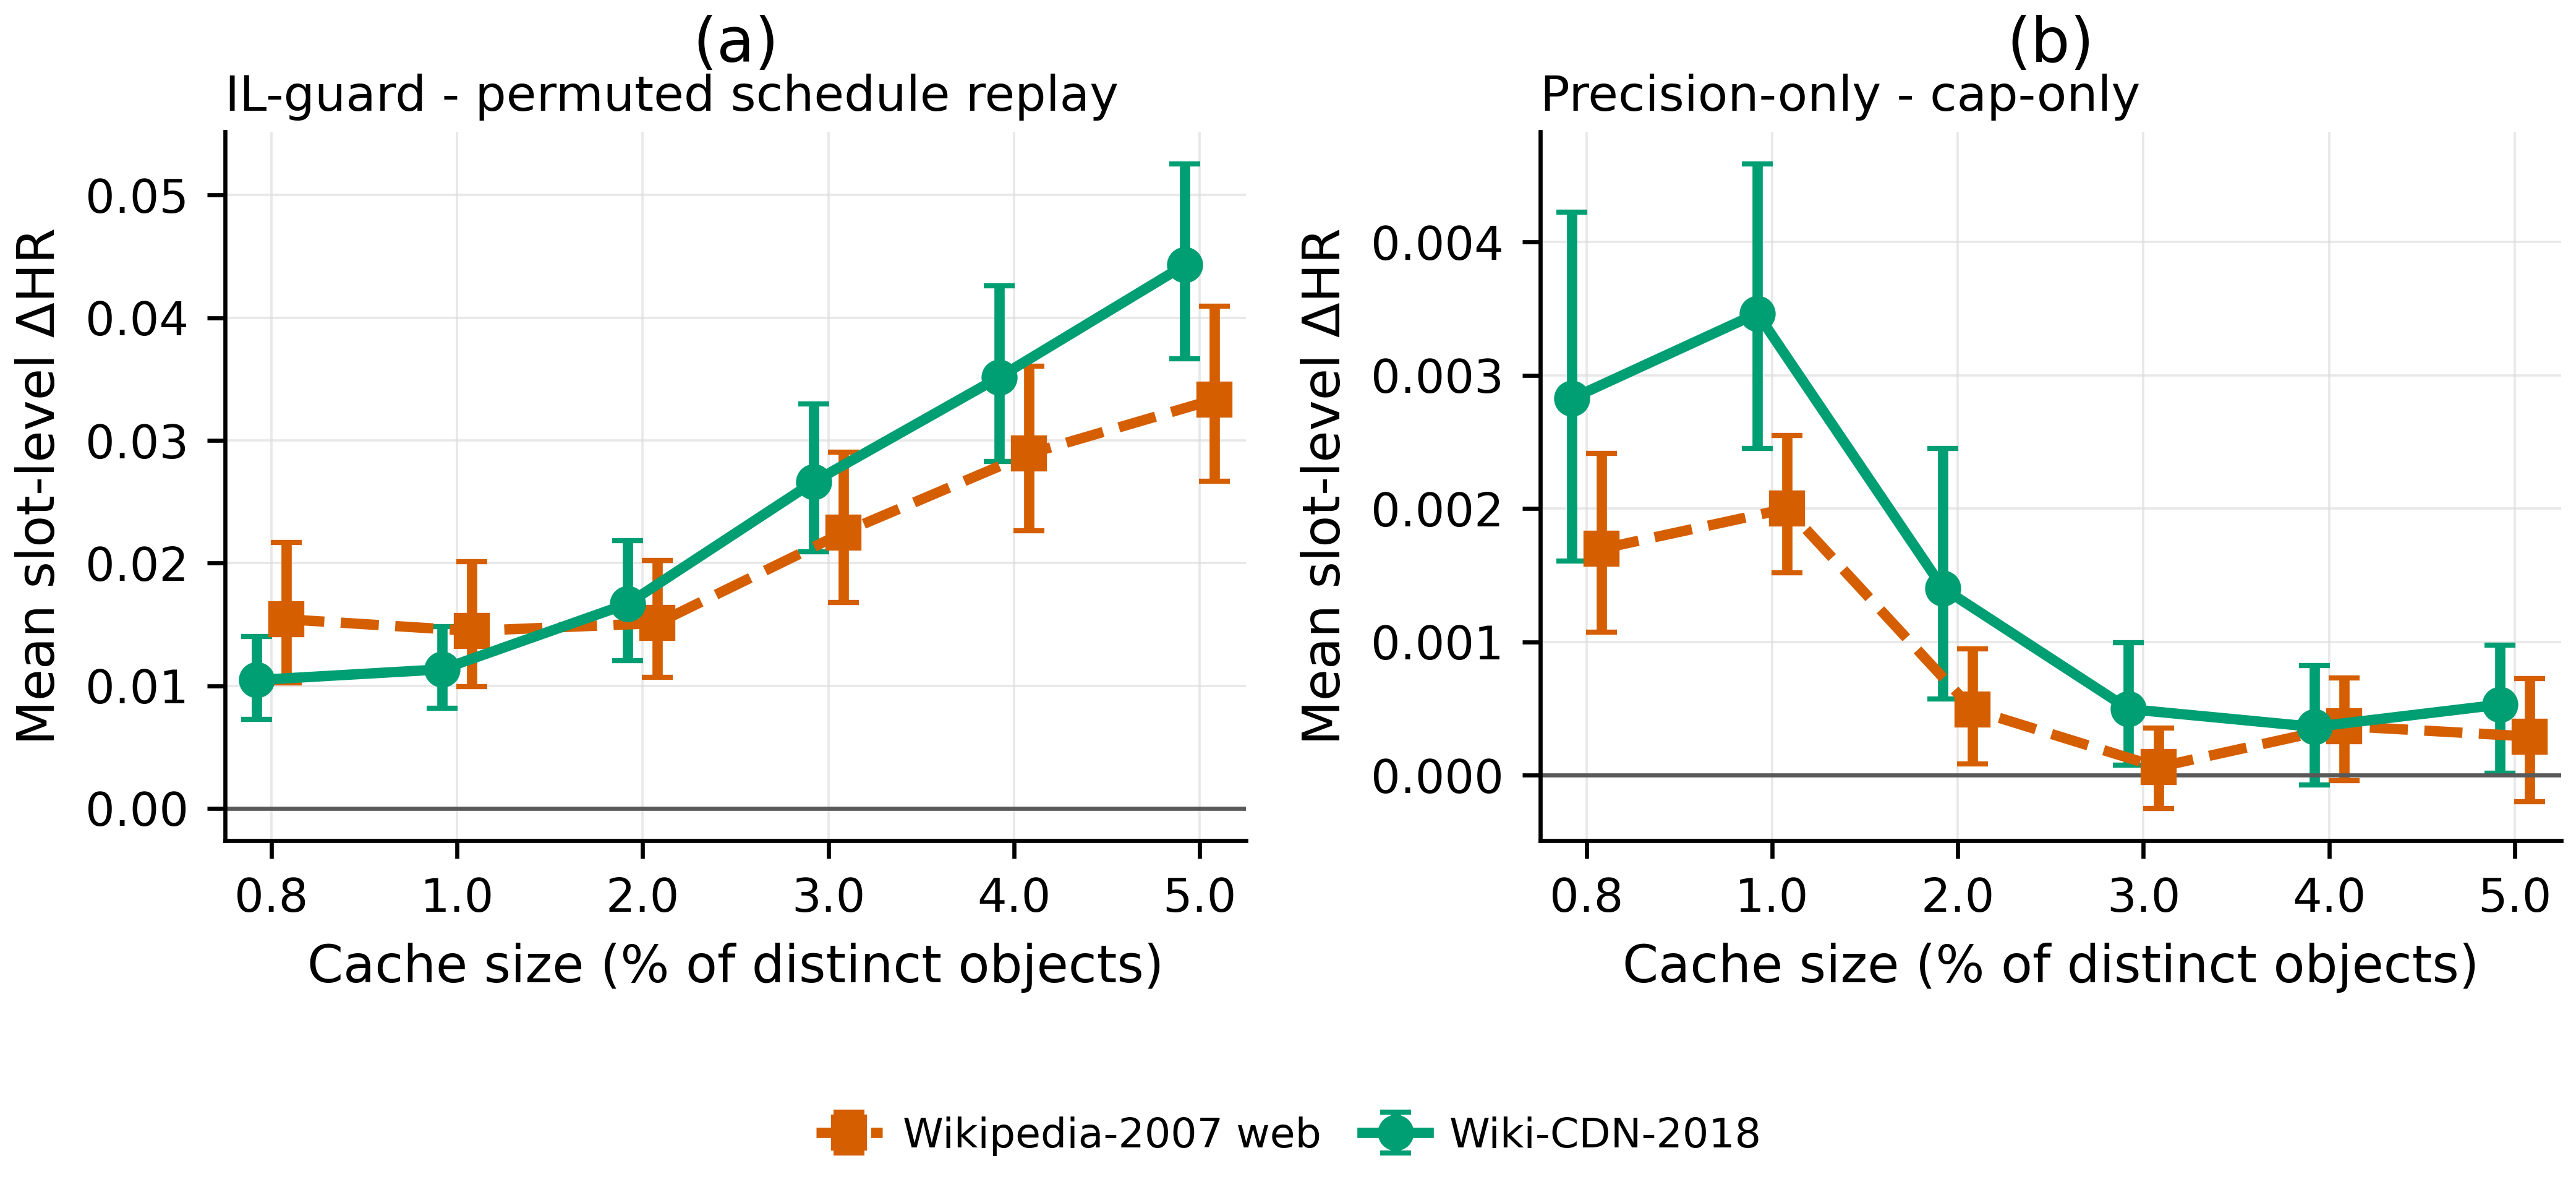

*Paired slot-level bootstrap support. Panel (a) supports the score-quality timing comparison from the replay analysis, and panel (b) supports the effective-precision comparison against cap-only. Error bars show 95% bootstrap confidence intervals; this figure is supporting evidence after the mechanism figures, not the primary attribution by itself.*

In [14]:
fig_name = "FigS1_paired_bootstrap_support_paper"
metric = "slot_hit_ratio"
comparisons = [
    ("full_cap020", "precision_only_budget_replay_permuted_cap020", "IL-guard - permuted schedule replay"),
    ("precision_only_cap020", "cap_only_cap020", "Precision-only - cap-only"),
]
fig, axes = plt.subplots(1, 2, figsize=(DOUBLE_COL_WIDTH, 3.65), sharey=False)
offsets = {"wiki2018": -0.08, "wikipedia_september_2007": 0.08}
for ax, (variant_a, variant_b, title), panel in zip(axes, comparisons, ["(a)", "(b)"]):
    for dataset in DATASETS:
        sub = sort_by_cache(df_ci[(df_ci["dataset"] == dataset) & (df_ci["metric"] == metric) & (df_ci["variant_a"] == variant_a) & (df_ci["variant_b"] == variant_b)])
        y = sub["mean_delta"].to_numpy()
        yerr = np.vstack([y - sub["bootstrap_ci95_low"].to_numpy(), sub["bootstrap_ci95_high"].to_numpy() - y])
        style = DATASET_STYLE[dataset]
        x = cache_x_positions(sub["capacity_percent"]) + offsets[dataset]
        ax.errorbar(x, y, yerr=yerr, capsize=3, label=DATASET_LABELS[dataset], color=style["color"], marker=style["marker"], linestyle=style["linestyle"], linewidth=style["linewidth"], markersize=style["markersize"])
    ax.axhline(0, color="0.35", linewidth=0.8)
    ax.set_title(title, loc="left", pad=4, fontsize=9.5)
    ax.set_ylabel("Mean slot-level ΔHR")
    apply_cache_axis(ax)
    add_panel_label(ax, panel)
fig.tight_layout(rect=[0, 0.32, 1, 0.93])
add_figure_legend_below(fig, axes, ncol=2, y=0.0, bottom=0.26)
paths = save_figure(fig, fig_name)
display_figure(paths["png"])
plt.close(fig)

caption = "Paired slot-level bootstrap support. Panel (a) supports the score-quality timing comparison from the replay analysis, and panel (b) supports the effective-precision comparison against cap-only. Error bars show 95% bootstrap confidence intervals; this figure is supporting evidence after the mechanism figures, not the primary attribution by itself."
display_caption(caption)
add_caption("figure", fig_name, caption)
record_manifest(fig_name, "figure", paths.values(), [REQUIRED_FILES["paired_slot_bootstrap_ci.csv"]], "Bootstrap CI evidence for score-quality timing and effective-precision feedback comparisons.", "appendix", "Appendix Fig. S1; supporting evidence, not a main-paper figure.")


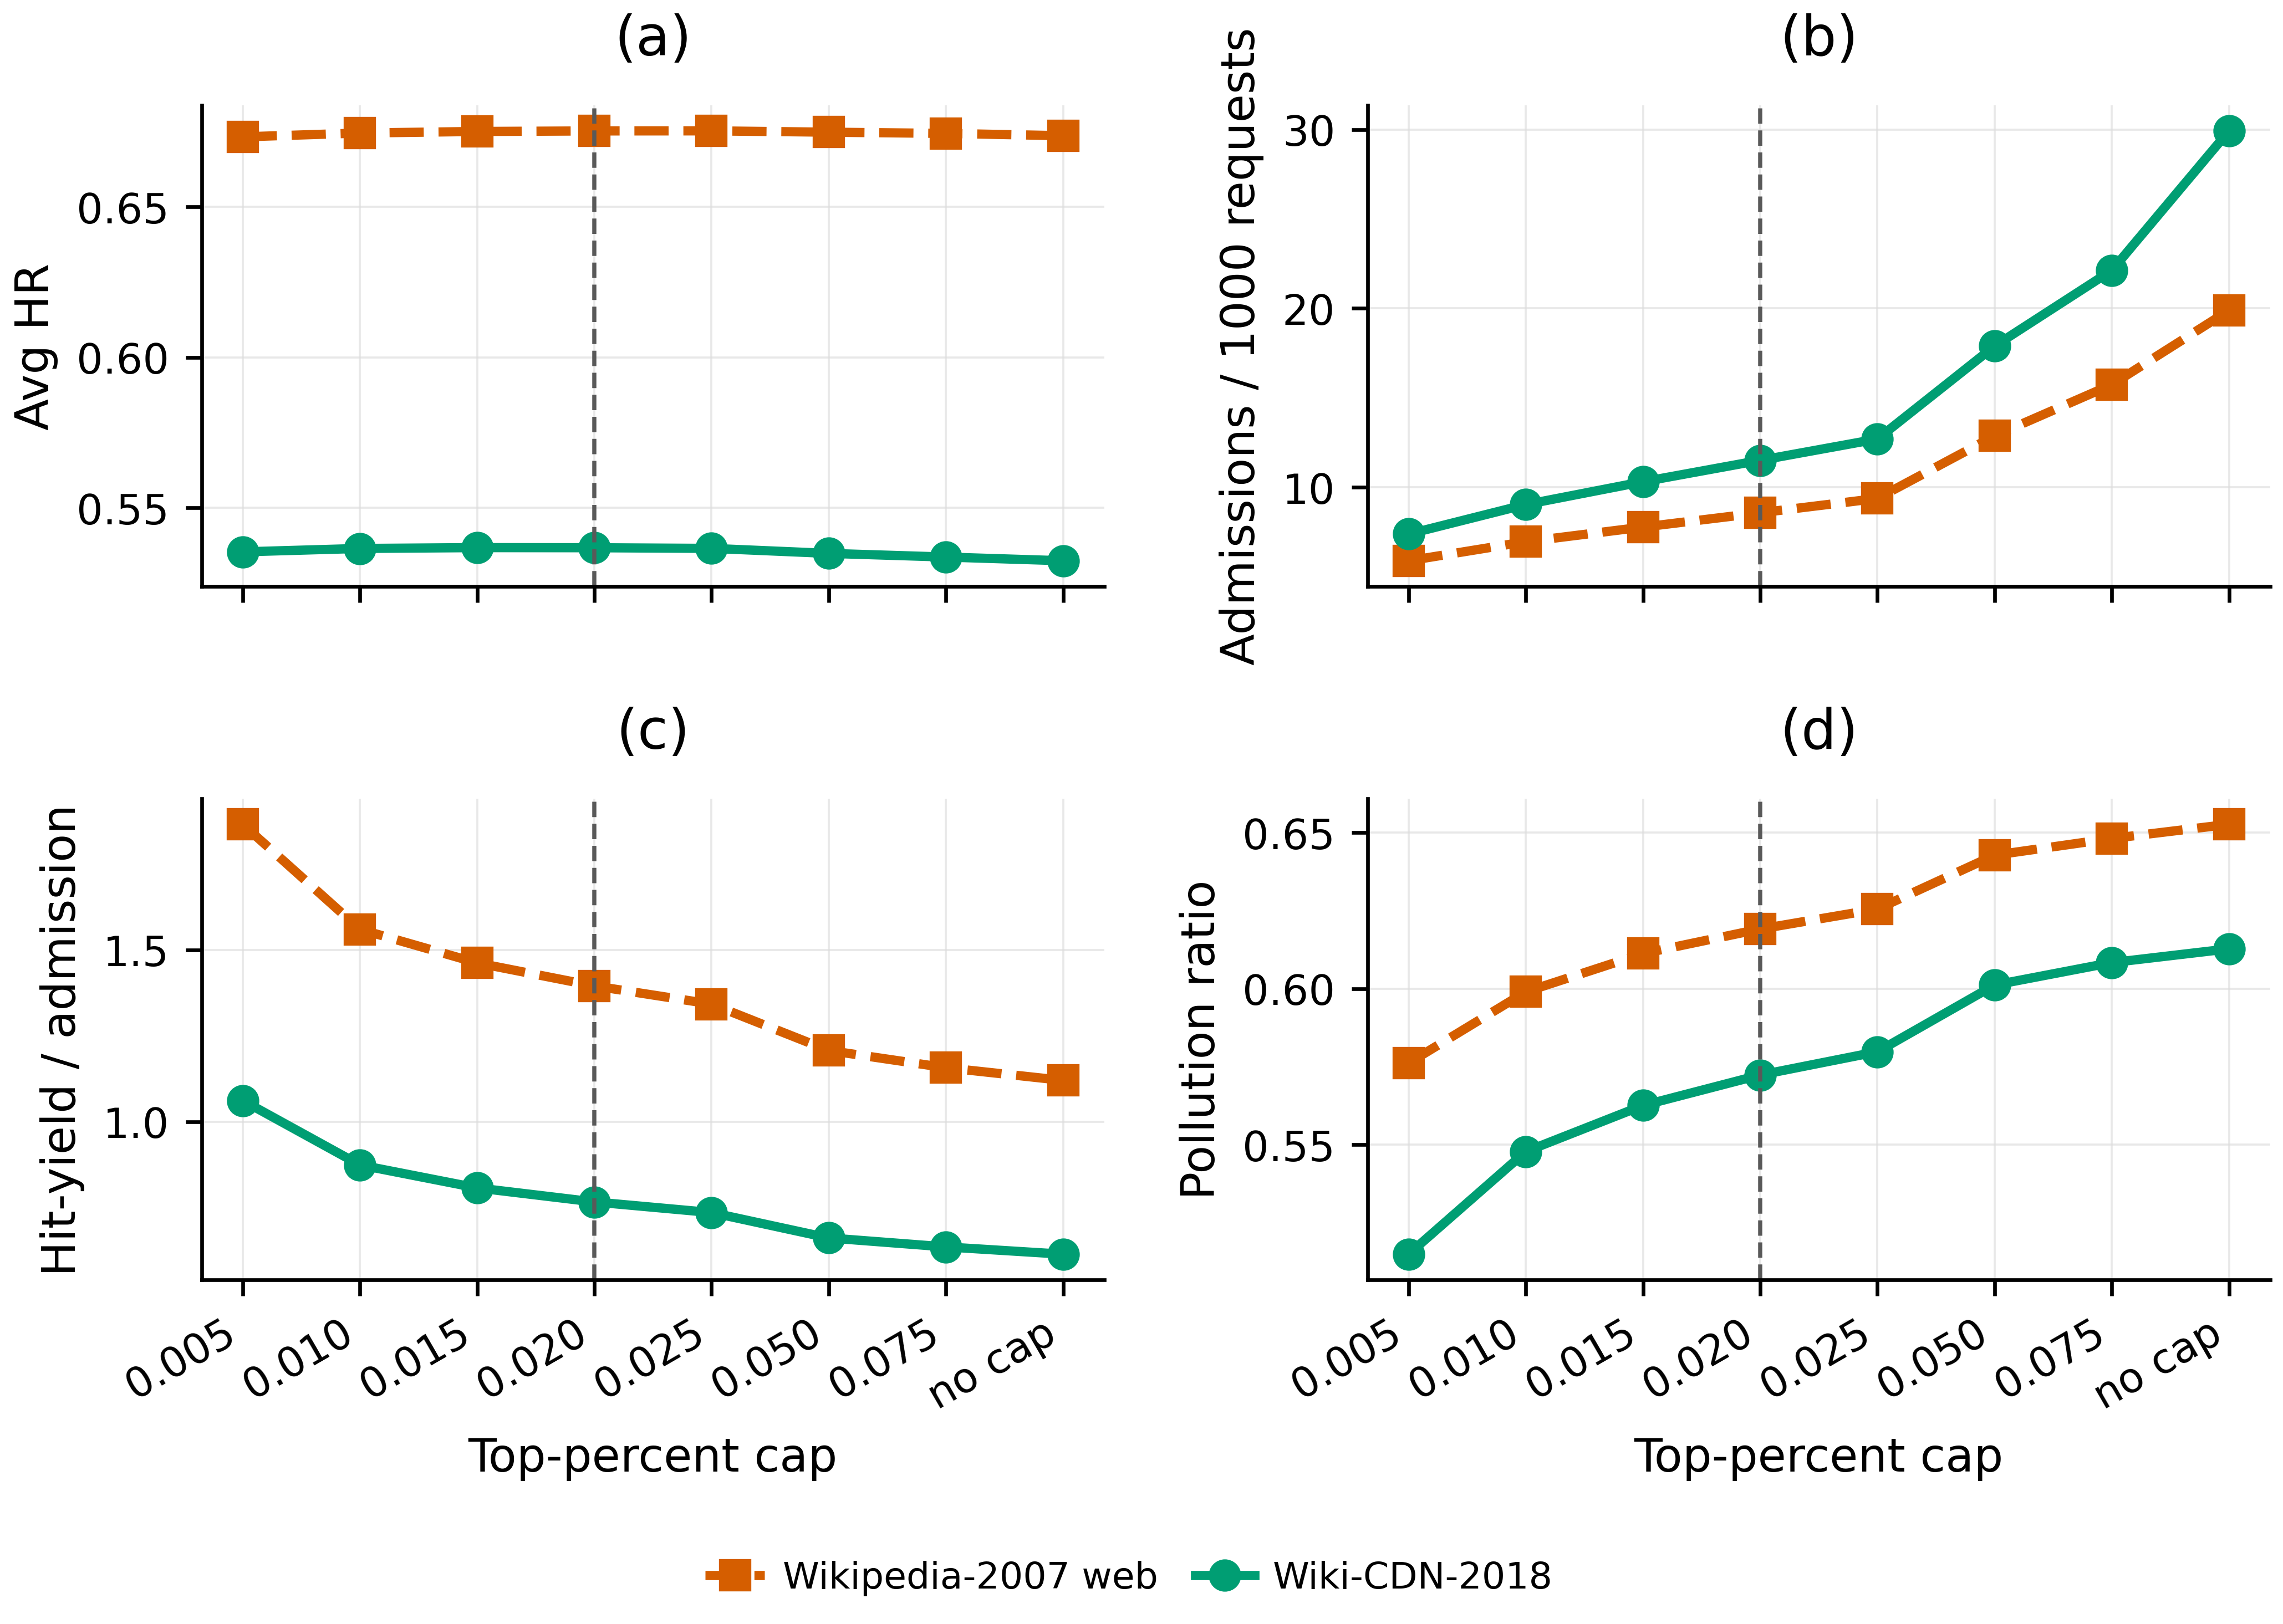

*Cap-sensitivity analysis for selecting the final top-percent cap. Cap 0.020 is marked as the final setting and is interpreted as a robust near-best operating point across workloads, not as a globally optimal cap. For Wiki-CDN-2018 it serves as a unified robust cap; pressure reduction is not asserted there relative to the best-HR cap.*

In [15]:
fig_name = "FigS2_cap_sensitivity_selection_paper"
if cap_sensitivity_available:
    cap_plot = df_cap_full.copy()
    cap_plot["cap_label_str"] = cap_plot["cap_label"].astype(str)
    x_positions = {label: idx for idx, label in enumerate(CAP_LABEL_ORDER)}
    present_labels = [label for label in CAP_LABEL_ORDER if label in set(cap_plot["cap_label_str"])]
    fig, axes = plt.subplots(2, 2, figsize=(DOUBLE_COL_WIDTH, 5.25), sharex=True)
    metrics = [
        ("avg_hit_ratio", "Avg HR", "(a)"),
        ("avg_admissions_per_1000_requests", "Admissions / 1000 requests", "(b)"),
        ("avg_hit_yield_per_admission", "Hit-yield / admission", "(c)"),
        ("avg_pollution_ratio", "Pollution ratio", "(d)"),
    ]
    for ax, (metric_col, y_label, panel) in zip(axes.ravel(), metrics):
        metric_values = []
        for dataset in DATASETS:
            sub = cap_plot[cap_plot["dataset"] == dataset].sort_values("cap_label")
            xs = [x_positions[str(label)] for label in sub["cap_label"]]
            style = DATASET_STYLE[dataset]
            ax.plot(xs, sub[metric_col], label=DATASET_LABELS[dataset], **style)
            metric_values.extend(sub[metric_col].tolist())
        final_x = x_positions["0.020"]
        ax.axvline(final_x, color="0.35", linestyle="--", linewidth=0.9)
        set_padded_ylim(ax, metric_values, pad_frac=0.06)
        if panel == "(a)":
            ylo, yhi = ax.get_ylim()
            # ax.text(final_x + 0.10, yhi - 0.10 * (yhi - ylo), "final cap = 0.02", fontsize=7.5, rotation=90, va="top", color="0.25")
        ax.set_ylabel(y_label)
        add_panel_label(ax, panel)
    for ax in axes[1, :]:
        ax.set_xticks([x_positions[label] for label in present_labels])
        ax.set_xticklabels([CAP_DISPLAY_LABELS[label] for label in present_labels], rotation=30, ha="right")
        ax.set_xlabel("Top-percent cap")
    fig.tight_layout(rect=[0, 0.18, 1, 0.96])
    add_global_legend(fig, axes, ncol=2, y=0.0)
    paths = save_figure(fig, fig_name)
    display_figure(paths["png"])
    plt.close(fig)
    caption = f"Cap-sensitivity analysis for selecting the final top-percent cap. Cap 0.020 is marked as the final setting and is interpreted as a robust near-best operating point across workloads, not as a globally optimal cap. For {DATASET_LABELS['wiki2018']} it serves as a unified robust cap; pressure reduction is not asserted there relative to the best-HR cap."
    display_caption(caption)
    add_caption("figure", fig_name, caption)
    record_manifest(fig_name, "figure", paths.values(), cap_sensitivity_source_paths, "Cap 0.020 is justified through cap-sensitivity evidence only.", "appendix", "Appendix Fig. S2; cap sensitivity is supporting evidence, not main Fig. 7.")
else:
    display(Markdown(f"**Appendix cap-sensitivity figure not generated.** {cap_sensitivity_warning}"))


In [16]:
table_name = "Table_S4_cap_selection_summary_paper"
if not cap_sensitivity_available:
    add_validation("Cap-selection appendix table", "SKIPPED", cap_sensitivity_warning)
    display(Markdown(f"**Table S4 not generated.** {cap_sensitivity_warning}"))
else:
    rows = []
    for dataset in DATASETS:
        dset = df_cap_full[df_cap_full["dataset"] == dataset].copy()
        dset = dset.dropna(subset=["avg_hit_ratio"])
        best = dset.loc[dset["avg_hit_ratio"].idxmax()]
        cap020 = dset[dset["variant"] == "full_cap020"].iloc[0]
        rows.append({
            "Dataset": DATASET_LABELS[dataset],
            "Final cap": "0.020",
            "Best tested cap by HR": str(best["cap_label"]),
            "Cap020 HR": float(cap020["avg_hit_ratio"]),
            "Best HR": float(best["avg_hit_ratio"]),
            "ΔHR vs best": float(cap020["avg_hit_ratio"] - best["avg_hit_ratio"]),
            "Admissions / 1000 requests at cap020": float(cap020["avg_admissions_per_1000_requests"]),
            "Hit-yield at cap020": float(cap020["avg_hit_yield_per_admission"]),
            "Pollution proxy at cap020": float(cap020["avg_pollution_ratio"]),
        })
    table_s4 = pd.DataFrame(rows)
    paths = save_table(table_s4, table_name)
    table_s4_display = table_s4.copy()
    display(format_table_for_display(table_s4_display, {
        "Cap020 HR": "{:.6f}",
        "Best HR": "{:.6f}",
        "ΔHR vs best": "{:.6f}",
        "Admissions / 1000 requests at cap020": "{:.3f}",
        "Hit-yield at cap020": "{:.3f}",
        "Pollution proxy at cap020": "{:.3f}",
    }))
    caption = f"Cap-selection summary. Cap 0.020 is retained as a robust near-best final operating point; the table does not claim global optimality. The {DATASET_LABELS['wiki2018']} decision is a unified robust-cap decision, while the pressure-reduction decision applies only where shown by the table."
    display_caption(caption)
    add_caption("table", table_name, caption)
    record_manifest(table_name, "table", [paths["csv"], paths["tex"]], cap_sensitivity_source_paths, "Cap020 is supported as a robust near-best operating point through cap-sensitivity results.", "appendix", "Appendix Table S4 generated from cap-sensitivity summaries.")


Dataset,Final cap,Best tested cap by HR,Cap020 HR,Best HR,ΔHR vs best,Admissions / 1000 requests at cap020,Hit-yield at cap020,Pollution proxy at cap020
Wikipedia-2007 web,0.020,0.025,0.675241,0.675266,-0.000026,8.574,1.395,0.619
Wiki-CDN-2018,0.020,0.015,0.536710,0.536750,-0.000041,11.507,0.766,0.572


*Cap-selection summary. Cap 0.020 is retained as a robust near-best final operating point; the table does not claim global optimality. The Wiki-CDN-2018 decision is a unified robust-cap decision, while the pressure-reduction decision applies only where shown by the table.*

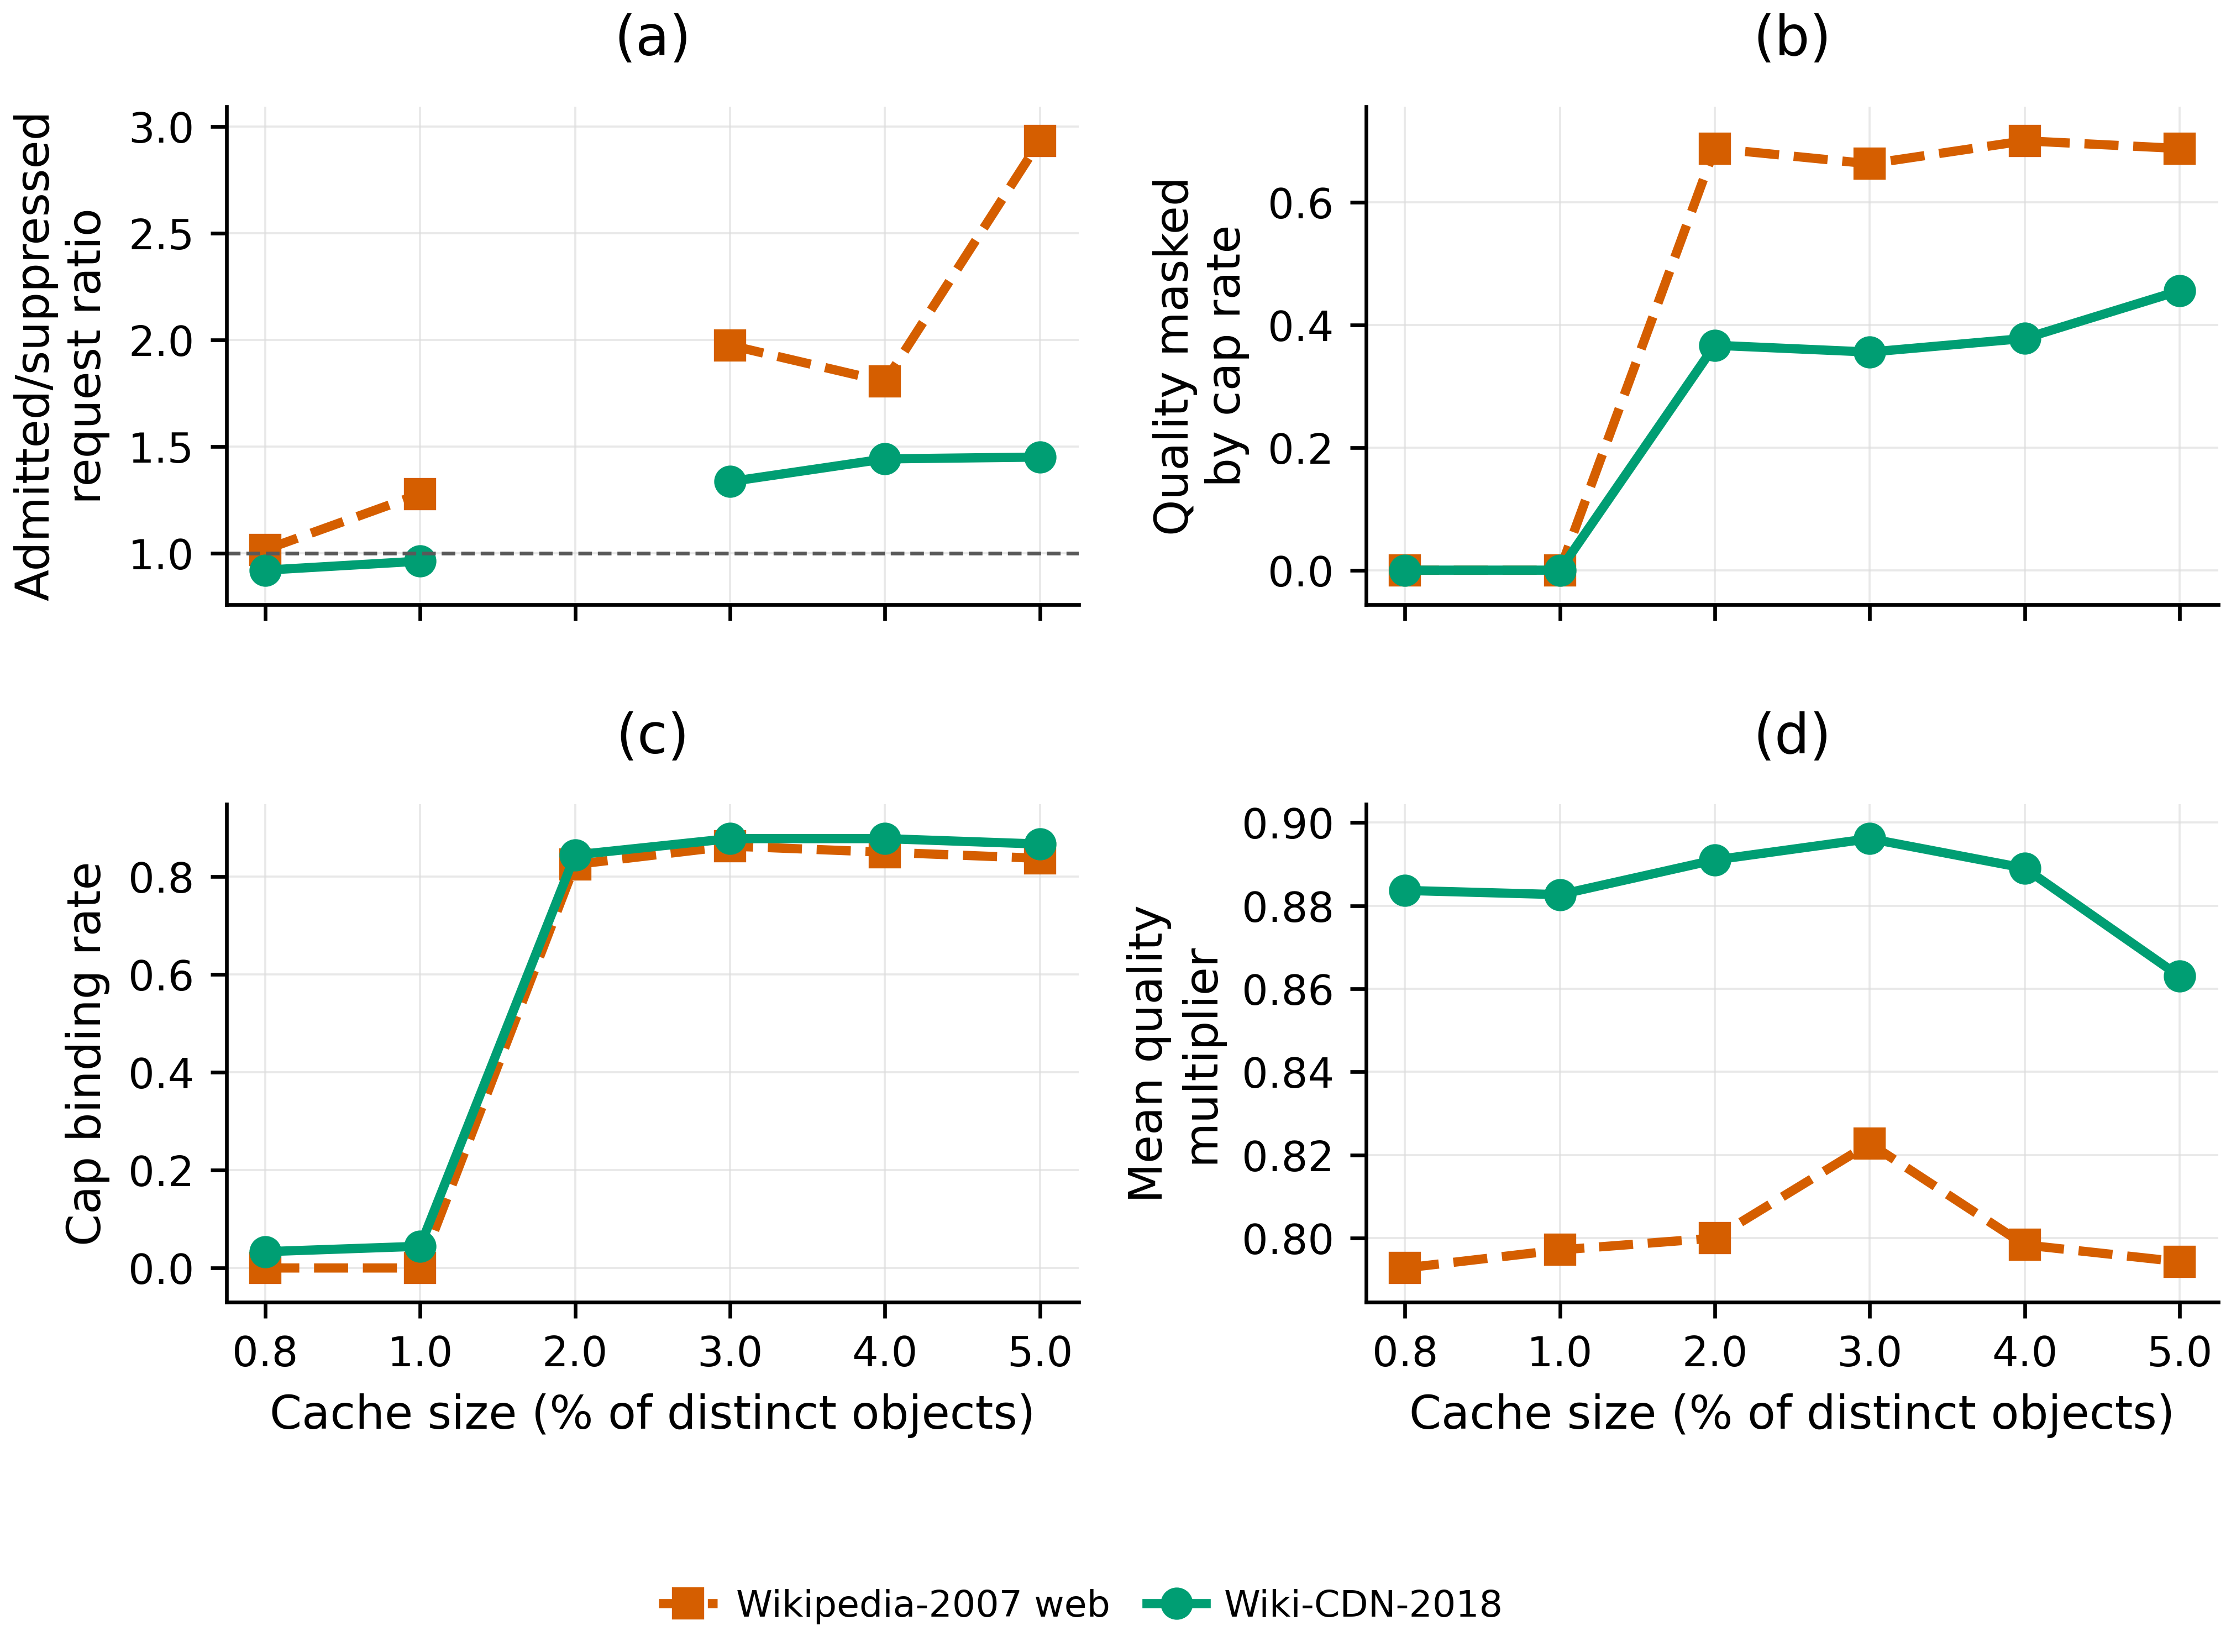

*Selective suppression diagnostics for score-quality. These appendix diagnostics show where score-quality actions are observable and where they are masked by the tight cap; they are not used as the main evidence for average-HR gains.*

In [17]:
fig_name = "FigS3_selective_suppression_diagnostics_paper"
full_supp = df_suppression[df_suppression["variant"] == "full_cap020"].copy()
fig, axes = plt.subplots(2, 2, figsize=(DOUBLE_COL_WIDTH, 5.35), sharex=True)
metrics = [
    ("quality_admitted_to_suppressed_request_ratio", "Admitted/suppressed\nrequest ratio", "(a)"),
    ("quality_masked_by_cap_rate", "Quality masked\nby cap rate", "(b)"),
    ("top_percent_cap_binding_rate", "Cap binding rate", "(c)"),
    ("mean_score_quality_mult", "Mean quality\nmultiplier", "(d)"),
]
for ax, (metric_col, y_label, panel) in zip(axes.ravel(), metrics):
    values = []
    for dataset in DATASETS:
        sub = sort_by_cache(full_supp[full_supp["dataset"] == dataset])
        style = DATASET_STYLE[dataset]
        ax.plot(cache_x_positions(sub["capacity_percent"]), sub[metric_col], label=DATASET_LABELS[dataset], **style)
        values.extend(sub[metric_col].tolist())
    if metric_col == "quality_admitted_to_suppressed_request_ratio":
        ax.axhline(1.0, color="0.35", linewidth=0.8, linestyle="--")
    set_padded_ylim(ax, values, pad_frac=0.08)
    ax.set_ylabel(y_label)
    add_panel_label(ax, panel)
for ax in axes[1, :]:
    apply_cache_axis(ax)
fig.tight_layout(rect=[0.03, 0.20, 1, 0.96])
add_figure_legend_below(fig, axes, ncol=2, y=0.0, bottom=0.20)
paths = save_figure(fig, fig_name)
display_figure(paths["png"])
plt.close(fig)

caption = "Selective suppression diagnostics for score-quality. These appendix diagnostics show where score-quality actions are observable and where they are masked by the tight cap; they are not used as the main evidence for average-HR gains."
display_caption(caption)
add_caption("figure", fig_name, caption)
record_manifest(fig_name, "figure", paths.values(), [REQUIRED_FILES["score_quality_suppression_summary.csv"]], "Appendix diagnostics for score-quality action visibility and masking.", "appendix", "Appendix Fig. S3 keeps selective suppression out of the main claim chain.")


In [18]:
table_name = "Table_S1_selective_suppression_diagnostics_paper"
paths = save_existing_table("Table_S1_selective_suppression_diagnostics_v4", table_name)
table_s1 = display_existing_table(paths["csv"])
caption = "Selective suppression diagnostics for score-quality under cap 0.020. These diagnostics are appendix-only and support interpretation of timing behavior and cap masking."
display_caption(caption)
add_caption("table", table_name, caption)
record_manifest(table_name, "table", [paths["csv"], paths["tex"]], [paths["source_csv"], paths["source_tex"]], "Appendix selective suppression diagnostic table.", "appendix", "Copied from v4 Table S1.")

table_name = "Table_S2_precision_correlation_diagnostics_paper"
paths = save_existing_table("Table_S2_precision_correlation_diagnostics_v4", table_name)
table_s2 = display_existing_table(paths["csv"])
caption = "Precision correlation diagnostics for the effective-precision signal under cap 0.020. These appendix diagnostics are secondary checks and are not used as standalone proof of HR gains."
display_caption(caption)
add_caption("table", table_name, caption)
record_manifest(table_name, "table", [paths["csv"], paths["tex"]], [paths["source_csv"], paths["source_tex"]], "Appendix precision-feedback correlation diagnostics.", "appendix", "Copied from v4 Table S2.")


Dataset,Cache %,Quality action rate,Suppression rate,Admitted/suppressed next-slot request ratio,Quality masked by cap,Cap binding,Mean quality multiplier
Wiki-CDN-2018,0.800000,0.411000,0.433000,0.920000,0.000000,0.033000,0.884000
Wiki-CDN-2018,1.000000,0.411000,0.433000,0.962000,0.000000,0.044000,0.883000
Wiki-CDN-2018,2.000000,0.089000,0.456000,n/a,0.367000,0.844000,0.891000
Wiki-CDN-2018,3.000000,0.022000,0.378000,1.335000,0.356000,0.878000,0.896000
Wiki-CDN-2018,4.000000,0.022000,0.400000,1.442000,0.378000,0.878000,0.889000
Wiki-CDN-2018,5.000000,0.022000,0.478000,1.451000,0.456000,0.867000,0.863000
Wikipedia-2007 web,0.800000,0.725000,0.762000,1.016000,0.000000,0.000000,0.793000
Wikipedia-2007 web,1.000000,0.662000,0.738000,1.278000,0.000000,0.000000,0.797000
Wikipedia-2007 web,2.000000,0.037000,0.725000,n/a,0.688000,0.825000,0.800000
Wikipedia-2007 web,3.000000,0.013000,0.675000,1.975000,0.662000,0.863000,0.823000


*Selective suppression diagnostics for score-quality under cap 0.020. These diagnostics are appendix-only and support interpretation of timing behavior and cap masking.*

Dataset,Variant,"Mean corr(precision_eff, next-slot hit-yield)","Mean corr(precision_eff, next-slot admission precision)","Mean corr(precision_eff, pollution proxy)"
Wiki-CDN-2018,Precision-only,0.823000,0.574000,-0.722000
Wiki-CDN-2018,IL-guard,0.825000,0.575000,-0.722000
Wikipedia-2007 web,Precision-only,0.832000,0.805000,-0.797000
Wikipedia-2007 web,IL-guard,0.833000,0.808000,-0.793000


*Precision correlation diagnostics for the effective-precision signal under cap 0.020. These appendix diagnostics are secondary checks and are not used as standalone proof of HR gains.*

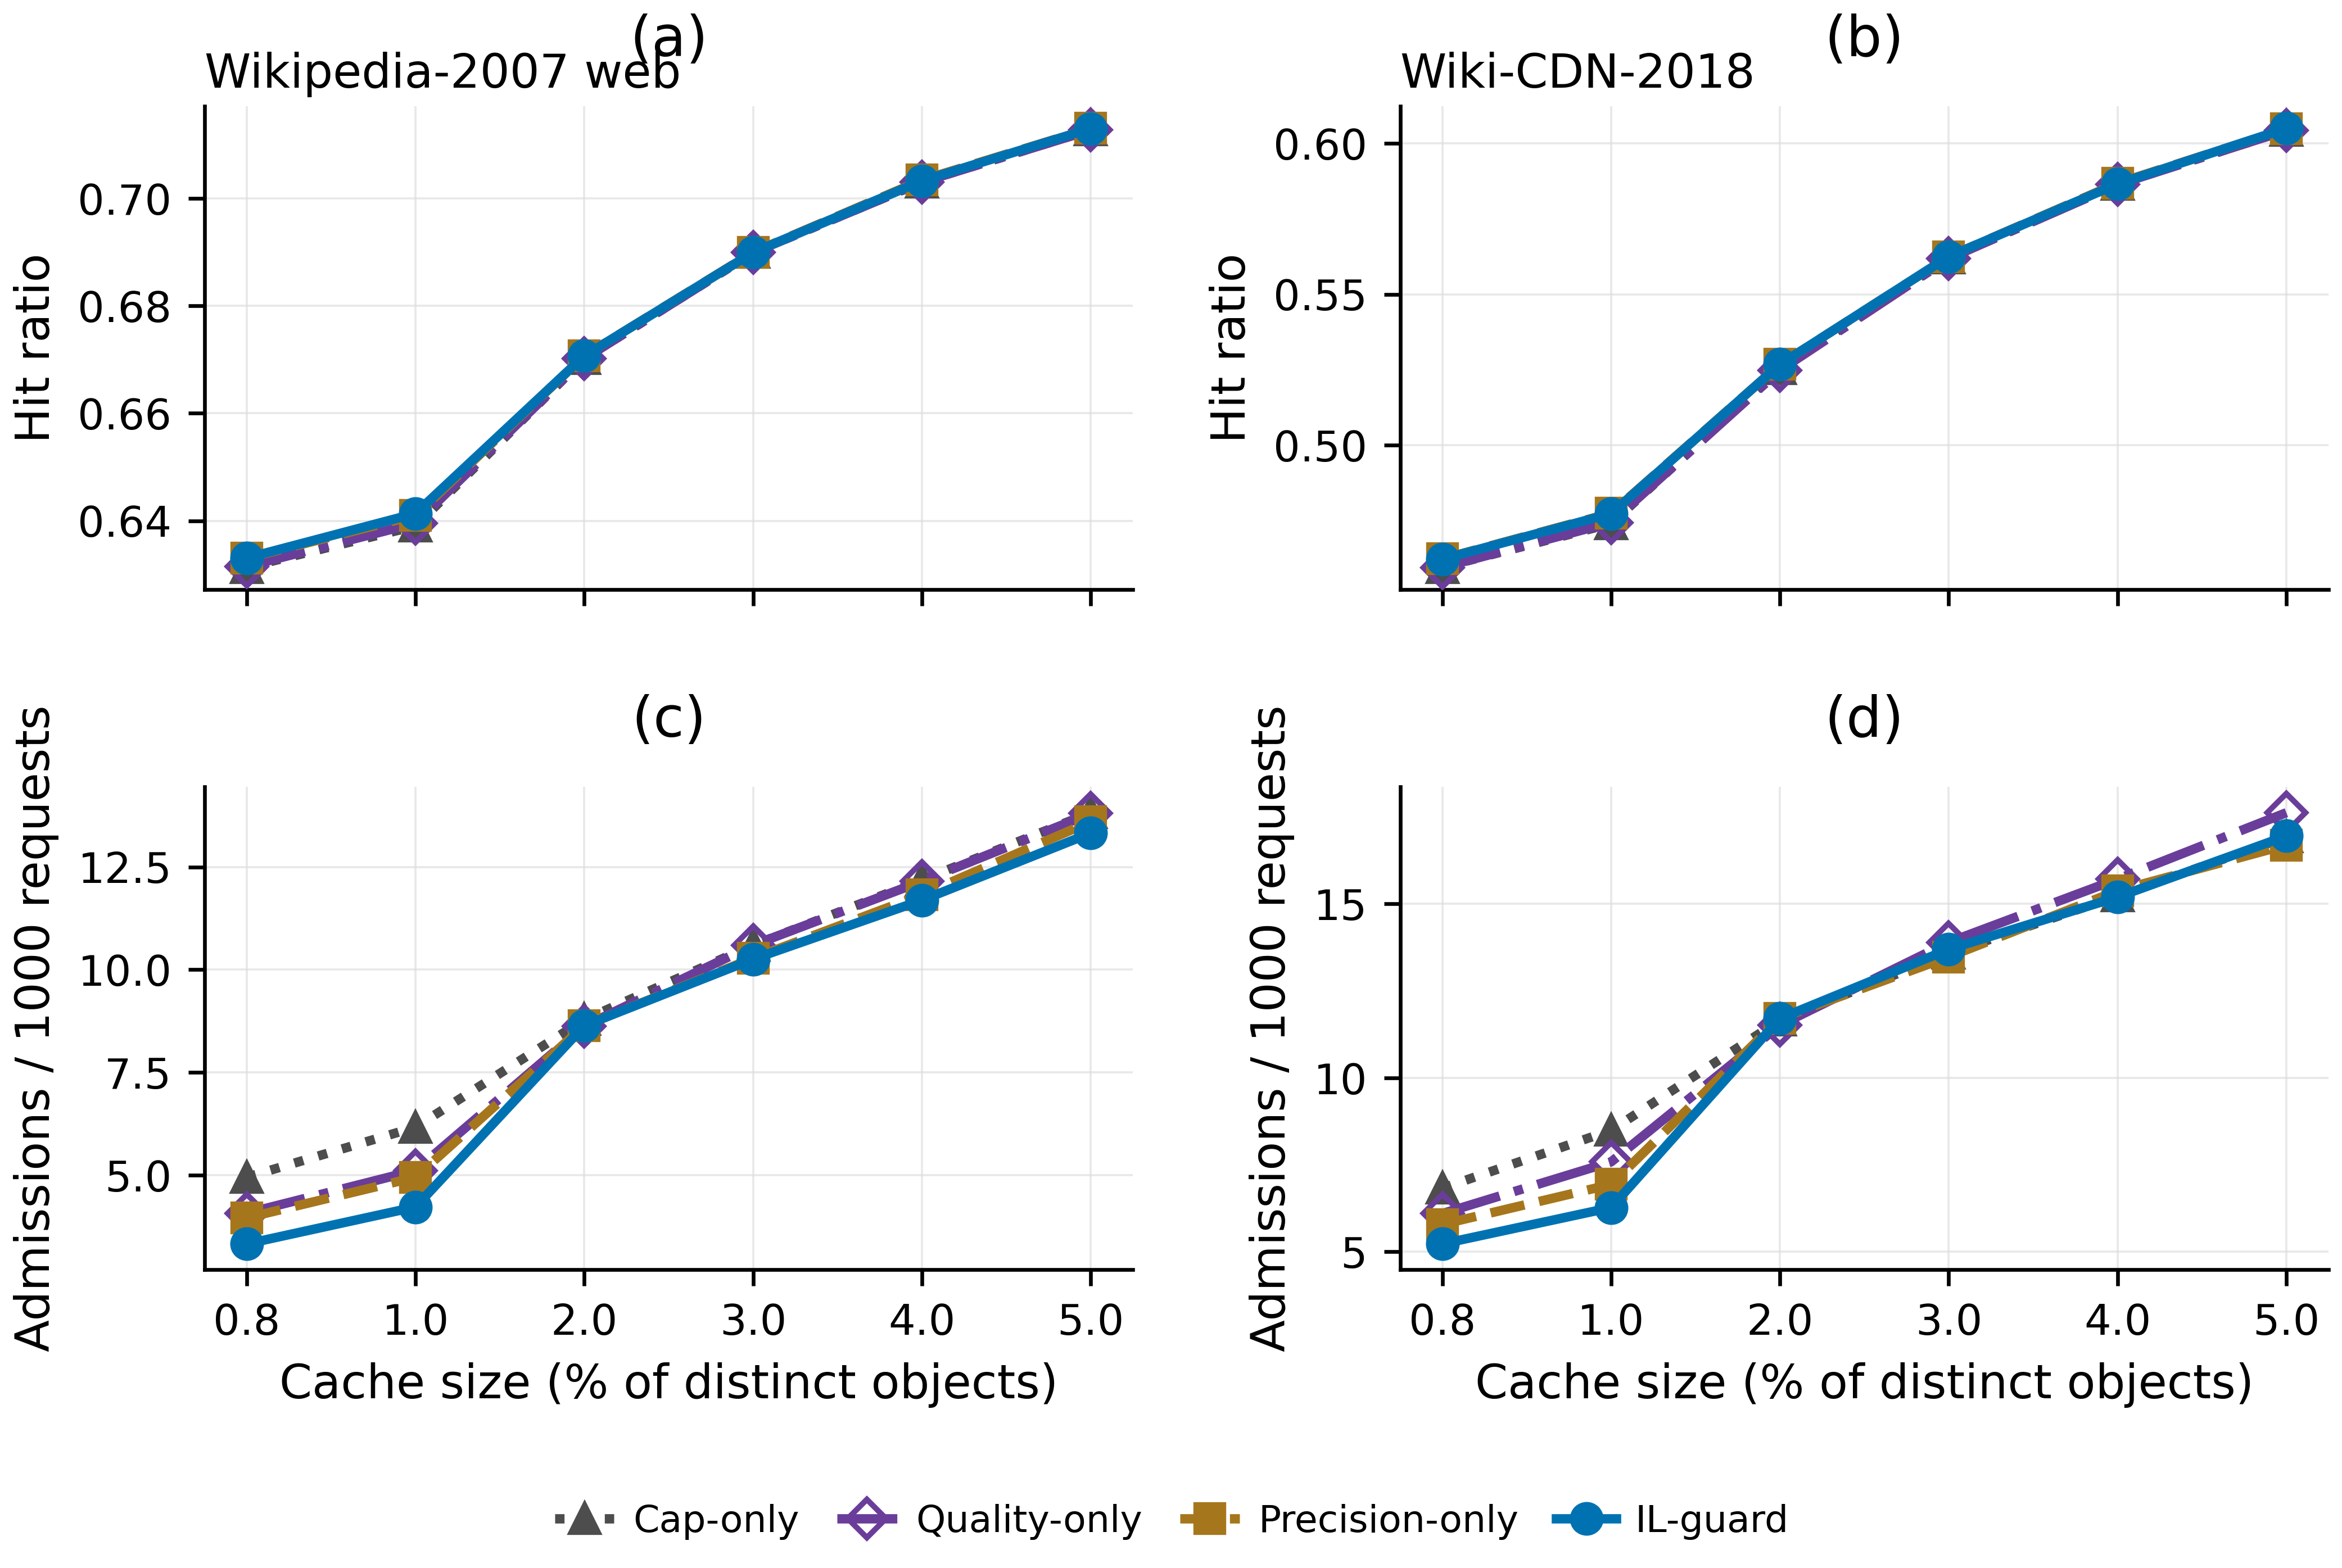

*Quality-only cap 0.020 appendix ablation. The figure shows what happens when score-quality is active without effective-precision feedback. Where quality-only is weak, the interpretation is explicit: score-quality alone is not the primary HR-driving component; its validated role is timing refinement within the final controller.*

Dataset,Variant,Avg HR,ΔHR vs Cap-only,Admissions / 1000 requests,Hit-yield / admission,Pollution proxy,Admission precision
Wiki-CDN-2018,Cap-only,0.535250,0.000000,12.115,0.700,0.578,0.102
Wiki-CDN-2018,Quality-only,0.535191,-0.000059,12.070,0.720,0.579,0.103
Wiki-CDN-2018,Precision-only,0.536762,0.001513,11.661,0.741,0.573,0.105
Wiki-CDN-2018,IL-guard,0.536710,0.001460,11.507,0.766,0.572,0.107
Wikipedia-2007 web,Cap-only,0.674387,0.000000,9.415,1.154,0.634,0.088
Wikipedia-2007 web,Quality-only,0.674497,0.000110,9.059,1.257,0.629,0.092
Wikipedia-2007 web,Precision-only,0.675204,0.000817,8.873,1.284,0.625,0.094
Wikipedia-2007 web,IL-guard,0.675241,0.000854,8.574,1.395,0.619,0.099


*Quality-only cap 0.020 ablation summary. Quality-only isolates score-quality without effective-precision; weak HR movement here should be reported rather than hidden.*

In [19]:
if quality_only_cap020_available:
    fig_name = "FigS4_quality_only_cap020_ablation"
    fig, axes = plt.subplots(2, 2, figsize=(DOUBLE_COL_WIDTH, 5.0), sharex=True)
    variant_order = ["Cap-only", "Quality-only", "Precision-only", "IL-guard"]
    for col, dataset in enumerate(DATASETS):
        ax_hr = axes[0, col]
        ax_adm = axes[1, col]
        curve_rows = []
        for variant in ["cap_only_cap020", "precision_only_cap020", "full_cap020"]:
            sub = sort_by_cache(df_precision[(df_precision["dataset"] == dataset) & (df_precision["variant"] == variant)]).copy()
            sub["Variant"] = label_variant(variant)
            curve_rows.append(sub[["dataset", "Variant", "capacity_percent", "hit_ratio", "admissions_per_1000_requests"]])
        qsub = sort_by_cache(quality_curve_df[quality_curve_df["dataset"] == dataset].rename(columns={"Variant": "Variant"}))
        curve_rows.append(qsub[["dataset", "Variant", "capacity_percent", "hit_ratio", "admissions_per_1000_requests"]])
        plot_df = pd.concat(curve_rows, ignore_index=True)
        hr_values = []
        adm_values = []
        for label in variant_order:
            sub = sort_by_cache(plot_df[plot_df["Variant"] == label])
            if sub.empty:
                continue
            style = method_style(label)
            ax_hr.plot(cache_x_positions(sub["capacity_percent"]), sub["hit_ratio"], label=label, **style)
            ax_adm.plot(cache_x_positions(sub["capacity_percent"]), sub["admissions_per_1000_requests"], label=label, **style)
            hr_values.extend(sub["hit_ratio"].tolist())
            adm_values.extend(sub["admissions_per_1000_requests"].tolist())
        set_padded_ylim(ax_hr, hr_values, pad_frac=0.05)
        set_padded_ylim(ax_adm, adm_values, pad_frac=0.06)
        ax_hr.set_title(DATASET_LABELS[dataset], loc="left", pad=4)
        ax_hr.set_ylabel("Hit ratio")
        ax_adm.set_ylabel("Admissions / 1000 requests")
        apply_cache_axis(ax_adm)
    for ax, lab in zip(axes.ravel(), ["(a)", "(b)", "(c)", "(d)"]):
        add_panel_label(ax, lab)
    fig.tight_layout(rect=[0, 0.17, 1, 0.96])
    add_global_legend(fig, axes, ncol=4, y=0.0)
    paths = save_figure(fig, fig_name)
    display_figure(paths["png"])
    plt.close(fig)
    caption = "Quality-only cap 0.020 appendix ablation. The figure shows what happens when score-quality is active without effective-precision feedback. Where quality-only is weak, the interpretation is explicit: score-quality alone is not the primary HR-driving component; its validated role is timing refinement within the final controller."
    display_caption(caption)
    add_caption("figure", fig_name, caption)
    record_manifest(fig_name, "figure", paths.values(), [REQUIRED_FILES["effective_precision_summary.csv"], *quality_only_cap020_source_paths], "Appendix ablation for score-quality without effective-precision feedback.", "appendix", "Generated only because quality-only cap020 source summaries were found.")

    rows = []
    for dataset in DATASETS:
        dset = df_precision[df_precision["dataset"] == dataset]
        cap_avg_hr = dset[dset["variant"] == "cap_only_cap020"]["hit_ratio"].mean()
        for variant in ["cap_only_cap020", "quality_only_cap020", "precision_only_cap020", "full_cap020"]:
            if variant == "quality_only_cap020":
                sub = quality_summary_df[quality_summary_df["dataset"] == dataset]
                if sub.empty:
                    continue
                r = sub.iloc[0]
                avg_hr = r["Avg HR"]
                rows.append({
                    "Dataset": DATASET_LABELS[dataset],
                    "Variant": "Quality-only",
                    "Avg HR": avg_hr,
                    "ΔHR vs Cap-only": avg_hr - cap_avg_hr,
                    "Admissions / 1000 requests": r["Admissions / 1000 requests"],
                    "Hit-yield / admission": r["Hit-yield / admission"],
                    "Pollution proxy": r["Pollution proxy"],
                    "Admission precision": r["Admission precision"],
                })
            else:
                sub = dset[dset["variant"] == variant]
                avg_hr = sub["hit_ratio"].mean()
                rows.append({
                    "Dataset": DATASET_LABELS[dataset],
                    "Variant": label_variant(variant),
                    "Avg HR": avg_hr,
                    "ΔHR vs Cap-only": avg_hr - cap_avg_hr,
                    "Admissions / 1000 requests": sub["admissions_per_1000_requests"].mean(),
                    "Hit-yield / admission": sub["hit_yield_per_admission"].mean(),
                    "Pollution proxy": sub["pollution_ratio"].mean(),
                    "Admission precision": sub["admission_precision"].mean(),
                })
    table_s3 = pd.DataFrame(rows)
    table_s3["_variant_order"] = table_s3["Variant"].map({"Cap-only": 0, "Quality-only": 1, "Precision-only": 2, "IL-guard": 3})
    table_s3 = table_s3.sort_values(["Dataset", "_variant_order"]).drop(columns="_variant_order")
    display(format_table_for_display(table_s3, {
        "Avg HR": "{:.6f}",
        "ΔHR vs Cap-only": "{:.6f}",
        "Admissions / 1000 requests": "{:.3f}",
        "Hit-yield / admission": "{:.3f}",
        "Pollution proxy": "{:.3f}",
        "Admission precision": "{:.3f}",
    }))
    table_name = "Table_S3_quality_only_cap020_ablation"
    table_paths = save_table(table_s3, table_name)
    caption = "Quality-only cap 0.020 ablation summary. Quality-only isolates score-quality without effective-precision; weak HR movement here should be reported rather than hidden."
    display_caption(caption)
    add_caption("table", table_name, caption)
    record_manifest(table_name, "table", table_paths.values(), [REQUIRED_FILES["effective_precision_summary.csv"], *quality_only_cap020_source_paths], "Appendix quality-only cap020 ablation table.", "appendix", "Generated only because quality-only cap020 source summaries were found.")
else:
    add_validation("Quality-only appendix artifact generation", "SKIPPED", "; ".join(quality_only_missing_messages))
    display(Markdown("**Quality-only appendix artifacts skipped:** " + "; ".join(quality_only_missing_messages)))


In [20]:
# Caption files, narrative files, final manifest, and strict validation report.
FIGURE_CAPTION_ORDER = [
    "Fig3_system_hit_ratio_comparison_paper",
    "Fig4_admission_diagnostics_across_baselines_paper",
    "Fig5_effective_precision_feedback_delta_paper",
    "Fig6_score_quality_timing_attribution_paper",
    "FigS1_paired_bootstrap_support_paper",
    "FigS2_cap_sensitivity_selection_paper",
    "FigS3_selective_suppression_diagnostics_paper",
    "FigS4_quality_only_cap020_ablation",
]
TABLE_CAPTION_ORDER = [
    "Table_I_experimental_setup_paper",
    "Table_II_system_level_average_hr_paper",
    "Table_III_admission_diagnostics_across_baselines_paper",
    "Table_IV_effective_precision_attribution_paper",
    "Table_V_score_quality_timing_summary_paper",
    "Table_S1_selective_suppression_diagnostics_paper",
    "Table_S2_precision_correlation_diagnostics_paper",
    "Table_S3_quality_only_cap020_ablation",
    "Table_S4_cap_selection_summary_paper",
]


def ordered_caption_records(kind, name_order):
    records = [rec for rec in caption_records if rec["kind"] == kind]
    by_name = {rec["name"]: rec for rec in records}
    ordered = [by_name[name] for name in name_order if name in by_name]
    ordered.extend(rec for rec in records if rec["name"] not in set(name_order))
    return ordered


figure_caption_lines = ["# Figure Captions v5", ""]
for rec in ordered_caption_records("figure", FIGURE_CAPTION_ORDER):
    figure_caption_lines.extend([f"## {rec['name']}", rec["caption"], ""])
(CAPTION_DIR / "figure_captions_v5.md").write_text("\n".join(figure_caption_lines), encoding="utf-8")

table_caption_lines = ["# Table Captions v5", ""]
for rec in ordered_caption_records("table", TABLE_CAPTION_ORDER):
    table_caption_lines.extend([f"## {rec['name']}", rec["caption"], ""])
(CAPTION_DIR / "table_captions_v5.md").write_text("\n".join(table_caption_lines), encoding="utf-8")

main_order = [
    "Fig. 1: System architecture",
    "Fig. 2: Slot-level execution",
    "Table I: Experimental setup",
    "Fig. 3: System-level hit-ratio comparison",
    "Table II: System-level average HR",
    "Fig. 4: Admission diagnostics across baselines",
    "Table III: Admission diagnostics summary",
    "Fig. 5: Effective-precision feedback attribution",
    "Table IV: Effective-precision attribution summary",
    "Fig. 6: Score-quality timing attribution",
    "Table V: Score-quality timing summary",
    "Fig. 7: Post-warm-up overhead",
    "Table VI: Post-warm-up overhead summary",
]
appendix_order = [
    "Fig. S1: Paired bootstrap support",
    "Fig. S2: Cap sensitivity and cap selection",
    "Table S4: Cap-selection summary",
    "Fig. S3: Selective suppression diagnostics",
    "Table S1: Selective suppression diagnostics",
    "Table S2: Precision correlation diagnostics",
]
if quality_only_cap020_available:
    appendix_order.extend(["Fig. S4: Quality-only cap020 ablation", "Table S3: Quality-only cap020 ablation"])
else:
    appendix_order.append("Fig. S4: Quality-only cap020 ablation not generated; source unavailable")
appendix_order.append("Fig. S5: Full overhead component breakdown")

outline_lines = [
    "# Paper Results Outline v5", "", "## Main Paper Order", "",
    "**Fig. 1: System architecture.** TODO: update the editable source diagram to name the Guardrails Admission Controller and state admission-only control with fixed LRU eviction.", "",
    "**Fig. 2: Slot-level execution.** TODO: update the editable source diagram to state lagged effective precision, score-quality modulation, fill safeguard, η_top = 0.020, and the one-slot delayed-apply order.", "",
    "**Table I: Experimental setup.** Documents the trace-driven replay protocol, final dataset labels, cache-size sweep, delayed-admission discipline, and final Guardrails cap η_top = 0.020.", "",
    "**Fig. 3 and Table II: System-level hit-ratio comparison.** Establishes the end-to-end operating point with IL-guard, IL-no-guard, Delayed-GBDT, Windowed-2Hit-LRU, and Delayed-TinyLFU on Wikipedia-2007 web and Wiki-CDN-2018.", "",
    "**Fig. 4 and Table III: Admission diagnostics across baselines.** Reports insertion pressure, pollution proxy, hit-yield per admission, and metric-source disclosure. The intended conclusion is the best hit-ratio/admission-efficiency trade-off, not universal dominance on every diagnostic.", "",
    "**Fig. 5 and Table IV: Effective-precision feedback attribution.** Uses Precision-only minus Cap-only deltas to isolate lag-robust effective-precision feedback over a cap-only controller; IL-guard is retained as full-controller context.", "",
    "**Fig. 6 and Table V: Score-quality timing attribution.** Exact schedule replay reuses IL-guard's realized slot-level admission budget; permuted schedule replay preserves selected-admission volume but removes slot alignment. The supported claim is timing refinement.", "",
    "**Fig. 7 and Table VI: Post-warm-up overhead.** Generated by the overhead notebook; this is the only main-paper overhead slot.", "",
    "## Appendix Order", "",
    "**Fig. S1: Paired bootstrap support.** Supporting uncertainty evidence, not a main-paper figure.", "",
    "**Fig. S2 and Table S4: Cap sensitivity and cap selection.** Support cap 0.020 as a robust near-best tested operating point without claiming global optimality.", "",
    "**Fig. S3 and Table S1: Selective suppression diagnostics.** Explain where score-quality actions are visible or masked by the tight cap.", "",
    "**Table S2: Precision correlation diagnostics.** Provides diagnostic support for effective-precision feedback.",
]
if quality_only_cap020_available:
    outline_lines.extend(["", "**Fig. S4 and Table S3: Quality-only cap020 ablation.** Appendix-only evidence for score-quality without effective-precision."])
else:
    outline_lines.extend(["", "**Fig. S4: Quality-only cap020 ablation.** Not generated because source files were unavailable."])
outline_lines.extend(["", "**Fig. S5: Full overhead component breakdown.** Generated by the overhead notebook as appendix material."])
(NARRATIVE_DIR / "paper_results_outline_v5.md").write_text("\n".join(outline_lines) + "\n", encoding="utf-8")

map_lines = [
    "# Paper Order Map v5", "",
    "- Table I -> `Table_I_experimental_setup_paper`",
    "- Fig. 3 -> `Fig3_system_hit_ratio_comparison_paper`",
    "- Table II -> `Table_II_system_level_average_hr_paper`",
    "- Fig. 4 -> `Fig4_admission_diagnostics_across_baselines_paper`",
    "- Table III -> `Table_III_admission_diagnostics_across_baselines_paper`",
    "- Fig. 5 -> `Fig5_effective_precision_feedback_delta_paper`",
    "- Table IV -> `Table_IV_effective_precision_attribution_paper`",
    "- Fig. 6 -> `Fig6_score_quality_timing_attribution_paper`",
    "- Table V -> `Table_V_score_quality_timing_summary_paper`",
    "- Fig. 7 -> overhead notebook `Fig7_post_warmup_overhead_claim_driven_paper`",
    "- Table VI -> overhead notebook `Table_VI_post_warmup_overhead_summary_paper`",
    "- Fig. S1 -> `FigS1_paired_bootstrap_support_paper`",
    "- Fig. S2 -> `FigS2_cap_sensitivity_selection_paper`",
    "- Table S4 -> `Table_S4_cap_selection_summary_paper`",
    "- Fig. S3 -> `FigS3_selective_suppression_diagnostics_paper`",
]
if quality_only_cap020_available:
    map_lines.append("- Fig. S4 -> `FigS4_quality_only_cap020_ablation`")
(NARRATIVE_DIR / "paper_order_map_v5.md").write_text("\n".join(map_lines) + "\n", encoding="utf-8")

claim_rows = [
    {"Claim": "IL-guard is the strongest tested system overall", "Main evidence artifact(s)": "Fig. 3; Table II", "Strength category": "strong", "Safe wording": "IL-guard is the strongest tested final operating point overall across the evaluated workloads and baselines.", "Boundary": "Do not claim global optimality."},
    {"Claim": "Effective-precision improves cap-only control", "Main evidence artifact(s)": "Fig. 5; Table IV", "Strength category": "moderate-to-strong", "Safe wording": "Effective-precision acts as lag-robust feedback over a cap-only controller.", "Boundary": "Do not claim it explains every full-controller gain."},
    {"Claim": "Score-quality matters through budget timing", "Main evidence artifact(s)": "Fig. 6; Table V", "Strength category": "strong", "Safe wording": "Score-quality is validated as time-aligned budget refinement by exact schedule replay versus permuted schedule replay.", "Boundary": "Do not claim direct HR improvement over the precision-only controller."},
    {"Claim": "Cap 0.020 is the final robust tested setting", "Main evidence artifact(s)": "Fig. S2; Table S4", "Strength category": "supporting", "Safe wording": "Cap 0.020 is a robust near-best tested operating point selected for the final paper setting.", "Boundary": "Do not claim global optimality."},
]
claim_columns = ["Claim", "Main evidence artifact(s)", "Strength category", "Safe wording", "Boundary"]
(NARRATIVE_DIR / "claim_strength_matrix_v5.md").write_text("# Claim Strength Matrix v5\n\n" + markdown_table(claim_rows, claim_columns) + "\n", encoding="utf-8")

manifest_path = OUTPUT_ROOT / "artifact_manifest_v5.json"
manifest_path.write_text(json.dumps(manifest_entries, indent=2), encoding="utf-8")

OVERHEAD_ROOT = Path("results/overhead_benchmark_v2_cap020/analysis_outputs/claim_driven_main")
OVERHEAD_FIG_DIR = OVERHEAD_ROOT / "figures"
OVERHEAD_TABLE_DIR = OVERHEAD_ROOT / "tables"
OVERHEAD_APPENDIX_FIG_DIR = OVERHEAD_FIG_DIR / "appendix"

def files_for(stem, directory, exts):
    return [str(directory / f"{stem}.{ext}") for ext in exts if (directory / f"{stem}.{ext}").exists()]

def manifest_line(label, paths):
    if paths:
        return [f"- {label}: " + ", ".join(f"`{p}`" for p in paths)]
    return [f"- {label}: TODO source artifact not found in this notebook"]

final_manifest_lines = ["# Final Claim-Driven Paper Artifact Manifest", "", "## Main paper"]
final_manifest_lines.extend(manifest_line("Fig. 1: System architecture", []))
final_manifest_lines.extend(manifest_line("Fig. 2: Slot-level execution", []))
final_manifest_lines.extend(manifest_line("Table I: Experimental setup", files_for("Table_I_experimental_setup_paper", TABLE_DIR, ["csv", "tex"])))
final_manifest_lines.extend(manifest_line("Fig. 3: System-level hit-ratio comparison", files_for("Fig3_system_hit_ratio_comparison_paper", FIG_DIR, ["pdf", "png", "svg"])))
final_manifest_lines.extend(manifest_line("Table II: System-level average HR", files_for("Table_II_system_level_average_hr_paper", TABLE_DIR, ["csv", "tex"])))
final_manifest_lines.extend(manifest_line("Fig. 4: Admission diagnostics across baselines", files_for("Fig4_admission_diagnostics_across_baselines_paper", FIG_DIR, ["pdf", "png", "svg"])))
final_manifest_lines.extend(manifest_line("Table III: Admission diagnostics summary", files_for("Table_III_admission_diagnostics_across_baselines_paper", TABLE_DIR, ["csv", "tex"])))
final_manifest_lines.extend(manifest_line("Fig. 5: Effective-precision feedback attribution", files_for("Fig5_effective_precision_feedback_delta_paper", FIG_DIR, ["pdf", "png", "svg"])))
final_manifest_lines.extend(manifest_line("Table IV: Effective-precision attribution summary", files_for("Table_IV_effective_precision_attribution_paper", TABLE_DIR, ["csv", "tex"])))
final_manifest_lines.extend(manifest_line("Fig. 6: Score-quality timing attribution", files_for("Fig6_score_quality_timing_attribution_paper", FIG_DIR, ["pdf", "png", "svg"])))
final_manifest_lines.extend(manifest_line("Table V: Score-quality timing summary", files_for("Table_V_score_quality_timing_summary_paper", TABLE_DIR, ["csv", "tex"])))
final_manifest_lines.extend(manifest_line("Fig. 7: Post-warm-up overhead", files_for("Fig7_post_warmup_overhead_claim_driven_paper", OVERHEAD_FIG_DIR, ["pdf", "png", "svg"])))
final_manifest_lines.extend(manifest_line("Table VI: Post-warm-up overhead summary", files_for("Table_VI_post_warmup_overhead_summary_paper", OVERHEAD_TABLE_DIR, ["csv", "tex"])))
final_manifest_lines.extend(["", "## Appendix"])
final_manifest_lines.extend(manifest_line("Fig. S1: Paired bootstrap support", files_for("FigS1_paired_bootstrap_support_paper", FIG_DIR, ["pdf", "png", "svg"])))
final_manifest_lines.extend(manifest_line("Fig. S2: Cap sensitivity and cap selection", files_for("FigS2_cap_sensitivity_selection_paper", FIG_DIR, ["pdf", "png", "svg"])))
final_manifest_lines.extend(manifest_line("Table S4: Cap-selection summary", files_for("Table_S4_cap_selection_summary_paper", TABLE_DIR, ["csv", "tex"])))
final_manifest_lines.extend(manifest_line("Fig. S3: Selective suppression diagnostics", files_for("FigS3_selective_suppression_diagnostics_paper", FIG_DIR, ["pdf", "png", "svg"])))
final_manifest_lines.extend(manifest_line("Fig. S4: Quality-only cap020 ablation", files_for("FigS4_quality_only_cap020_ablation", FIG_DIR, ["pdf", "png", "svg"])))
final_manifest_lines.extend(manifest_line("Fig. S5: Full overhead component breakdown", files_for("FigS5_full_overhead_component_breakdown_paper", OVERHEAD_APPENDIX_FIG_DIR, ["pdf", "png", "svg"])))
final_manifest_path = OUTPUT_ROOT / "paper_artifact_manifest_final_claim_driven.md"
final_manifest_path.write_text("\n".join(final_manifest_lines) + "\n", encoding="utf-8")

add_validation("Figure 1 diagram source", "WARN", "TODO: editable source diagram was not found in this notebook; update external Fig. 1 source with Guardrails Admission Controller wording.")
add_validation("Figure 2 diagram source", "WARN", "TODO: editable source diagram was not found in this notebook; update external Fig. 2 source with lagged effective precision, fill safeguard, η_top = 0.020, and delayed-apply order.")
add_validation("Final public dataset labels", "OK" if DATASET_LABELS == {"wikipedia_september_2007": "Wikipedia-2007 web", "wiki2018": "Wiki-CDN-2018"} else "FAIL", str(DATASET_LABELS))
add_validation("Admission diagnostics figure completeness", "OK" if fig4_admission_methods == SYSTEM_POLICY_ORDER else "FAIL", f"Fig. 4 methods: {fig4_admission_methods}")
add_validation("Effective-precision delta figure comparison", "OK" if fig5_delta_comparison == "Precision-only minus Cap-only" else "FAIL", fig5_delta_comparison)
add_validation("Main order excludes bootstrap and cap sensitivity", "OK" if not any("bootstrap" in item.lower() or "cap sensitivity" in item.lower() for item in main_order) else "FAIL", "; ".join(main_order))

required_main_artifacts = [TABLE_DIR / "Table_I_experimental_setup_paper.tex", FIG_DIR / "Fig3_system_hit_ratio_comparison_paper.pdf", TABLE_DIR / "Table_II_system_level_average_hr_paper.tex", FIG_DIR / "Fig4_admission_diagnostics_across_baselines_paper.pdf", TABLE_DIR / "Table_III_admission_diagnostics_across_baselines_paper.tex", FIG_DIR / "Fig5_effective_precision_feedback_delta_paper.pdf", TABLE_DIR / "Table_IV_effective_precision_attribution_paper.tex", FIG_DIR / "Fig6_score_quality_timing_attribution_paper.pdf", TABLE_DIR / "Table_V_score_quality_timing_summary_paper.tex"]
missing_required = [str(p) for p in required_main_artifacts if not p.exists()]
add_validation("Required main artifacts exist", "OK" if not missing_required else "FAIL", "; ".join(missing_required) if missing_required else "all present")

try:
    validate_unique_color_registry()
    add_validation("Unique color registry", "OK", "METHOD_COLORS, DATASET_COLORS, REPLAY_COLORS, and COMPONENT_COLORS validated")
except AssertionError as exc:
    add_validation("Unique color registry", "FAIL", str(exc))
for color_check_name, expected_labels in [
    ("Fig3_system_hit_ratio_comparison_paper", SYSTEM_POLICY_ORDER),
    ("Fig4_admission_diagnostics_across_baselines_paper", [DATASET_LABELS[d] for d in DATASETS]),
    ("Fig5_effective_precision_feedback_delta_paper", [DATASET_LABELS[d] for d in DATASETS]),
    ("Fig6_score_quality_timing_attribution_paper", ["IL-guard", "Exact schedule replay", "Permuted schedule replay"]),
]:
    try:
        validate_figure_color_usage(color_check_name, expected_labels)
        add_validation(f"Color usage: {color_check_name}", "OK", ", ".join(expected_labels))
    except AssertionError as exc:
        add_validation(f"Color usage: {color_check_name}", "FAIL", str(exc))

main_manifest_text = final_manifest_path.read_text(encoding="utf-8")
for required_phrase in ["Fig. 3: System-level hit-ratio comparison", "Fig. 4: Admission diagnostics across baselines", "Fig. 5: Effective-precision feedback attribution", "Fig. 6: Score-quality timing attribution"]:
    add_validation(f"Main manifest contains {required_phrase}", "OK" if required_phrase in main_manifest_text else "FAIL", required_phrase)
add_validation("Main manifest has overhead as Fig. 7", "OK" if "Fig. 7: Post-warm-up overhead" in main_manifest_text else "FAIL", "Fig. 7 overhead entry")

fig4_required_terms = ["IL-guard", "IL-no-guard", "Delayed-GBDT", "Windowed-2Hit-LRU", "Delayed-TinyLFU", "admissions/1000 requests", "pollution proxy", "hit-yield/admission", "Metric source"]
fig4_text = (CAPTION_DIR / "figure_captions_v5.md").read_text(encoding="utf-8") + "\n" + (TABLE_DIR / "Table_III_admission_diagnostics_across_baselines_paper.csv").read_text(encoding="utf-8")
fig4_text_norm = fig4_text.replace("Admissions / 1000 requests", "admissions/1000 requests").replace("Hit-yield / admission", "hit-yield/admission").lower()
fig4_missing = [term for term in fig4_required_terms if term.lower() not in fig4_text_norm]
add_validation("Fig. 4/table required terms", "OK" if not fig4_missing else "FAIL", "; ".join(fig4_missing) if fig4_missing else "all present")
add_validation("Fig. 4 panel (a) log scale", "OK" if globals().get("fig4_panel_a_log_scale", False) else "FAIL", "Panel (a) uses log-scale y-axis for admissions/1000 requests.")

for fig in generated_figures:
    paths = fig["paths"]
    missing = [ext for ext in ["png", "pdf", "svg"] if ext not in paths or not Path(paths[ext]).exists()]
    add_validation(f"Figure files exist: {fig['name']}", "OK" if not missing else "FAIL", f"missing={missing}")
try:
    from PIL import Image as PILImage
    for fig in generated_figures:
        paths = {k: Path(v) for k, v in fig["paths"].items()}
        png_path = paths.get("png")
        with PILImage.open(png_path) as im:
            width, height = im.size
            arr = np.asarray(im.convert("RGB"))
        nonwhite_fraction = float(np.mean(np.any(arr < 248, axis=2)))
        ok_resolution = max(width, height) >= 1000 and min(width, height) > 0
        ok_nonblank = nonwhite_fraction > 0.005
        size_failures = []
        if paths.get("pdf") and paths["pdf"].exists() and paths["pdf"].stat().st_size <= 10_000:
            size_failures.append("PDF <= 10 KB")
        if png_path.exists() and png_path.stat().st_size <= 30_000:
            size_failures.append("PNG <= 30 KB")
        if paths.get("svg") and paths["svg"].exists() and paths["svg"].stat().st_size <= 10_000:
            size_failures.append("SVG <= 10 KB")
        status = "OK" if ok_resolution and ok_nonblank and not size_failures else "FAIL"
        details = f"{width}x{height}px; nonwhite={nonwhite_fraction:.4f}; " + ("sizes OK" if not size_failures else "; ".join(size_failures))
        add_validation(f"Figure readability/files: {fig['name']}", status, details)
except Exception as exc:
    add_validation("Figure readability/files validation", "WARN", f"PIL validation unavailable: {exc}")

for table in generated_tables:
    paths = table["paths"]
    missing = [ext for ext in ["csv", "tex"] if ext not in paths or not Path(paths[ext]).exists()]
    add_validation(f"Table files exist: {table['name']}", "OK" if not missing else "FAIL", f"missing={missing}")

paper_text_paths = [CAPTION_DIR / "figure_captions_v5.md", CAPTION_DIR / "table_captions_v5.md", NARRATIVE_DIR / "paper_results_outline_v5.md", NARRATIVE_DIR / "paper_order_map_v5.md", NARRATIVE_DIR / "claim_strength_matrix_v5.md", final_manifest_path]
paper_text_paths.extend(sorted(TABLE_DIR.glob("*.tex")))
combined_public_text = "\n".join(p.read_text(encoding="utf-8") for p in paper_text_paths if p.exists())
standalone_lru_rows = []
if "table_ii" in globals():
    standalone_lru_rows.extend(table_ii.loc[table_ii["Method"] == "LRU"].to_dict("records"))
if "table_iii_admission" in globals():
    standalone_lru_rows.extend(table_iii_admission.loc[table_iii_admission["Method"] == "LRU"].to_dict("records"))
add_validation("Standalone LRU baseline excluded", "OK" if "LRU" not in SYSTEM_POLICY_ORDER and not standalone_lru_rows else "FAIL", f"SYSTEM_POLICY_ORDER={SYSTEM_POLICY_ORDER}; standalone_lru_rows={len(standalone_lru_rows)}")

forbidden_final_terms = ["Wikipedia trace", "CDN trace", "Wikipedia 2007", "Wikipedia-2007 Web", "Wiki2018", "wikipedia_september_2007", "wiki2018", "Unguarded IL", "IL-Guard-full", "IL-no-guard legacy", "IL-Guard", "Full-Guard", "No-Guard", "eta_top = 0.05", "ηtop = 0.05", "η_top = 0.05"]
forbidden_hits = [term for term in forbidden_final_terms if term in combined_public_text]
required_final_terms = ["Wikipedia-2007 web", "Wiki-CDN-2018", "IL-guard", "IL-no-guard", "η_top = 0.020"]
required_missing = [term for term in required_final_terms if term not in combined_public_text]
add_validation("Forbidden final-paper terms absent", "OK" if not forbidden_hits else "FAIL", "; ".join(forbidden_hits) if forbidden_hits else "none")
bad_latex_control = []
for tex_path in sorted(TABLE_DIR.glob("*.tex")):
    raw = tex_path.read_bytes()
    bad = sorted({b for b in raw if b < 32 and b not in (9, 10, 13)})
    if bad:
        bad_latex_control.append(f"{tex_path.name}:{bad}")
add_validation("LaTeX table control characters absent", "OK" if not bad_latex_control else "FAIL", "; ".join(bad_latex_control) if bad_latex_control else "none")
add_validation("Required final-paper terms present", "OK" if not required_missing else "FAIL", "; ".join(required_missing) if required_missing else "all present")

failures = [row for row in validation_rows if row["Status"] == "FAIL"]
validation_report_lines = ["# Final Claim-Driven Validation Report", "", f"- timestamp: {datetime.now().astimezone().isoformat()}", f"- project root: `{PROJECT_ROOT}`", f"- output root: `{OUTPUT_ROOT}`", "", "## Main Paper Order"]
validation_report_lines.extend(f"- {item}" for item in main_order)
validation_report_lines.extend(["", "## Appendix Order"])
validation_report_lines.extend(f"- {item}" for item in appendix_order)
validation_report_lines.extend(["", "## Validation Log"])
validation_report_lines.extend(f"- {row['Status']}: {row['Check']} - {row['Details']}" for row in validation_rows)
validation_report_lines.extend(["", "## Generated Figure List"])
validation_report_lines.extend(f"- {fig['name']}: " + ", ".join(f"`{p}`" for p in fig["paths"].values()) for fig in generated_figures)
validation_report_lines.extend(["", "## Generated Table List"])
validation_report_lines.extend(f"- {table['name']}: " + ", ".join(f"`{p}`" for p in table["paths"].values()) for table in generated_tables)
validation_report_lines.extend(["", "## Warnings"])
validation_report_lines.extend(f"- {warning}" for warning in validation_warnings) if validation_warnings else validation_report_lines.append("- None.")
if failures:
    validation_report_lines.extend(["", "## Failures"])
    validation_report_lines.extend(f"- {row['Check']}: {row['Details']}" for row in failures)

validation_report_path = VALIDATION_DIR / "validation_report_final_claim_driven.md"
validation_report_path.write_text("\n".join(validation_report_lines) + "\n", encoding="utf-8")
(VALIDATION_DIR / "validation_report_v5_paper_order.md").write_text("\n".join(validation_report_lines) + "\n", encoding="utf-8")
display(Markdown("\n".join(validation_report_lines)))
if failures:
    raise AssertionError("Final claim-driven validation failed; see validation_report_final_claim_driven.md")

final_summary_lines = ["# Final Notebook Summary", "", f"- Output folder: `{OUTPUT_ROOT}`", f"- Final manifest: `{final_manifest_path}`", f"- Final validation report: `{validation_report_path}`", "", "## Final Main-Paper Order"]
final_summary_lines.extend(f"- {item}" for item in main_order)
final_summary_lines.extend(["", "## Final Appendix Order"])
final_summary_lines.extend(f"- {item}" for item in appendix_order)
final_summary_lines.extend(["", "## Strongest Claims Supported", "- IL-guard is the strongest tested final operating point overall.", "- Effective-precision is isolated as Precision-only minus Cap-only feedback.", "- Score-quality is validated as time-aligned budget refinement through exact schedule replay versus permuted schedule replay.", "- Cap 0.020 is a robust near-best tested operating point, kept in appendix support."])


# Final Claim-Driven Validation Report

- timestamp: 2026-05-14T19:55:52.353153+08:00
- project root: `/Users/macbook/Dokuments/S3/Publikasi Jurnal Internasional/Jurnal/ILNSE/il_cache`
- output root: `results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order`

## Main Paper Order
- Fig. 1: System architecture
- Fig. 2: Slot-level execution
- Table I: Experimental setup
- Fig. 3: System-level hit-ratio comparison
- Table II: System-level average HR
- Fig. 4: Admission diagnostics across baselines
- Table III: Admission diagnostics summary
- Fig. 5: Effective-precision feedback attribution
- Table IV: Effective-precision attribution summary
- Fig. 6: Score-quality timing attribution
- Table V: Score-quality timing summary
- Fig. 7: Post-warm-up overhead
- Table VI: Post-warm-up overhead summary

## Appendix Order
- Fig. S1: Paired bootstrap support
- Fig. S2: Cap sensitivity and cap selection
- Table S4: Cap-selection summary
- Fig. S3: Selective suppression diagnostics
- Table S1: Selective suppression diagnostics
- Table S2: Precision correlation diagnostics
- Fig. S4: Quality-only cap020 ablation
- Table S3: Quality-only cap020 ablation
- Fig. S5: Full overhead component breakdown

## Validation Log
- OK: Table I experimental setup generated - results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order/tables/Table_I_experimental_setup_paper.csv; results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order/tables/Table_I_experimental_setup_paper.tex
- OK: Schema: cap020_budget_control_summary.csv - All 19 required columns present
- OK: Schema: cap020_budget_control_avg_by_dataset.csv - All 11 required columns present
- OK: Schema: effective_precision_summary.csv - All 13 required columns present
- OK: Schema: score_quality_suppression_summary.csv - All 16 required columns present
- OK: Schema: paired_slot_bootstrap_ci.csv - All 11 required columns present
- OK: Schema: budget_match_ratios_cap020.csv - All 6 required columns present
- OK: Dataset completeness: df_budget - present=['wiki2018', 'wikipedia_september_2007']; missing=[]
- OK: Cache-size completeness: df_budget - wikipedia_september_2007: present=[0.8, 1.0, 2.0, 3.0, 4.0, 5.0], missing=[]; wiki2018: present=[0.8, 1.0, 2.0, 3.0, 4.0, 5.0], missing=[]
- OK: Dataset completeness: df_budget_avg - present=['wiki2018', 'wikipedia_september_2007']; missing=[]
- OK: Dataset completeness: df_precision - present=['wiki2018', 'wikipedia_september_2007']; missing=[]
- OK: Cache-size completeness: df_precision - wikipedia_september_2007: present=[0.8, 1.0, 2.0, 3.0, 4.0, 5.0], missing=[]; wiki2018: present=[0.8, 1.0, 2.0, 3.0, 4.0, 5.0], missing=[]
- OK: Dataset completeness: df_suppression - present=['wiki2018', 'wikipedia_september_2007']; missing=[]
- OK: Cache-size completeness: df_suppression - wikipedia_september_2007: present=[0.8, 1.0, 2.0, 3.0, 4.0, 5.0], missing=[]; wiki2018: present=[0.8, 1.0, 2.0, 3.0, 4.0, 5.0], missing=[]
- OK: Dataset completeness: df_ci - present=['wiki2018', 'wikipedia_september_2007']; missing=[]
- OK: Cache-size completeness: df_ci - wikipedia_september_2007: present=[0.8, 1.0, 2.0, 3.0, 4.0, 5.0], missing=[]; wiki2018: present=[0.8, 1.0, 2.0, 3.0, 4.0, 5.0], missing=[]
- OK: Dataset completeness: df_ratios - present=['wiki2018', 'wikipedia_september_2007']; missing=[]
- OK: Cache-size completeness: df_ratios - wikipedia_september_2007: present=[0.8, 1.0, 2.0, 3.0, 4.0, 5.0], missing=[]; wiki2018: present=[0.8, 1.0, 2.0, 3.0, 4.0, 5.0], missing=[]
- OK: Variant completeness: df_precision - missing=[]
- OK: Variant completeness: df_budget - missing=[]
- OK: Variant completeness: df_budget_avg - missing=[]
- OK: Variant completeness: df_suppression - missing=[]
- OK: Exact schedule replay selected-match ratio - max |match_ratio - 1| = 0.000000000000
- OK: Replay clamp rate - all exact/permuted replay clamp rates zero=True
- OK: Permuted schedule replay volume - Permuted schedule replay selected-match ratio is close to 1.0 for all cache sizes
- OK: Cap-sensitivity availability - Found full-controller cap-sensitivity rows for variants=['full_cap005', 'full_cap010', 'full_cap015', 'full_cap020', 'full_cap025', 'full_cap050', 'full_cap075', 'full_no_cap']
- OK: Cap-sensitivity missing variants - All requested full and quality-only cap-sensitivity variants found
- OK: Quality-only cap020 source availability - found=['results/guardrails_signal_v2/wikipedia_september_2007/001_summary_ilnse_A2_guardv2_quality_only_cap020_NB_all_sizes.json', 'results/guardrails_signal_v2/wiki2018/001_summary_ilnse_A2_guardv2_quality_only_cap020_NB_all_sizes.json']; missing=[]
- OK: System-level baseline legend completeness - Methods: ['IL-guard', 'IL-no-guard', 'Delayed-GBDT', 'Windowed-2Hit-LRU', 'Delayed-TinyLFU']
- WARN: Admission diagnostic proxy derivations - replay-summary-proxy:cache_hits/misses; replay-summary-proxy:miss_ratio; replay-summary-proxy:misses_per_1000_requests
- OK: Admission diagnostics completeness - All dataset-method-capacity rows contain the required admission diagnostics.
- WARN: Fallback table source: Table_S1_selective_suppression_diagnostics_paper - Missing v4 sources for Table_S1_selective_suppression_diagnostics_v4; reused existing v5 table files.
- WARN: Fallback table source: Table_S2_precision_correlation_diagnostics_paper - Missing v4 sources for Table_S2_precision_correlation_diagnostics_v4; reused existing v5 table files.
- WARN: Figure 1 diagram source - TODO: editable source diagram was not found in this notebook; update external Fig. 1 source with Guardrails Admission Controller wording.
- WARN: Figure 2 diagram source - TODO: editable source diagram was not found in this notebook; update external Fig. 2 source with lagged effective precision, fill safeguard, η_top = 0.020, and delayed-apply order.
- OK: Final public dataset labels - {'wikipedia_september_2007': 'Wikipedia-2007 web', 'wiki2018': 'Wiki-CDN-2018'}
- OK: Admission diagnostics figure completeness - Fig. 4 methods: ['IL-guard', 'IL-no-guard', 'Delayed-GBDT', 'Windowed-2Hit-LRU', 'Delayed-TinyLFU']
- OK: Effective-precision delta figure comparison - Precision-only minus Cap-only
- OK: Main order excludes bootstrap and cap sensitivity - Fig. 1: System architecture; Fig. 2: Slot-level execution; Table I: Experimental setup; Fig. 3: System-level hit-ratio comparison; Table II: System-level average HR; Fig. 4: Admission diagnostics across baselines; Table III: Admission diagnostics summary; Fig. 5: Effective-precision feedback attribution; Table IV: Effective-precision attribution summary; Fig. 6: Score-quality timing attribution; Table V: Score-quality timing summary; Fig. 7: Post-warm-up overhead; Table VI: Post-warm-up overhead summary
- OK: Required main artifacts exist - all present
- OK: Unique color registry - METHOD_COLORS, DATASET_COLORS, REPLAY_COLORS, and COMPONENT_COLORS validated
- OK: Color usage: Fig3_system_hit_ratio_comparison_paper - IL-guard, IL-no-guard, Delayed-GBDT, Windowed-2Hit-LRU, Delayed-TinyLFU
- OK: Color usage: Fig4_admission_diagnostics_across_baselines_paper - Wikipedia-2007 web, Wiki-CDN-2018
- OK: Color usage: Fig5_effective_precision_feedback_delta_paper - Wikipedia-2007 web, Wiki-CDN-2018
- OK: Color usage: Fig6_score_quality_timing_attribution_paper - IL-guard, Exact schedule replay, Permuted schedule replay
- OK: Main manifest contains Fig. 3: System-level hit-ratio comparison - Fig. 3: System-level hit-ratio comparison
- OK: Main manifest contains Fig. 4: Admission diagnostics across baselines - Fig. 4: Admission diagnostics across baselines
- OK: Main manifest contains Fig. 5: Effective-precision feedback attribution - Fig. 5: Effective-precision feedback attribution
- OK: Main manifest contains Fig. 6: Score-quality timing attribution - Fig. 6: Score-quality timing attribution
- OK: Main manifest has overhead as Fig. 7 - Fig. 7 overhead entry
- OK: Fig. 4/table required terms - all present
- OK: Fig. 4 panel (a) log scale - Panel (a) uses log-scale y-axis for admissions/1000 requests.
- OK: Figure files exist: Fig3_system_hit_ratio_comparison_paper - missing=[]
- OK: Figure files exist: Fig4_admission_diagnostics_across_baselines_paper - missing=[]
- OK: Figure files exist: Fig5_effective_precision_feedback_delta_paper - missing=[]
- OK: Figure files exist: Fig6_score_quality_timing_attribution_paper - missing=[]
- OK: Figure files exist: FigS1_paired_bootstrap_support_paper - missing=[]
- OK: Figure files exist: FigS2_cap_sensitivity_selection_paper - missing=[]
- OK: Figure files exist: FigS3_selective_suppression_diagnostics_paper - missing=[]
- OK: Figure files exist: FigS4_quality_only_cap020_ablation - missing=[]
- OK: Figure readability/files: Fig3_system_hit_ratio_comparison_paper - 4166x1783px; nonwhite=0.0772; sizes OK
- OK: Figure readability/files: Fig4_admission_diagnostics_across_baselines_paper - 4094x1772px; nonwhite=0.1791; sizes OK
- OK: Figure readability/files: Fig5_effective_precision_feedback_delta_paper - 4166x2707px; nonwhite=0.0732; sizes OK
- OK: Figure readability/files: Fig6_score_quality_timing_attribution_paper - 4166x2713px; nonwhite=0.0644; sizes OK
- OK: Figure readability/files: FigS1_paired_bootstrap_support_paper - 4166x1919px; nonwhite=0.0803; sizes OK
- OK: Figure readability/files: FigS2_cap_sensitivity_selection_paper - 4118x2930px; nonwhite=0.0667; sizes OK
- OK: Figure readability/files: FigS3_selective_suppression_diagnostics_paper - 4037x2989px; nonwhite=0.0654; sizes OK
- OK: Figure readability/files: FigS4_quality_only_cap020_ablation - 4166x2790px; nonwhite=0.0671; sizes OK
- OK: Table files exist: Table_I_experimental_setup_paper - missing=[]
- OK: Table files exist: Table_III_admission_diagnostics_across_baselines_paper - missing=[]
- OK: Table files exist: Table_II_system_level_average_hr_paper - missing=[]
- OK: Table files exist: Table_IV_effective_precision_attribution_paper - missing=[]
- OK: Table files exist: Table_V_score_quality_timing_summary_paper - missing=[]
- OK: Table files exist: Table_S4_cap_selection_summary_paper - missing=[]
- OK: Table files exist: Table_S1_selective_suppression_diagnostics_paper - missing=[]
- OK: Table files exist: Table_S2_precision_correlation_diagnostics_paper - missing=[]
- OK: Table files exist: Table_S3_quality_only_cap020_ablation - missing=[]
- OK: Standalone LRU baseline excluded - SYSTEM_POLICY_ORDER=['IL-guard', 'IL-no-guard', 'Delayed-GBDT', 'Windowed-2Hit-LRU', 'Delayed-TinyLFU']; standalone_lru_rows=0
- OK: Forbidden final-paper terms absent - none
- OK: LaTeX table control characters absent - none
- OK: Required final-paper terms present - all present

## Generated Figure List
- Fig3_system_hit_ratio_comparison_paper: `results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order/figures/Fig3_system_hit_ratio_comparison_paper.png`, `results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order/figures/Fig3_system_hit_ratio_comparison_paper.pdf`, `results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order/figures/Fig3_system_hit_ratio_comparison_paper.svg`
- Fig4_admission_diagnostics_across_baselines_paper: `results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order/figures/Fig4_admission_diagnostics_across_baselines_paper.png`, `results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order/figures/Fig4_admission_diagnostics_across_baselines_paper.pdf`, `results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order/figures/Fig4_admission_diagnostics_across_baselines_paper.svg`
- Fig5_effective_precision_feedback_delta_paper: `results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order/figures/Fig5_effective_precision_feedback_delta_paper.png`, `results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order/figures/Fig5_effective_precision_feedback_delta_paper.pdf`, `results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order/figures/Fig5_effective_precision_feedback_delta_paper.svg`
- Fig6_score_quality_timing_attribution_paper: `results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order/figures/Fig6_score_quality_timing_attribution_paper.png`, `results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order/figures/Fig6_score_quality_timing_attribution_paper.pdf`, `results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order/figures/Fig6_score_quality_timing_attribution_paper.svg`
- FigS1_paired_bootstrap_support_paper: `results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order/figures/FigS1_paired_bootstrap_support_paper.png`, `results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order/figures/FigS1_paired_bootstrap_support_paper.pdf`, `results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order/figures/FigS1_paired_bootstrap_support_paper.svg`
- FigS2_cap_sensitivity_selection_paper: `results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order/figures/FigS2_cap_sensitivity_selection_paper.png`, `results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order/figures/FigS2_cap_sensitivity_selection_paper.pdf`, `results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order/figures/FigS2_cap_sensitivity_selection_paper.svg`
- FigS3_selective_suppression_diagnostics_paper: `results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order/figures/FigS3_selective_suppression_diagnostics_paper.png`, `results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order/figures/FigS3_selective_suppression_diagnostics_paper.pdf`, `results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order/figures/FigS3_selective_suppression_diagnostics_paper.svg`
- FigS4_quality_only_cap020_ablation: `results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order/figures/FigS4_quality_only_cap020_ablation.png`, `results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order/figures/FigS4_quality_only_cap020_ablation.pdf`, `results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order/figures/FigS4_quality_only_cap020_ablation.svg`

## Generated Table List
- Table_I_experimental_setup_paper: `results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order/tables/Table_I_experimental_setup_paper.csv`, `results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order/tables/Table_I_experimental_setup_paper.tex`
- Table_III_admission_diagnostics_across_baselines_paper: `results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order/tables/Table_III_admission_diagnostics_across_baselines_paper.csv`, `results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order/tables/Table_III_admission_diagnostics_across_baselines_paper.tex`
- Table_II_system_level_average_hr_paper: `results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order/tables/Table_II_system_level_average_hr_paper.csv`, `results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order/tables/Table_II_system_level_average_hr_paper.tex`
- Table_IV_effective_precision_attribution_paper: `results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order/tables/Table_IV_effective_precision_attribution_paper.csv`, `results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order/tables/Table_IV_effective_precision_attribution_paper.tex`
- Table_V_score_quality_timing_summary_paper: `results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order/tables/Table_V_score_quality_timing_summary_paper.csv`, `results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order/tables/Table_V_score_quality_timing_summary_paper.tex`
- Table_S4_cap_selection_summary_paper: `results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order/tables/Table_S4_cap_selection_summary_paper.csv`, `results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order/tables/Table_S4_cap_selection_summary_paper.tex`
- Table_S1_selective_suppression_diagnostics_paper: `results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order/tables/Table_S1_selective_suppression_diagnostics_paper.csv`, `results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order/tables/Table_S1_selective_suppression_diagnostics_paper.tex`
- Table_S2_precision_correlation_diagnostics_paper: `results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order/tables/Table_S2_precision_correlation_diagnostics_paper.csv`, `results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order/tables/Table_S2_precision_correlation_diagnostics_paper.tex`
- Table_S3_quality_only_cap020_ablation: `results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order/tables/Table_S3_quality_only_cap020_ablation.csv`, `results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order/tables/Table_S3_quality_only_cap020_ablation.tex`

## Warnings
- Admission diagnostic proxy derivations: WARN - replay-summary-proxy:cache_hits/misses; replay-summary-proxy:miss_ratio; replay-summary-proxy:misses_per_1000_requests
- Fallback table source: Table_S1_selective_suppression_diagnostics_paper: WARN - Missing v4 sources for Table_S1_selective_suppression_diagnostics_v4; reused existing v5 table files.
- Fallback table source: Table_S2_precision_correlation_diagnostics_paper: WARN - Missing v4 sources for Table_S2_precision_correlation_diagnostics_v4; reused existing v5 table files.
- Figure 1 diagram source: WARN - TODO: editable source diagram was not found in this notebook; update external Fig. 1 source with Guardrails Admission Controller wording.
- Figure 2 diagram source: WARN - TODO: editable source diagram was not found in this notebook; update external Fig. 2 source with lagged effective precision, fill safeguard, η_top = 0.020, and delayed-apply order.

In [21]:
display(Markdown("\n".join(final_summary_lines)))


# Final Notebook Summary

- Output folder: `results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order`
- Final manifest: `results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order/paper_artifact_manifest_final_claim_driven.md`
- Final validation report: `results/guardrails_signal_v2_cap020_paper_artifacts_v5_paper_order/validation/validation_report_final_claim_driven.md`

## Final Main-Paper Order
- Fig. 1: System architecture
- Fig. 2: Slot-level execution
- Table I: Experimental setup
- Fig. 3: System-level hit-ratio comparison
- Table II: System-level average HR
- Fig. 4: Admission diagnostics across baselines
- Table III: Admission diagnostics summary
- Fig. 5: Effective-precision feedback attribution
- Table IV: Effective-precision attribution summary
- Fig. 6: Score-quality timing attribution
- Table V: Score-quality timing summary
- Fig. 7: Post-warm-up overhead
- Table VI: Post-warm-up overhead summary

## Final Appendix Order
- Fig. S1: Paired bootstrap support
- Fig. S2: Cap sensitivity and cap selection
- Table S4: Cap-selection summary
- Fig. S3: Selective suppression diagnostics
- Table S1: Selective suppression diagnostics
- Table S2: Precision correlation diagnostics
- Fig. S4: Quality-only cap020 ablation
- Table S3: Quality-only cap020 ablation
- Fig. S5: Full overhead component breakdown

## Strongest Claims Supported
- IL-guard is the strongest tested final operating point overall.
- Effective-precision is isolated as Precision-only minus Cap-only feedback.
- Score-quality is validated as time-aligned budget refinement through exact schedule replay versus permuted schedule replay.
- Cap 0.020 is a robust near-best tested operating point, kept in appendix support.